**Importing Important Libraries**

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np

**Reading Original dataset and store in dataframe org_df**

In [2]:
import pandas as pd

# Extracted FILE_ID: 1vvKyyIHWgET8hO0TDavMht2LGePdx7jL
url = "https://drive.google.com/uc?id=1vvKyyIHWgET8hO0TDavMht2LGePdx7jL"

org_df = pd.read_csv(url, encoding="cp949")

In [3]:
org_df

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
0,20251,U,관광특구,3001491,이태원 관광특구,CS300015,가방,1569075360,7398,1271375387,...,1736,35,2010,5330,0,539,752,990,1393,3666
1,20251,U,관광특구,3001491,이태원 관광특구,CS200030,피부관리실,27388312,328,23404838,...,60,22,149,179,0,74,55,106,71,22
2,20251,U,관광특구,3001491,이태원 관광특구,CS200037,노래방,94383079,3307,40525543,...,269,863,2169,1064,56,1195,1450,368,84,80
3,20251,U,관광특구,3001491,이태원 관광특구,CS300016,안경,627053943,2570,349173694,...,978,0,1263,1283,0,722,1133,357,224,110
4,20251,U,관광특구,3001491,이태원 관광특구,CS300043,전자상거래업,34806521,713,28171327,...,236,0,132,581,0,379,314,0,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85727,20254,R,전통시장,3130326,고덕 골목형상점가,CS100008,분식전문점,350346554,33287,265935985,...,12483,499,14146,18948,214,3444,6435,10649,6961,5391
85728,20254,R,전통시장,3130326,고덕 골목형상점가,CS200006,일반의원,6714031098,198913,5715175244,...,28278,0,92503,106410,832,7022,29872,58937,36039,66211
85729,20254,R,전통시장,3130327,"평화시장(남평화시장, 제일평화시장, 신평화패션타운)",CS300001,슈퍼마켓,301602956,31742,273391126,...,3864,6023,24206,7119,39,1370,9670,6193,5970,8084
85730,20254,R,전통시장,3130327,"평화시장(남평화시장, 제일평화시장, 신평화패션타운)",CS300011,일반의류,19632164129,86463,16625437012,...,10452,5021,26651,58047,415,1927,5789,9665,17462,49440


In [4]:
org_df.shape

(85732, 55)

In [5]:
org_df.size

4715260

In [6]:
org_df.head()

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
0,20251,U,관광특구,3001491,이태원 관광특구,CS300015,가방,1569075360,7398,1271375387,...,1736,35,2010,5330,0,539,752,990,1393,3666
1,20251,U,관광특구,3001491,이태원 관광특구,CS200030,피부관리실,27388312,328,23404838,...,60,22,149,179,0,74,55,106,71,22
2,20251,U,관광특구,3001491,이태원 관광특구,CS200037,노래방,94383079,3307,40525543,...,269,863,2169,1064,56,1195,1450,368,84,80
3,20251,U,관광특구,3001491,이태원 관광특구,CS300016,안경,627053943,2570,349173694,...,978,0,1263,1283,0,722,1133,357,224,110
4,20251,U,관광특구,3001491,이태원 관광특구,CS300043,전자상거래업,34806521,713,28171327,...,236,0,132,581,0,379,314,0,10,10


In [7]:
org_df.tail()

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
85727,20254,R,전통시장,3130326,고덕 골목형상점가,CS100008,분식전문점,350346554,33287,265935985,...,12483,499,14146,18948,214,3444,6435,10649,6961,5391
85728,20254,R,전통시장,3130326,고덕 골목형상점가,CS200006,일반의원,6714031098,198913,5715175244,...,28278,0,92503,106410,832,7022,29872,58937,36039,66211
85729,20254,R,전통시장,3130327,"평화시장(남평화시장, 제일평화시장, 신평화패션타운)",CS300001,슈퍼마켓,301602956,31742,273391126,...,3864,6023,24206,7119,39,1370,9670,6193,5970,8084
85730,20254,R,전통시장,3130327,"평화시장(남평화시장, 제일평화시장, 신평화패션타운)",CS300011,일반의류,19632164129,86463,16625437012,...,10452,5021,26651,58047,415,1927,5789,9665,17462,49440
85731,20254,R,전통시장,3130327,"평화시장(남평화시장, 제일평화시장, 신평화패션타운)",CS300014,신발,352213824,1245,338935263,...,0,0,332,913,0,0,332,166,83,664


**Translating the original dataset korea langauage dataset to english langauage dataset for doing Data science workflow and storing it in dataframe z**

In [8]:

file_id = "1OExVms94EH8TYRmqxNRmhbBe-JOADOf2"

url = f"https://drive.google.com/uc?export=download&id={file_id}"

z = pd.read_csv(url, encoding="utf-8-sig")

In [9]:
z

,year_quarter_code,commercial_area_type_code,commercial_area_type,commercial_area_code,commercial_area,service_industry_code,service_industry,monthly_sales_amount,monthly_sales_transactions,weekday_sales_amount,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,male_sales_transactions,female_sales_transactions,age_10s_sales_transactions,age_20s_sales_transactions,age_30s_sales_transactions,age_40s_sales_transactions,age_50s_sales_transactions,age_60_plus_sales_transactions
0,20251,U,Tourist Special Zone,3001491,Itaewon Tourist Special Zone,CS300015,Bags,1569075360,7398,1271375387,...,1736,35,2010,5330,0,539,752,990,1393,3666
1,20251,U,Tourist Special Zone,3001491,Itaewon Tourist Special Zone,CS200030,Skin Care,27388312,328,23404838,...,60,22,149,179,0,74,55,106,71,22
2,20251,U,Tourist Special Zone,3001491,Itaewon Tourist Special Zone,CS200037,Karaoke,94383079,3307,40525543,...,269,863,2169,1064,56,1195,1450,368,84,80
3,20251,U,Tourist Special Zone,3001491,Itaewon Tourist Special Zone,CS300016,Eyewear,627053943,2570,349173694,...,978,0,1263,1283,0,722,1133,357,224,110
4,20251,U,Tourist Special Zone,3001491,Itaewon Tourist Special Zone,CS300043,E-commerce,34806521,713,28171327,...,236,0,132,581,0,379,314,0,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85727,20254,R,Traditional Market,3130326,godeok golmokhyeongsangjeomga,CS100008,Snack Bar,350346554,33287,265935985,...,12483,499,14146,18948,214,3444,6435,10649,6961,5391
85728,20254,R,Traditional Market,3130326,godeok golmokhyeongsangjeomga,CS200006,General Clinic,6714031098,198913,5715175244,...,28278,0,92503,106410,832,7022,29872,58937,36039,66211
85729,20254,R,Traditional Market,3130327,"pyeonghwa Market (nampyeonghwa Market, jeilpye...",CS300001,Supermarket,301602956,31742,273391126,...,3864,6023,24206,7119,39,1370,9670,6193,5970,8084
85730,20254,R,Traditional Market,3130327,"pyeonghwa Market (nampyeonghwa Market, jeilpye...",CS300011,General Clothing,19632164129,86463,16625437012,...,10452,5021,26651,58047,415,1927,5789,9665,17462,49440


In [10]:
z.columns

Index(['year_quarter_code', 'commercial_area_type_code',
       'commercial_area_type', 'commercial_area_code', 'commercial_area',
       'service_industry_code', 'service_industry', 'monthly_sales_amount',
       'monthly_sales_transactions', 'weekday_sales_amount',
       'weekend_sales_amount', 'monday_sales_amount', 'tuesday_sales_amount',
       'wednesday_sales_amount', 'thursday_sales_amount',
       'friday_sales_amount', 'saturday_sales_amount', 'sunday_sales_amount',
       'sales_00_06', 'sales_06_11', 'sales_11_14', 'sales_14_17',
       'sales_17_21', 'sales_21_24', 'male_sales_amount',
       'female_sales_amount', 'age_10s_sales_amount', 'age_20s_sales_amount',
       'age_30s_sales_amount', 'age_40s_sales_amount', 'age_50s_sales_amount',
       'age_60_plus_sales_amount', 'weekday_sales_transactions',
       'weekend_sales_transactions', 'monday_sales_transactions',
       'tuesday_sales_transactions', 'wednesday_sales_transactions',
       'thursday_sales_transactions'

In [11]:
z["monthly_sales_amount"].value_counts()

,count
monthly_sales_amount,
3000000,97
24000000,83
12000000,69
30000000,55
18000000,54
...,...
196267005,1
1811818552,1
280277504,1


In [12]:
z.isnull().sum().sum()

np.int64(0)

In [13]:
z.describe(include = "all")

,year_quarter_code,commercial_area_type_code,commercial_area_type,commercial_area_code,commercial_area,service_industry_code,service_industry,monthly_sales_amount,monthly_sales_transactions,weekday_sales_amount,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,male_sales_transactions,female_sales_transactions,age_10s_sales_transactions,age_20s_sales_transactions,age_30s_sales_transactions,age_40s_sales_transactions,age_50s_sales_transactions,age_60_plus_sales_transactions
count,85732.000000,85732,85732,8.573200e+04,85732,85732,85732,8.573200e+04,8.573200e+04,8.573200e+04,...,8.573200e+04,85732.000000,8.573200e+04,8.573200e+04,85732.00000,8.573200e+04,8.573200e+04,8.573200e+04,8.573200e+04,8.573200e+04
unique,NaN,4,4,NaN,1577,62,62,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,A,Alley Commercial Area,NaN,Myeongdong Namdaemun Bukchang-dong Dadong Mugy...,CS100001,Korean Restaurant,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,42995,42995,NaN,215,5620,5620,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,20252.498752,NaN,NaN,3.115456e+06,NaN,NaN,NaN,1.080789e+09,3.560820e+04,8.156915e+08,...,8.973499e+03,2677.525276,1.748732e+04,1.649272e+04,395.81392,5.330241e+03,7.935116e+03,6.611026e+03,6.549409e+03,7.158441e+03
std,1.116933,NaN,NaN,1.415781e+04,NaN,NaN,NaN,9.191795e+09,1.732327e+05,6.192214e+09,...,4.442740e+04,11415.303899,8.368368e+04,8.606268e+04,2431.11974,2.732389e+04,3.816054e+04,3.159775e+04,3.340550e+04,5.913484e+04
min,20251.000000,NaN,NaN,3.001491e+06,NaN,NaN,NaN,3.100000e+01,1.000000e+00,0.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.00000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,20252.000000,NaN,NaN,3.110534e+06,NaN,NaN,NaN,4.583811e+07,7.700000e+02,3.377642e+07,...,1.920000e+02,0.000000,3.450000e+02,3.010000e+02,0.00000,2.400000e+01,8.900000e+01,1.340000e+02,1.480000e+02,1.120000e+02
50%,20252.000000,NaN,NaN,3.111072e+06,NaN,NaN,NaN,1.721363e+08,4.124000e+03,1.279976e+08,...,1.107500e+03,50.000000,2.015000e+03,1.749500e+03,7.00000,2.850000e+02,6.490000e+02,7.510000e+02,8.520000e+02,7.230000e+02
75%,20253.000000,NaN,NaN,3.120183e+06,NaN,NaN,NaN,6.159625e+08,2.157225e+04,4.669483e+08,...,5.739250e+03,958.250000,1.050700e+04,9.816250e+03,114.00000,2.189250e+03,4.038000e+03,3.884000e+03,4.286000e+03,3.927250e+03


In [14]:
z.duplicated().sum()

np.int64(0)

In [15]:
z.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85732 entries, 0 to 85731
Data columns (total 55 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   year_quarter_code               85732 non-null  int64 
 1   commercial_area_type_code       85732 non-null  object
 2   commercial_area_type            85732 non-null  object
 3   commercial_area_code            85732 non-null  int64 
 4   commercial_area                 85732 non-null  object
 5   service_industry_code           85732 non-null  object
 6   service_industry                85732 non-null  object
 7   monthly_sales_amount            85732 non-null  int64 
 8   monthly_sales_transactions      85732 non-null  int64 
 9   weekday_sales_amount            85732 non-null  int64 
 10  weekend_sales_amount            85732 non-null  int64 
 11  monday_sales_amount             85732 non-null  int64 
 12  tuesday_sales_amount            85732 non-null

In [16]:
z.ndim

2

In [17]:
z.columns

Index(['year_quarter_code', 'commercial_area_type_code',
       'commercial_area_type', 'commercial_area_code', 'commercial_area',
       'service_industry_code', 'service_industry', 'monthly_sales_amount',
       'monthly_sales_transactions', 'weekday_sales_amount',
       'weekend_sales_amount', 'monday_sales_amount', 'tuesday_sales_amount',
       'wednesday_sales_amount', 'thursday_sales_amount',
       'friday_sales_amount', 'saturday_sales_amount', 'sunday_sales_amount',
       'sales_00_06', 'sales_06_11', 'sales_11_14', 'sales_14_17',
       'sales_17_21', 'sales_21_24', 'male_sales_amount',
       'female_sales_amount', 'age_10s_sales_amount', 'age_20s_sales_amount',
       'age_30s_sales_amount', 'age_40s_sales_amount', 'age_50s_sales_amount',
       'age_60_plus_sales_amount', 'weekday_sales_transactions',
       'weekend_sales_transactions', 'monday_sales_transactions',
       'tuesday_sales_transactions', 'wednesday_sales_transactions',
       'thursday_sales_transactions'

**Univariate Analysis**

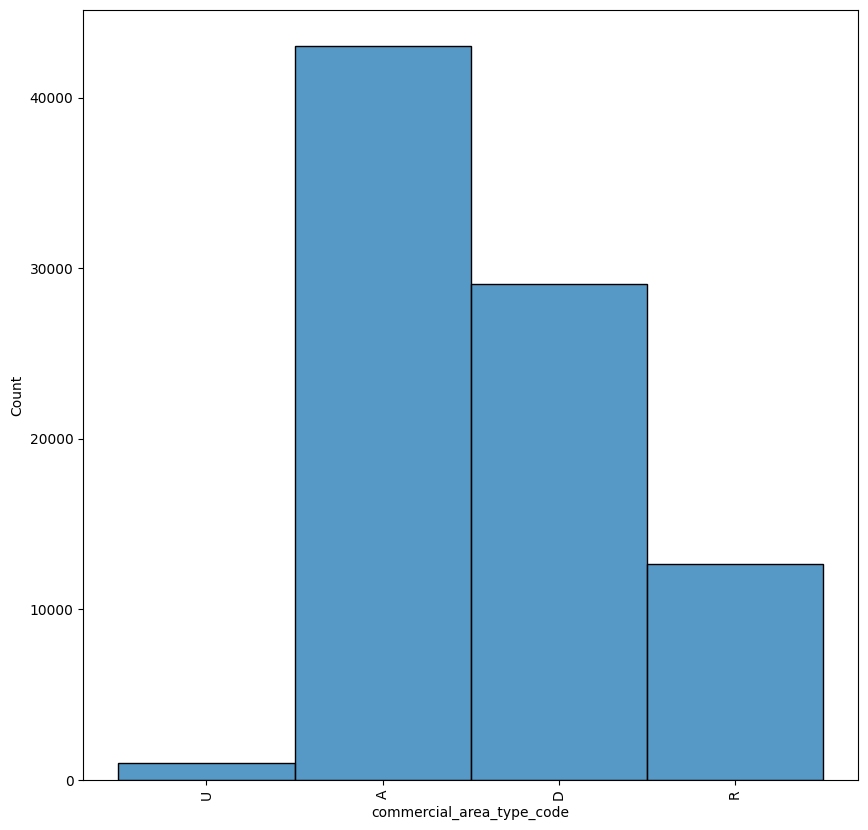

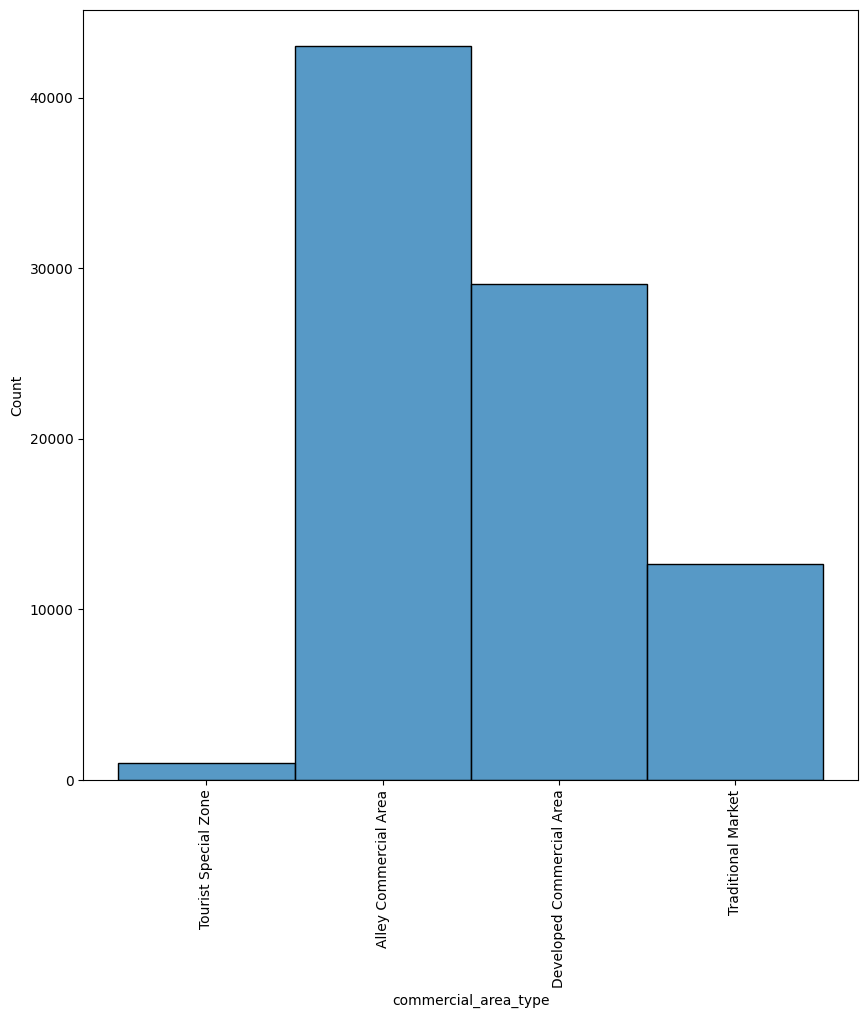

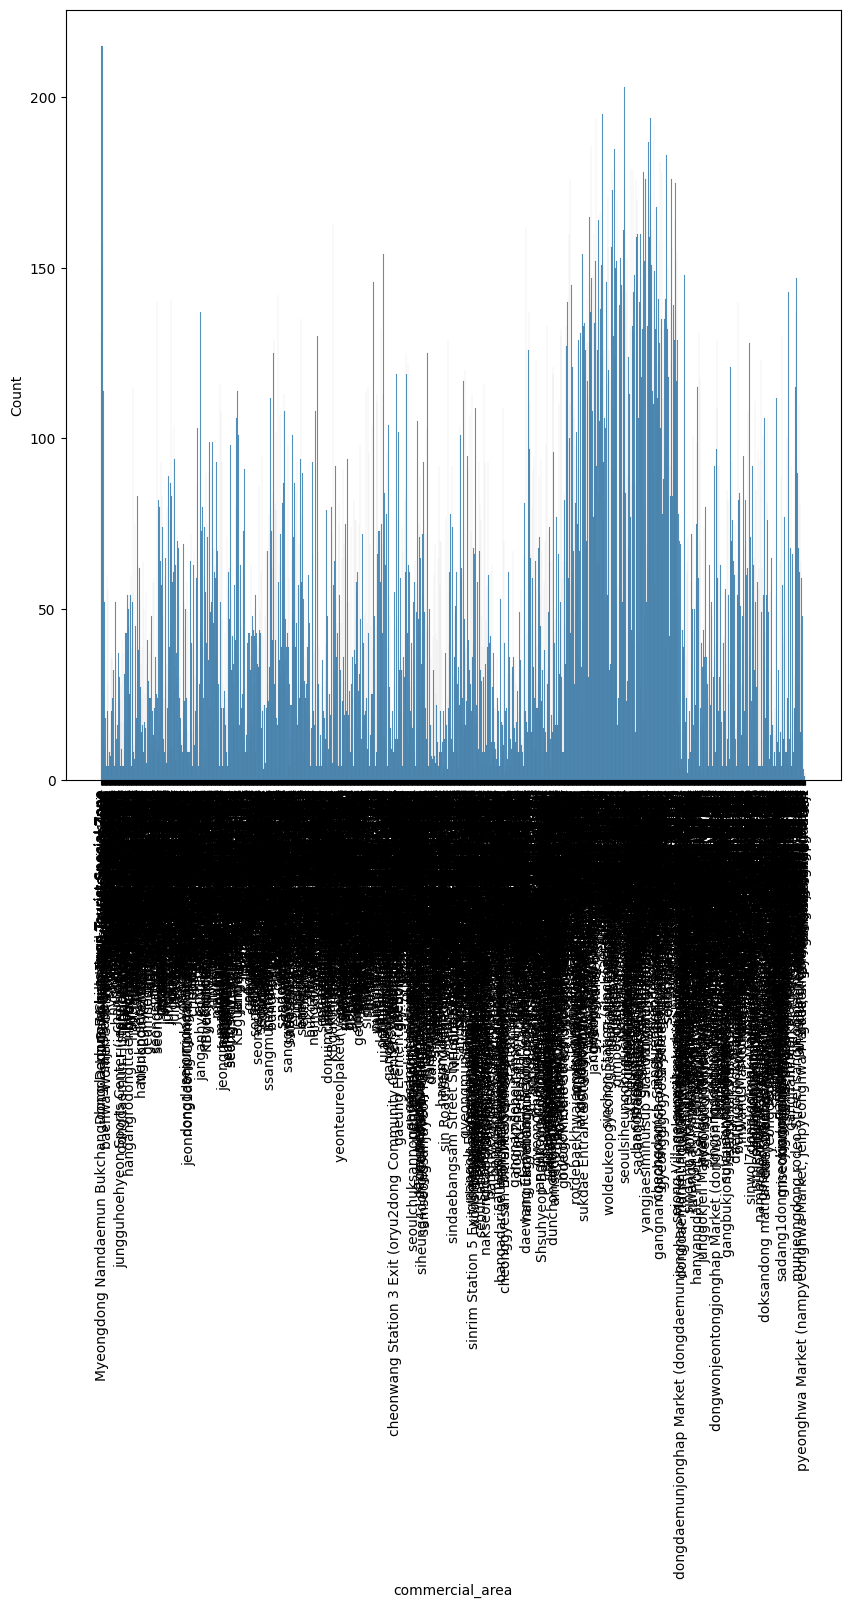

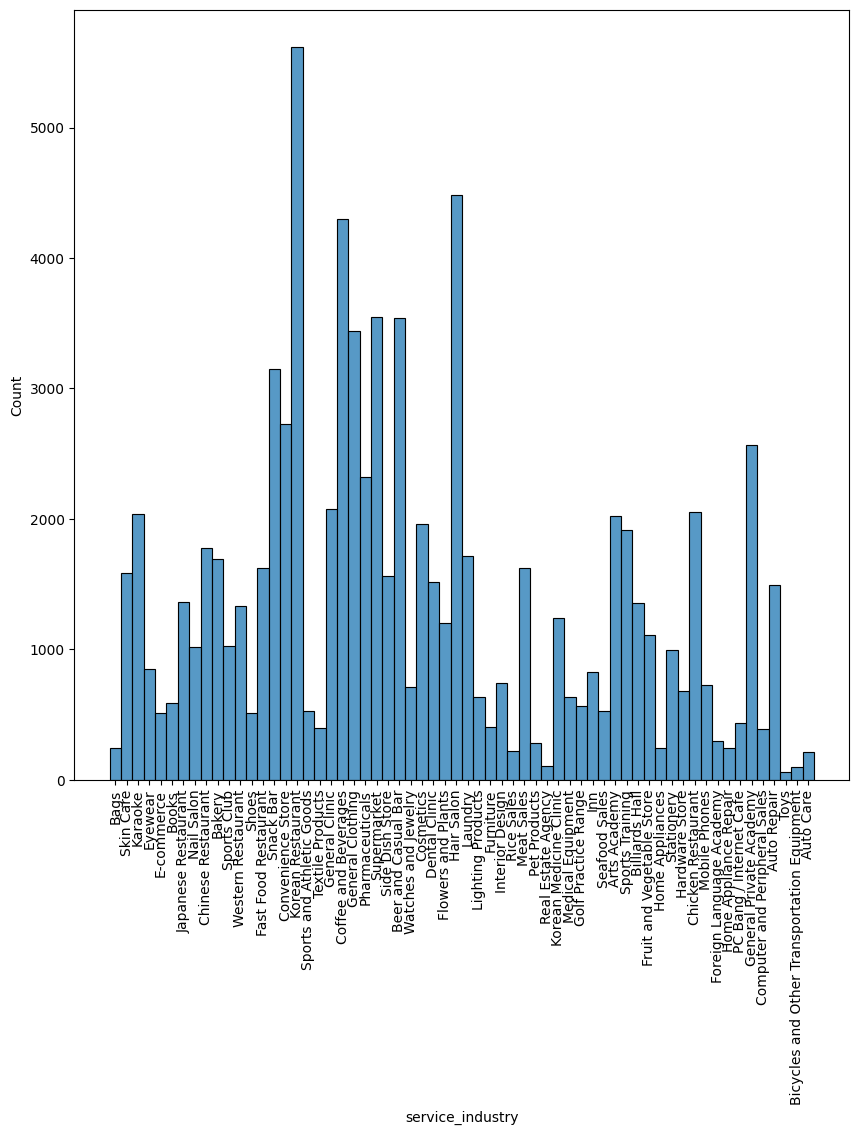

In [18]:
for i in z:
  if(z[i].dtype == "object") and ( i not in ["commercial_area_code", "service_industry_code"]):
    plt.figure(figsize = (10, 10))
    plt.xticks(rotation = 90);
    sns.histplot(x = z[i], data = z)

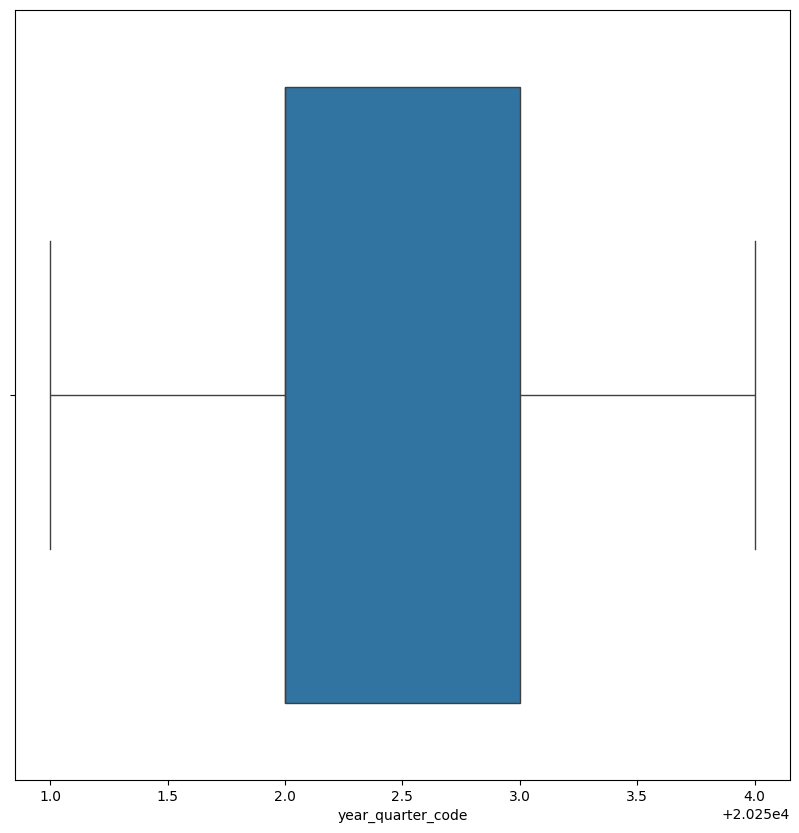

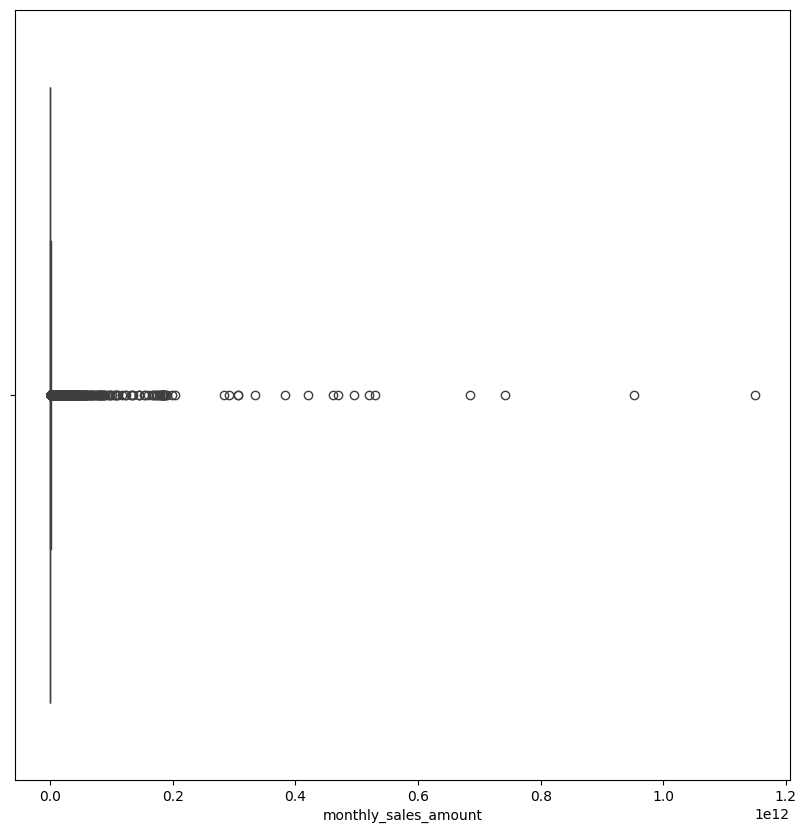

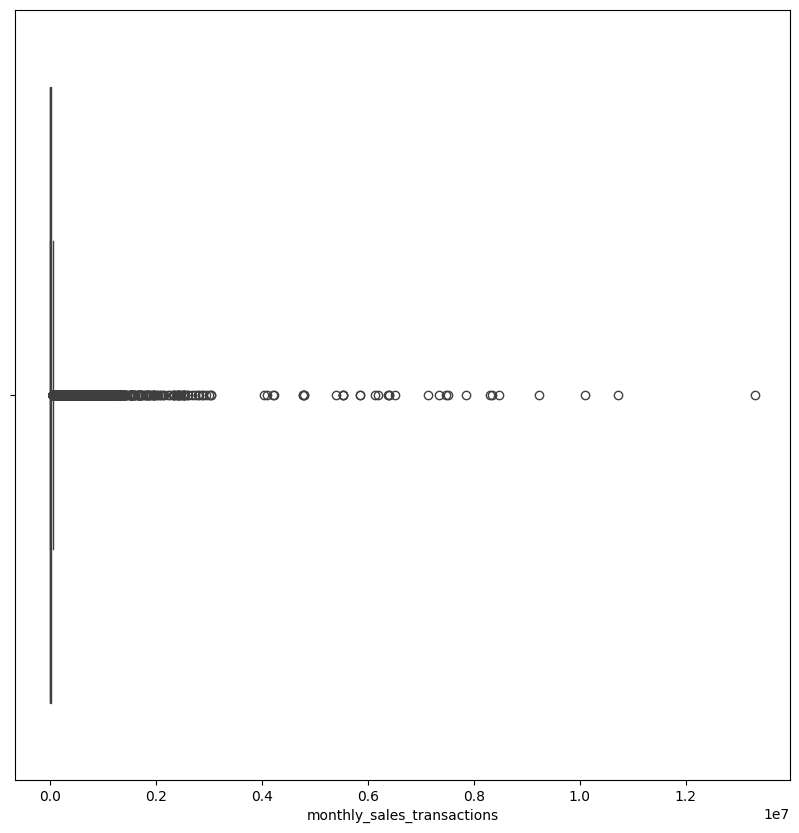

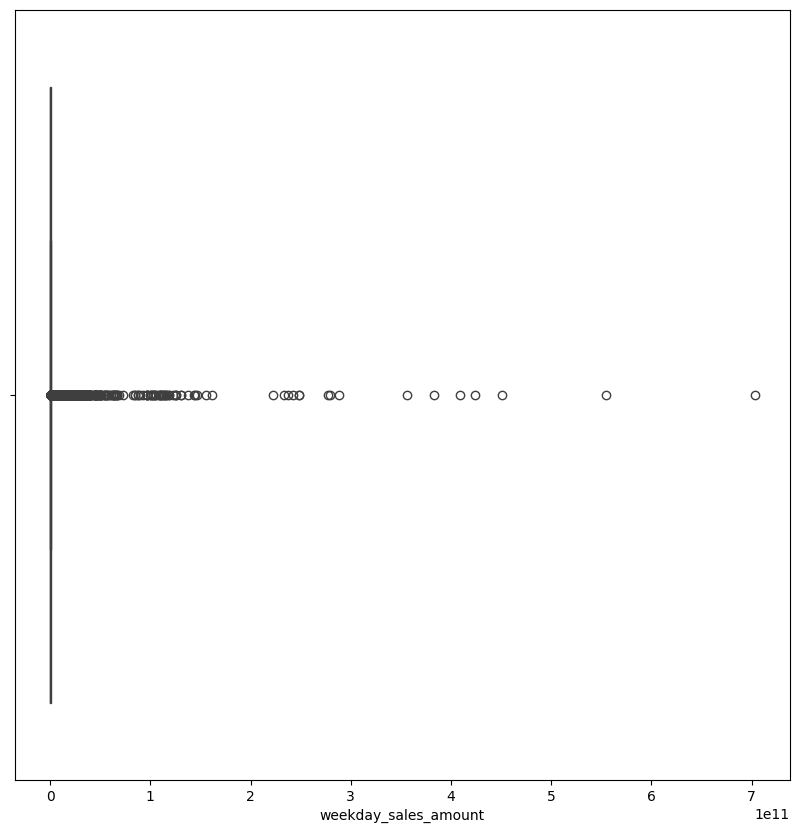

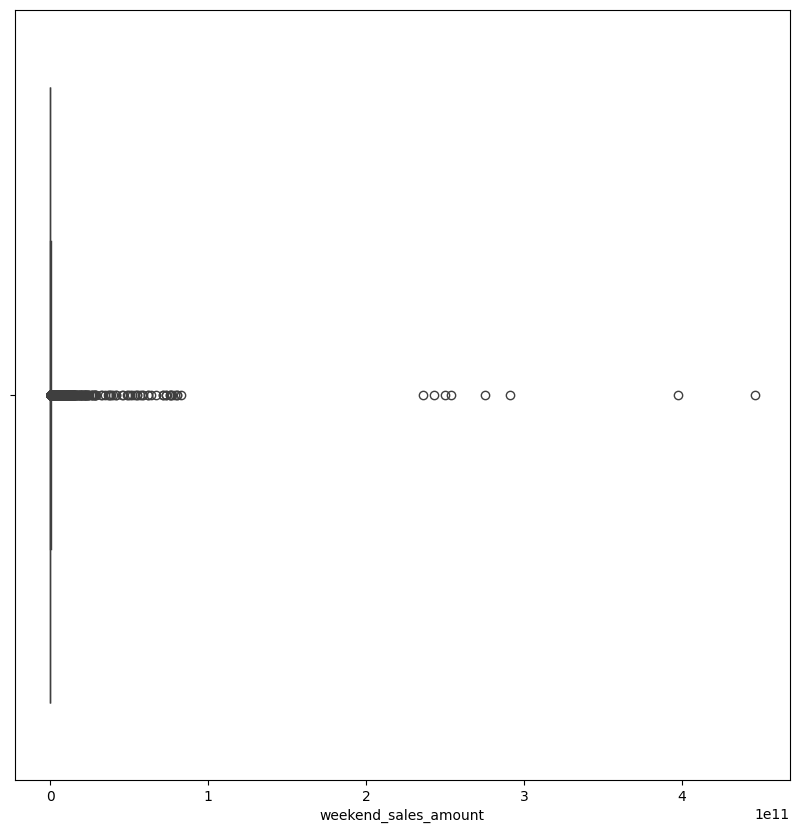

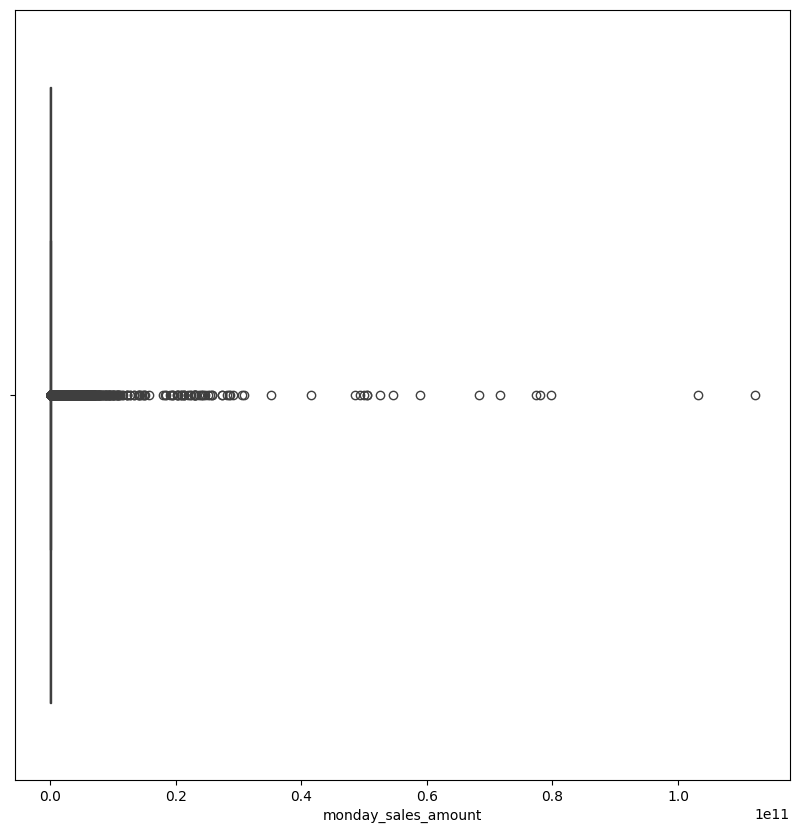

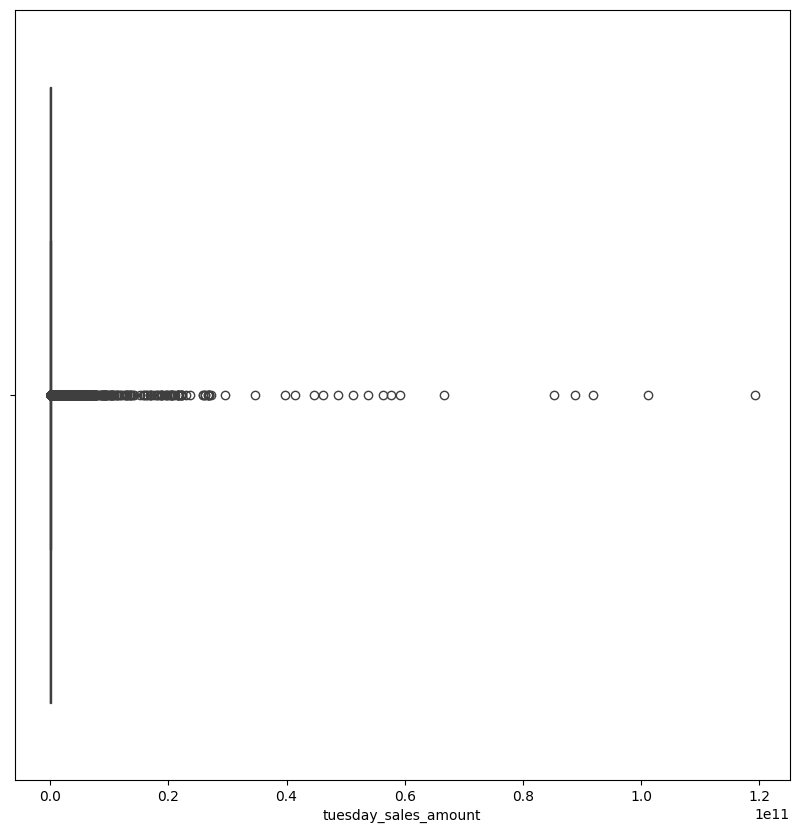

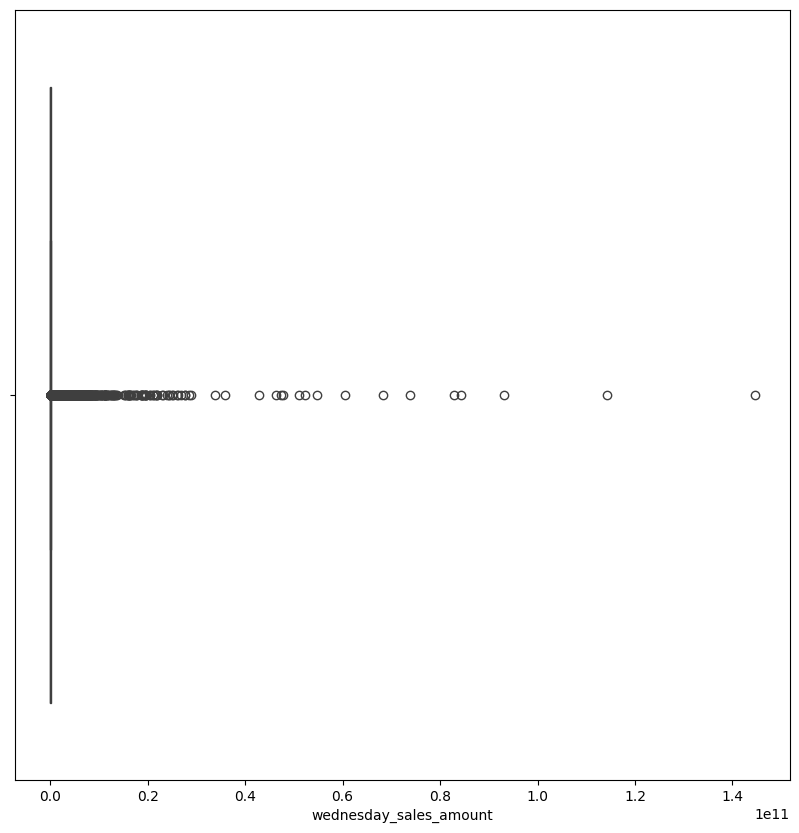

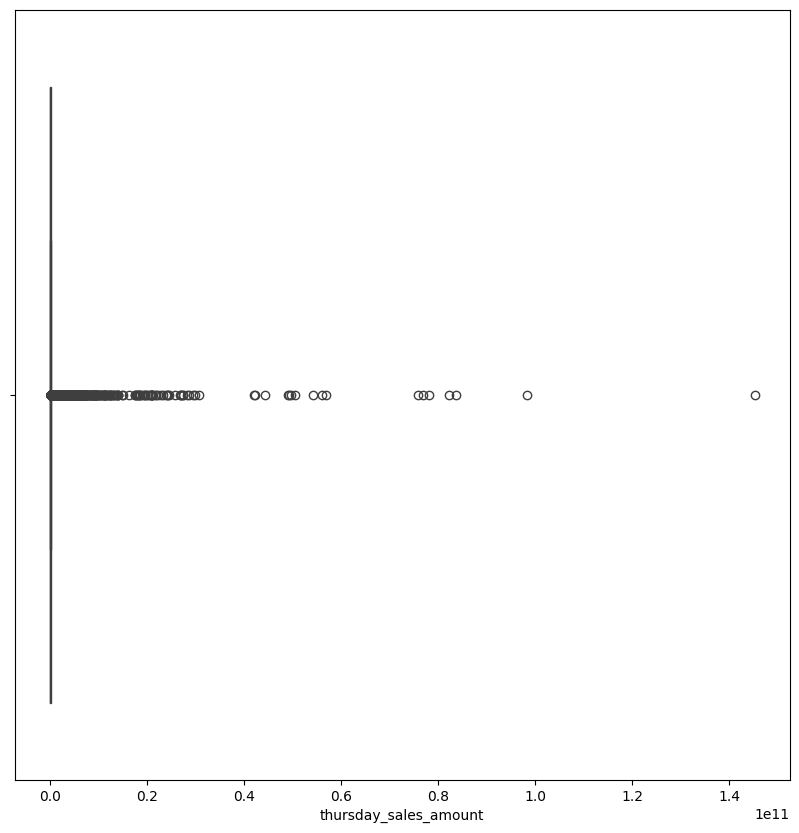

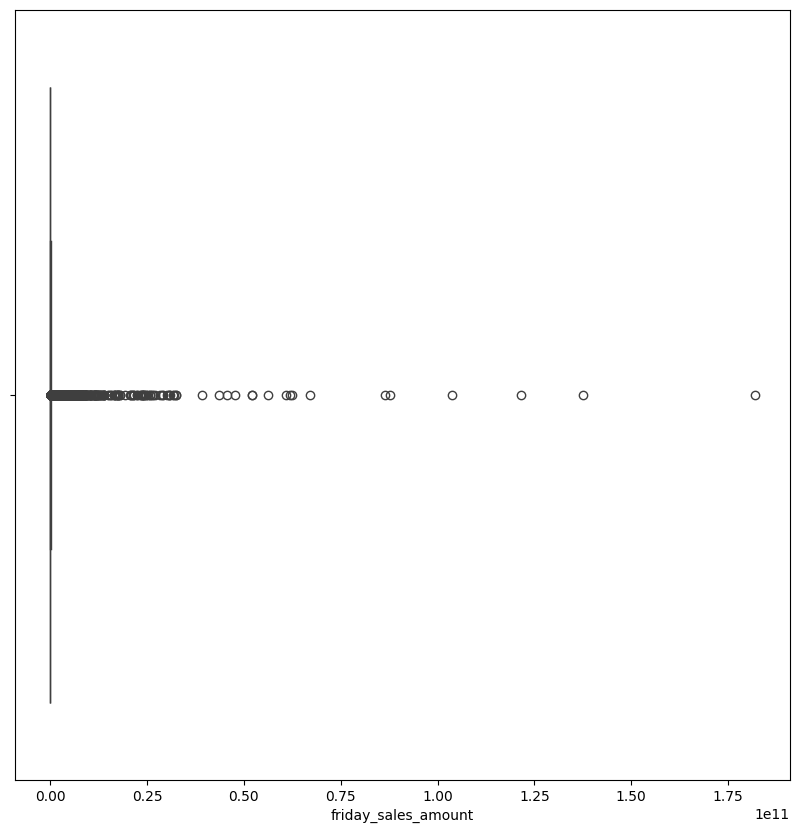

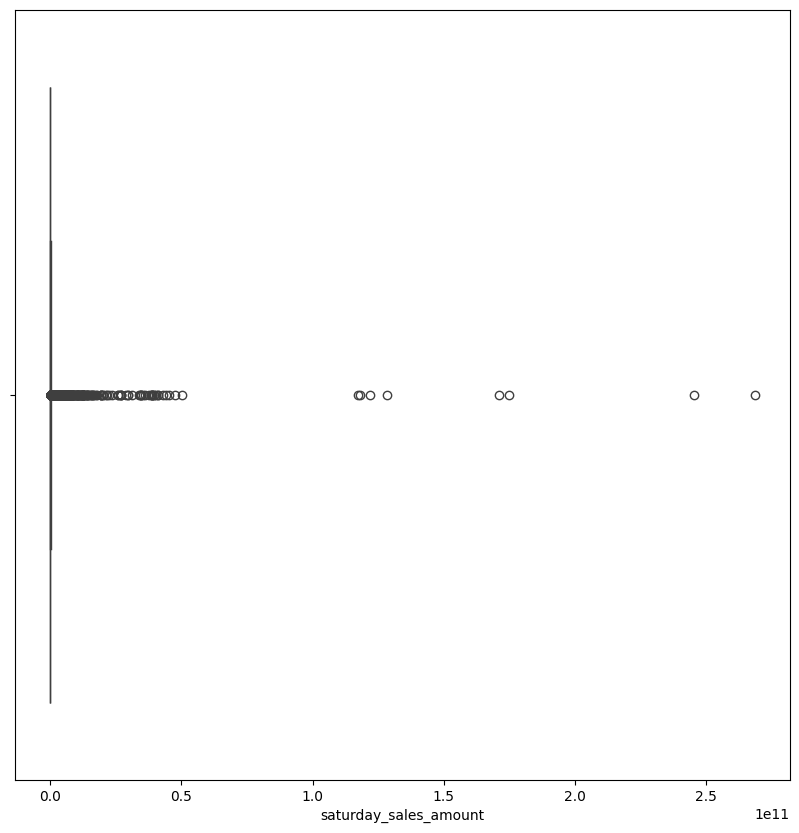

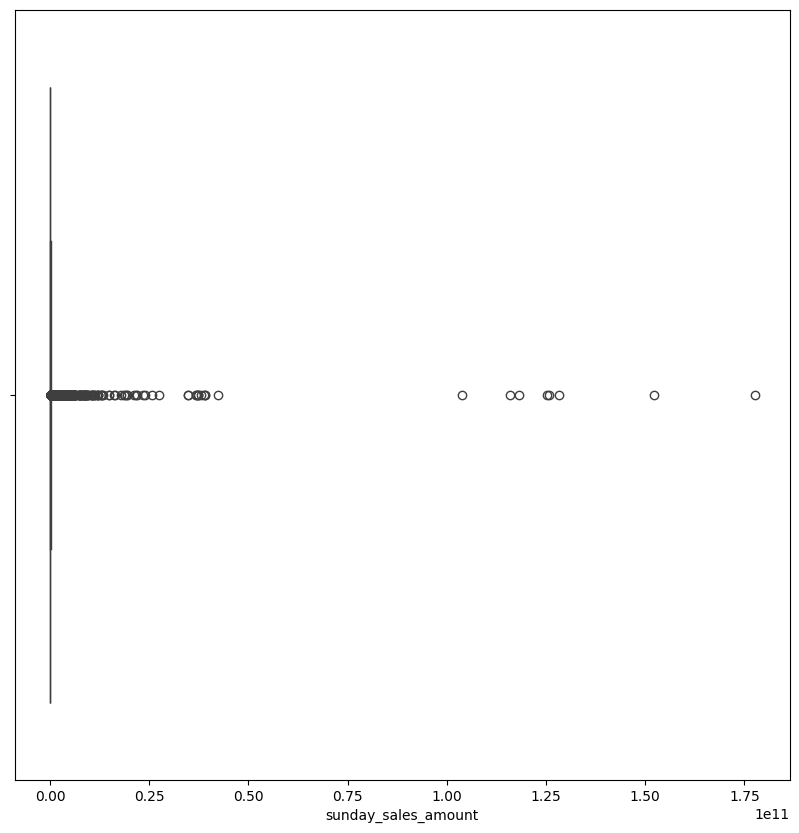

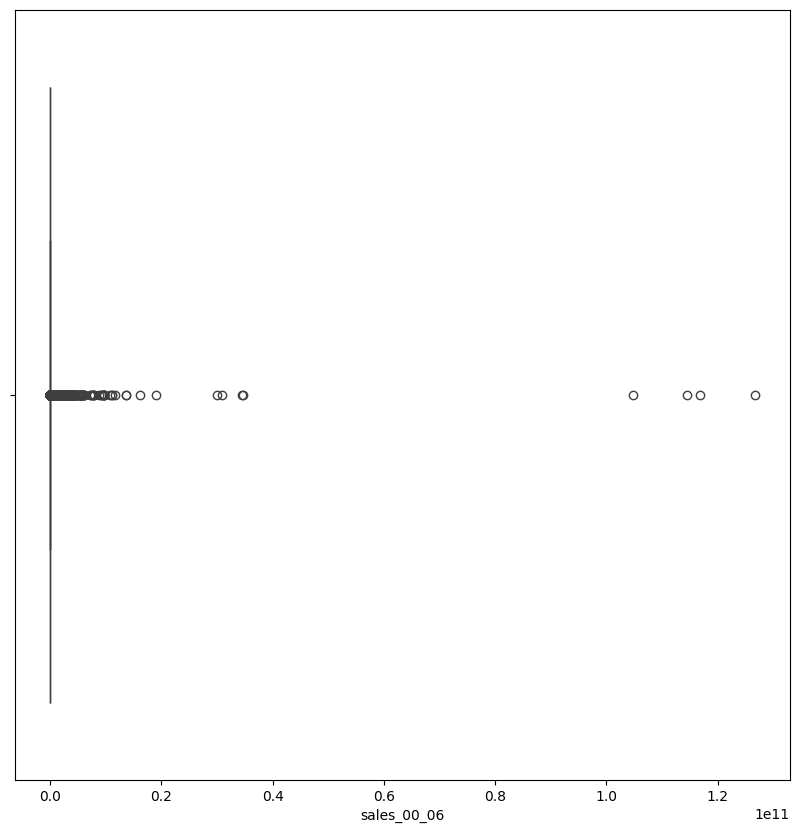

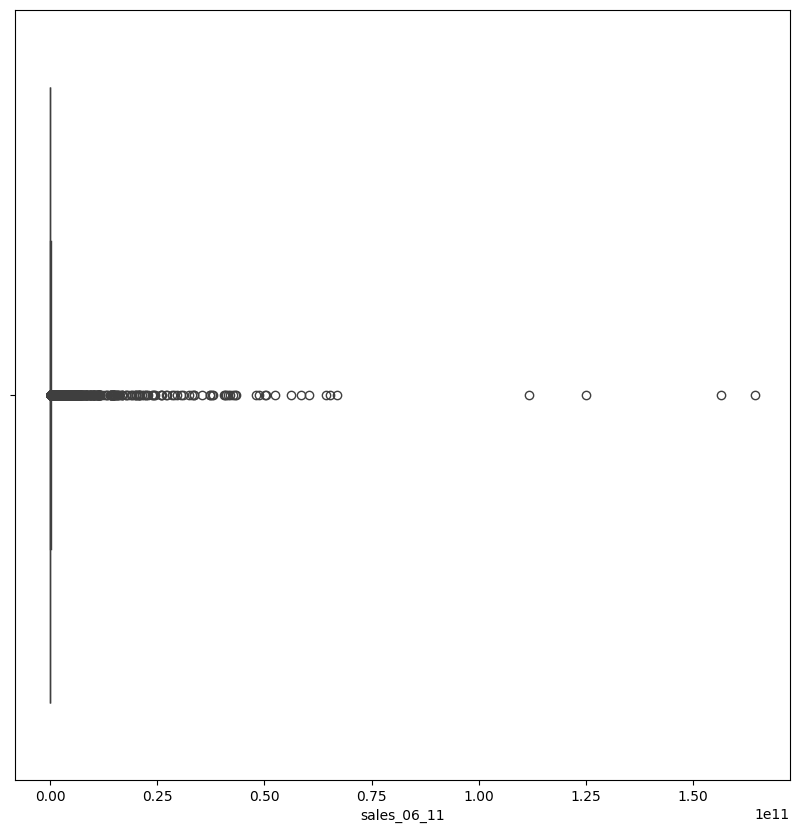

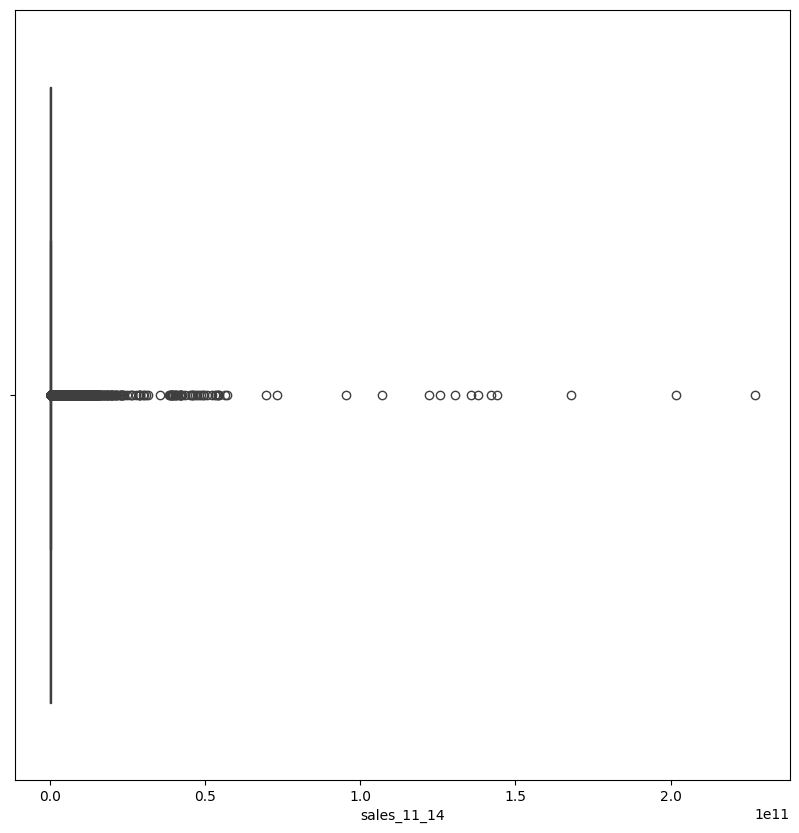

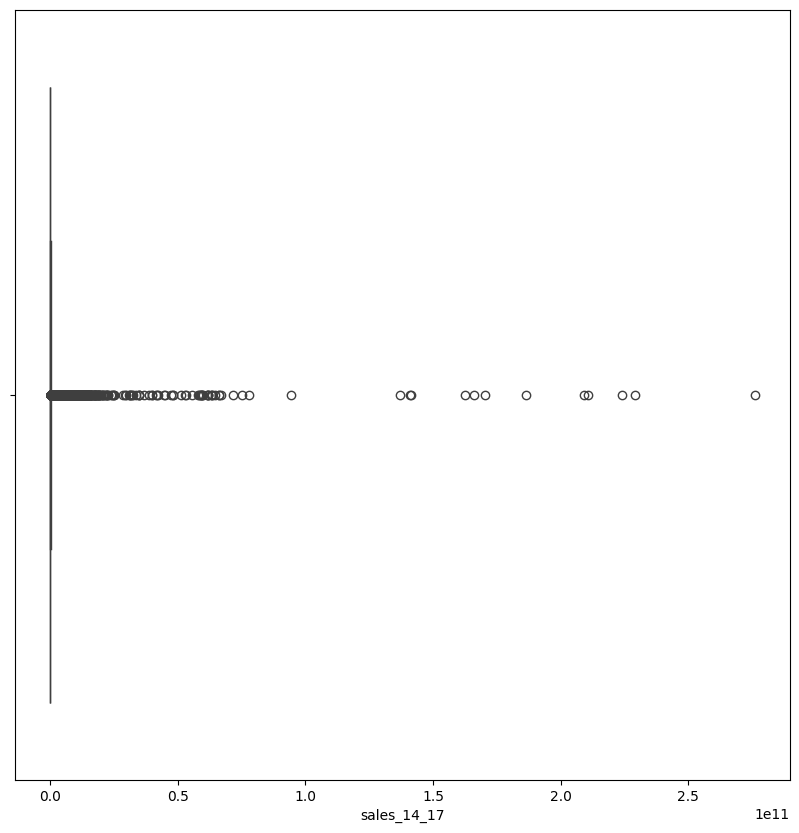

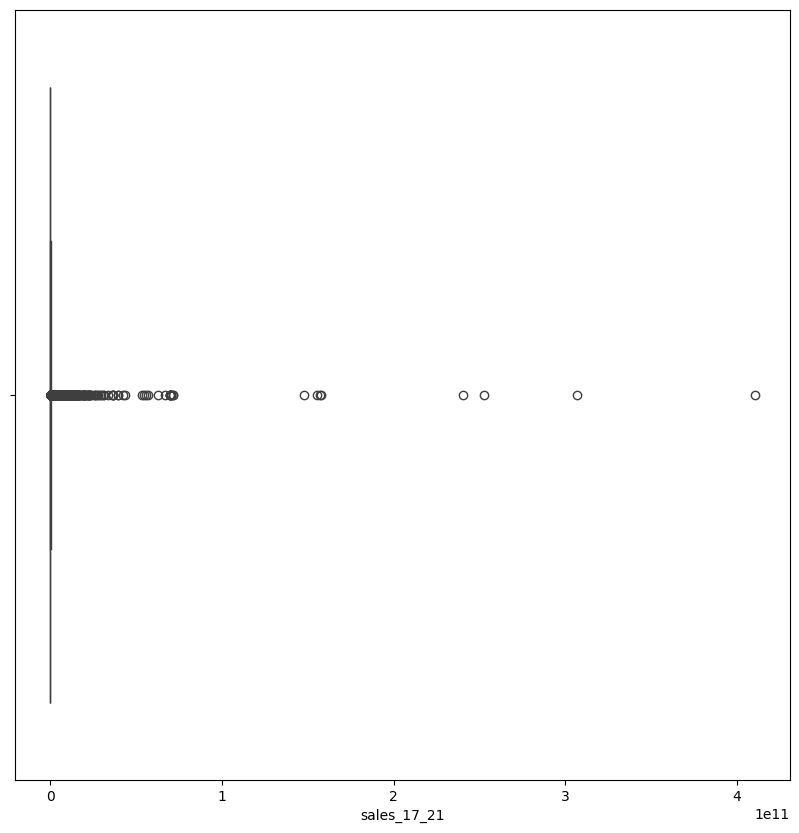

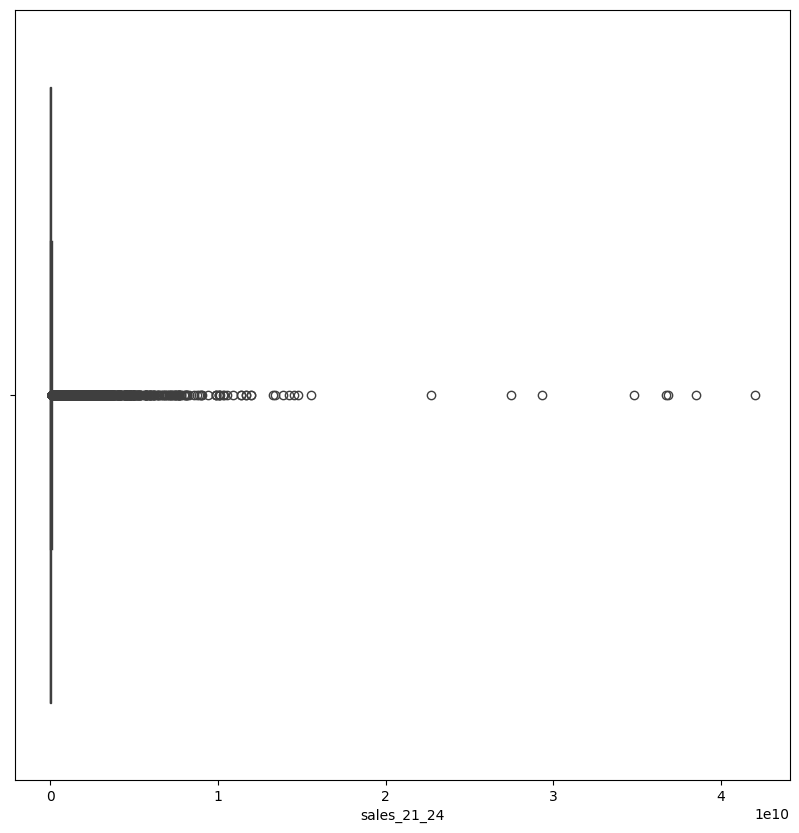

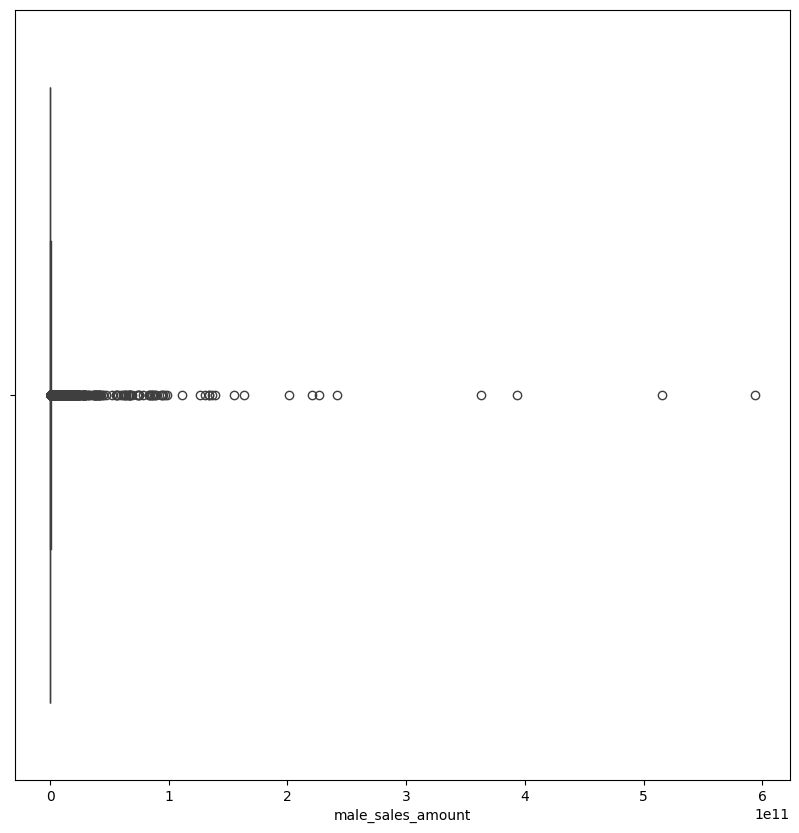

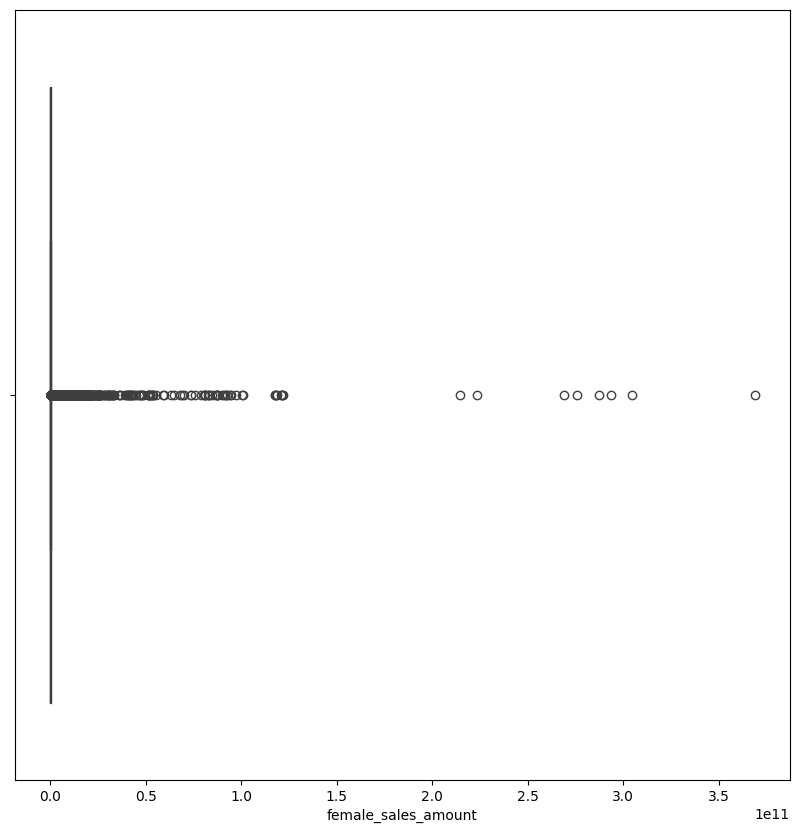

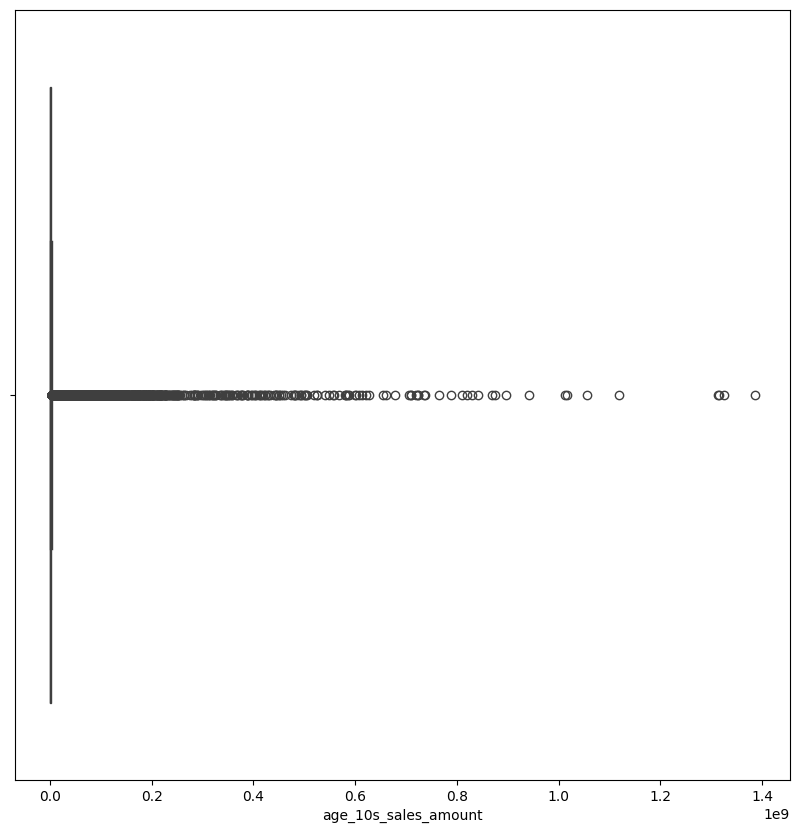

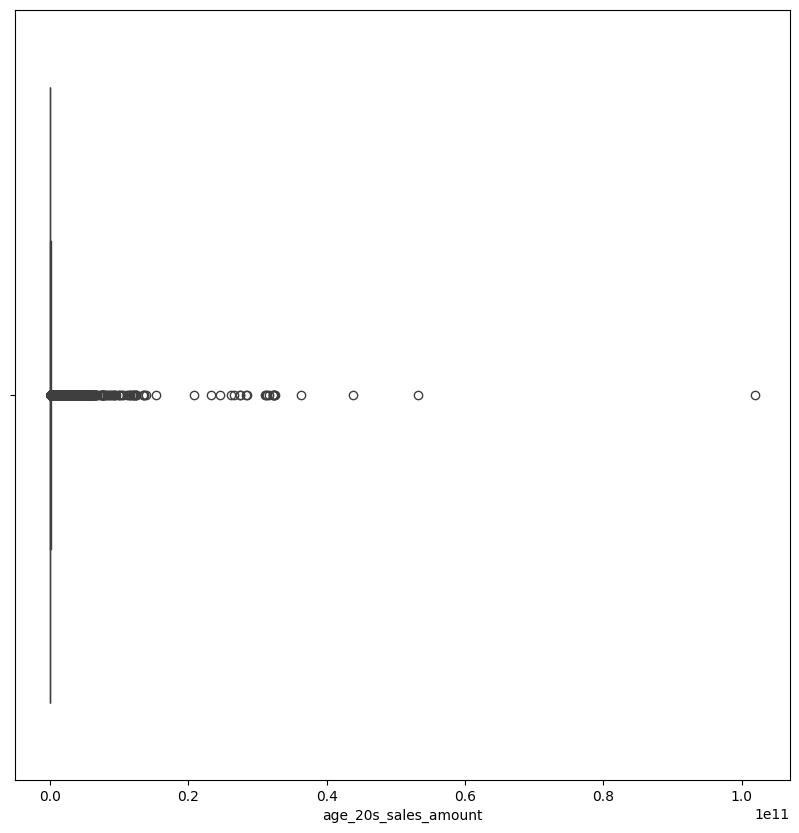

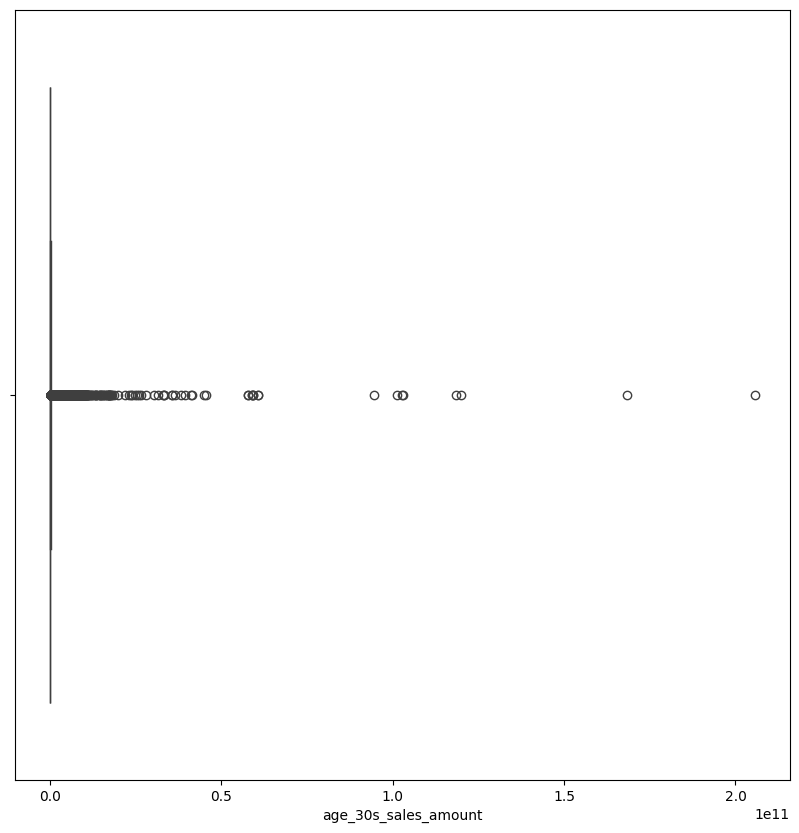

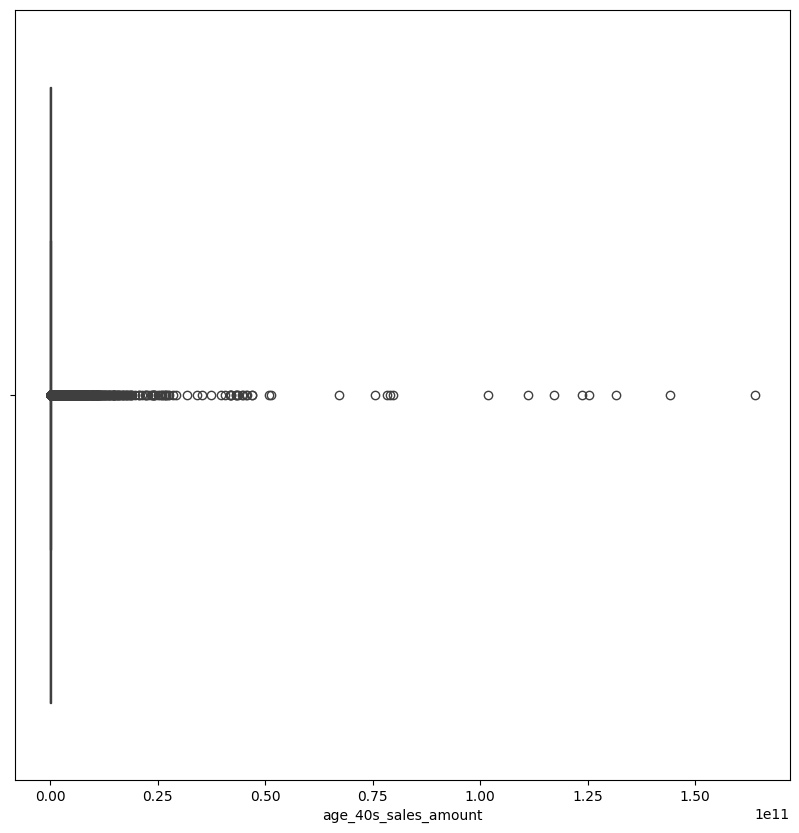

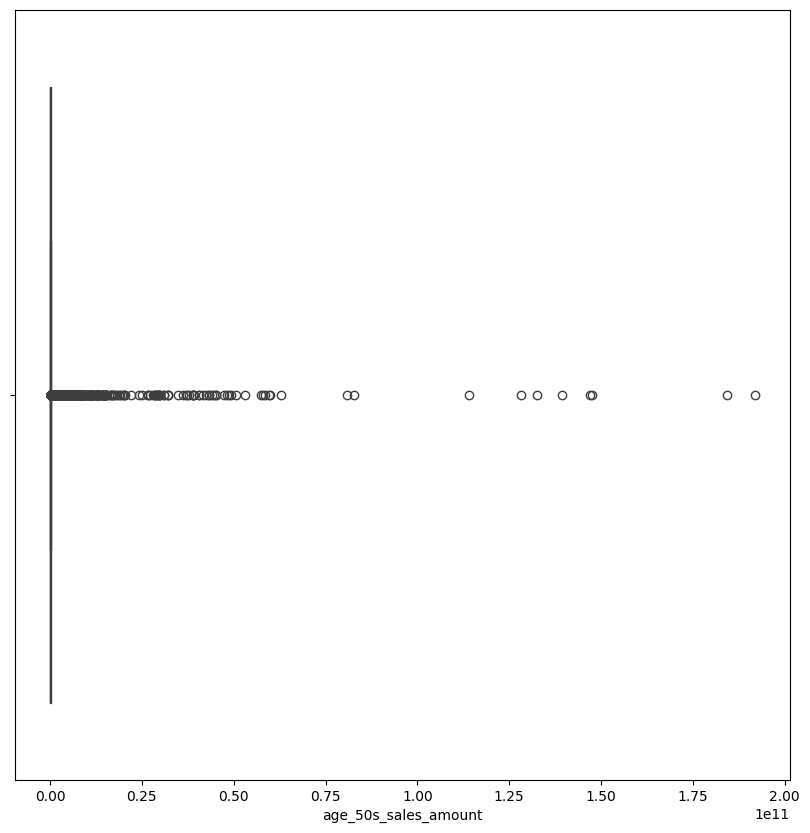

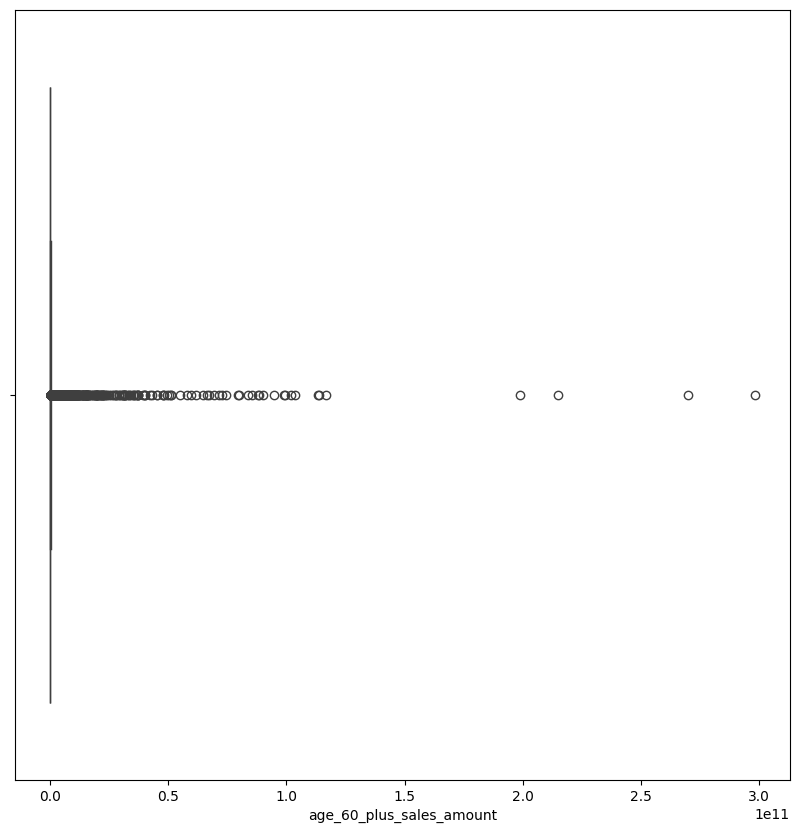

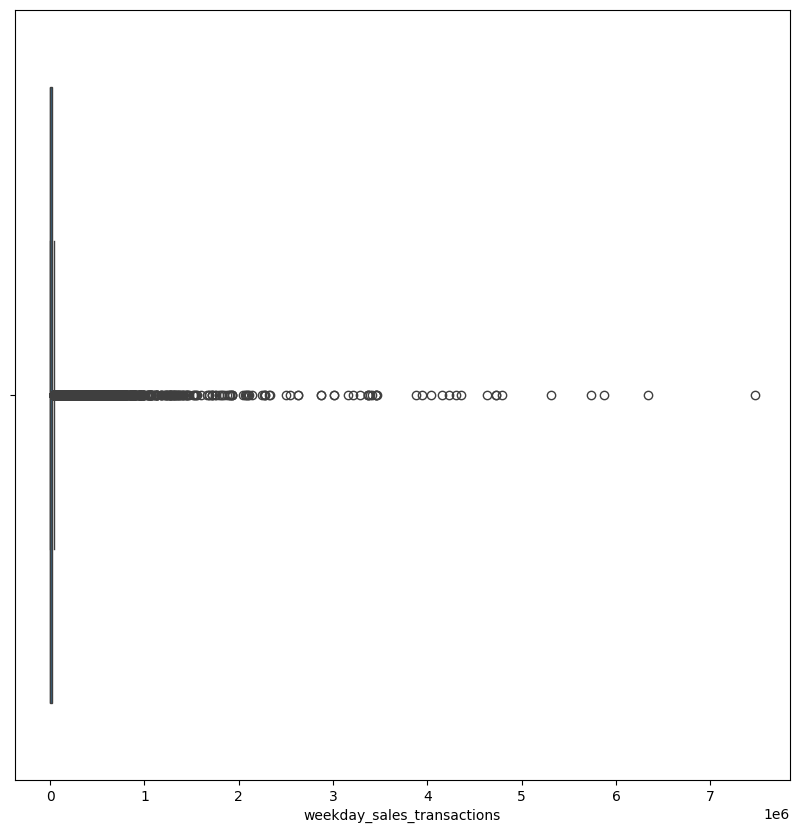

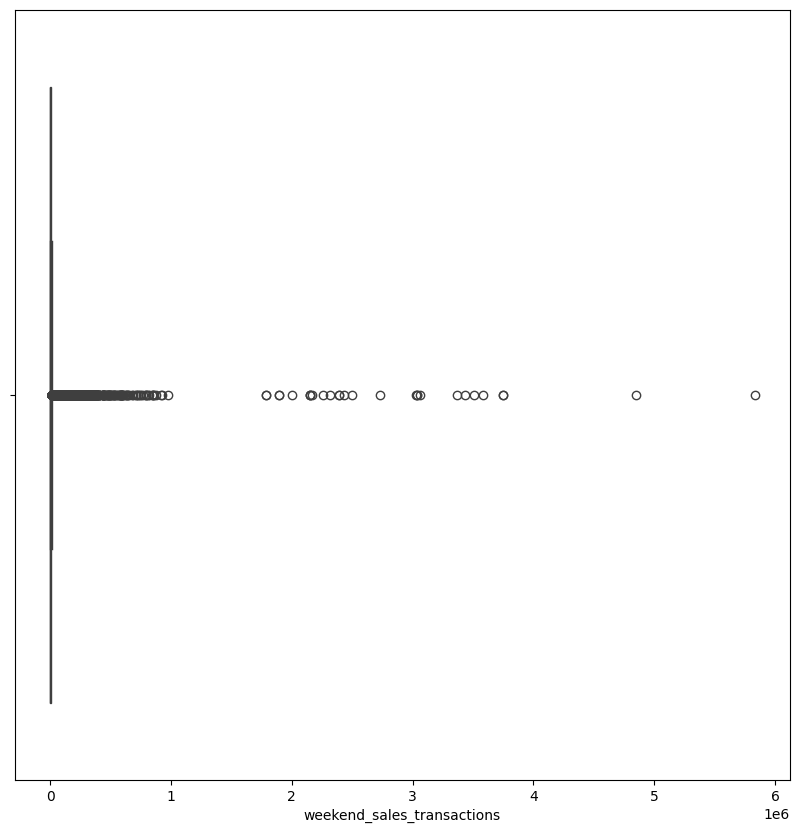

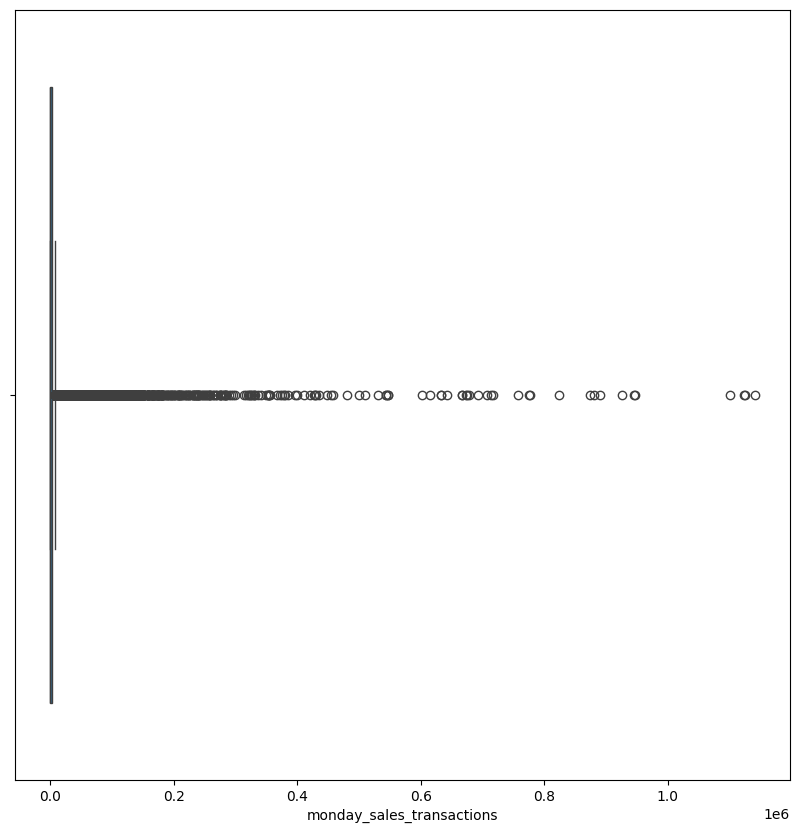

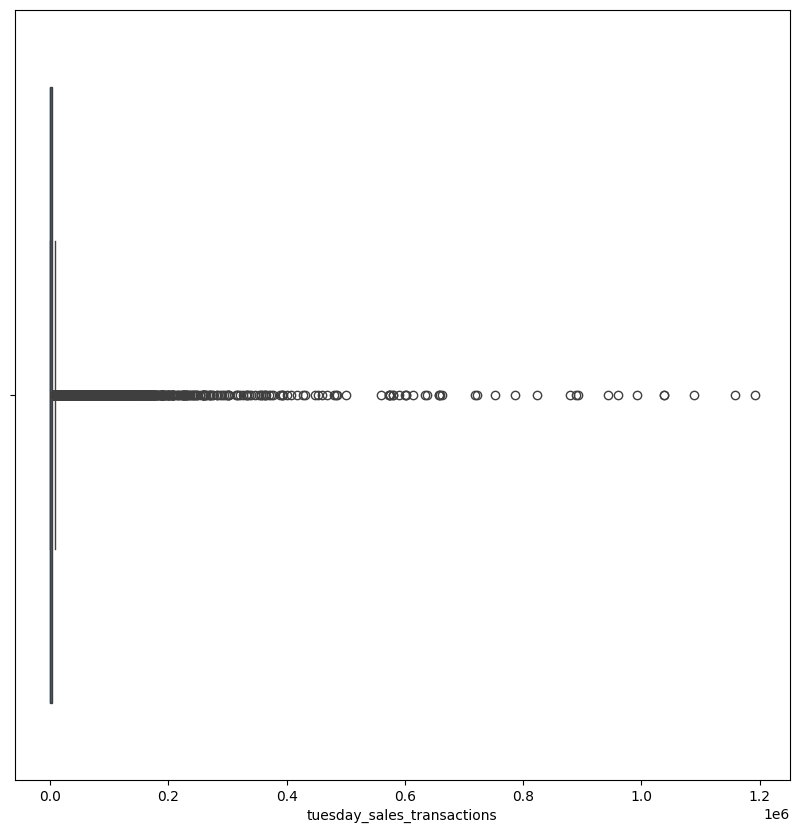

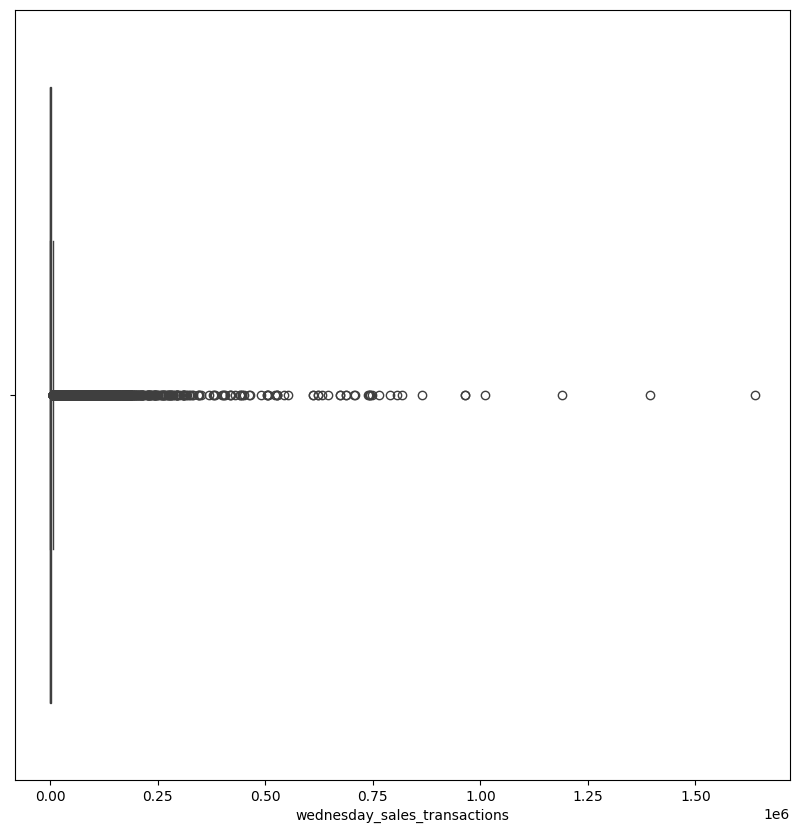

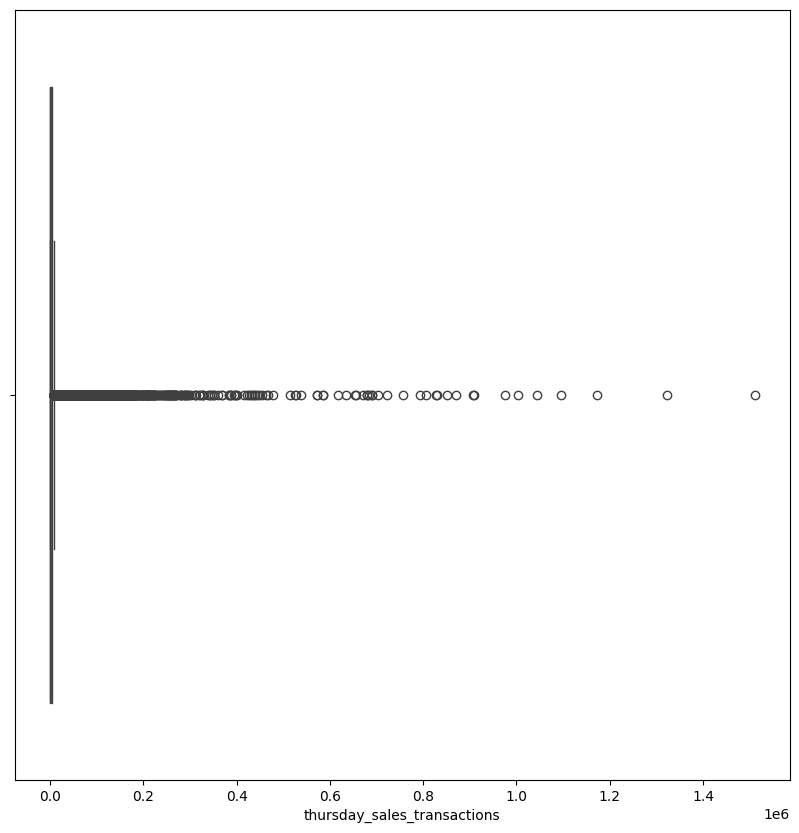

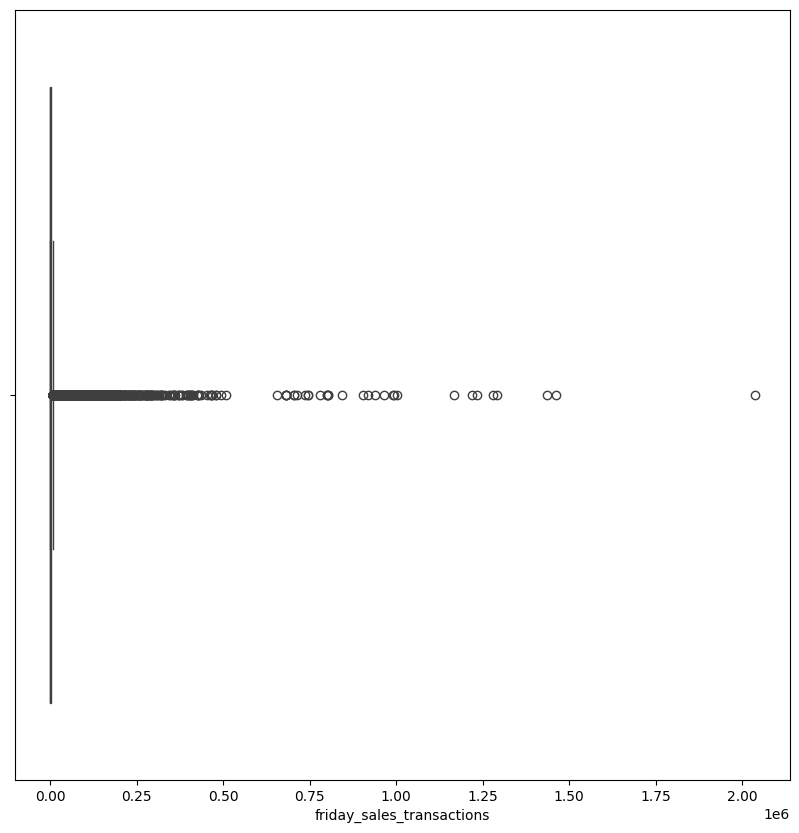

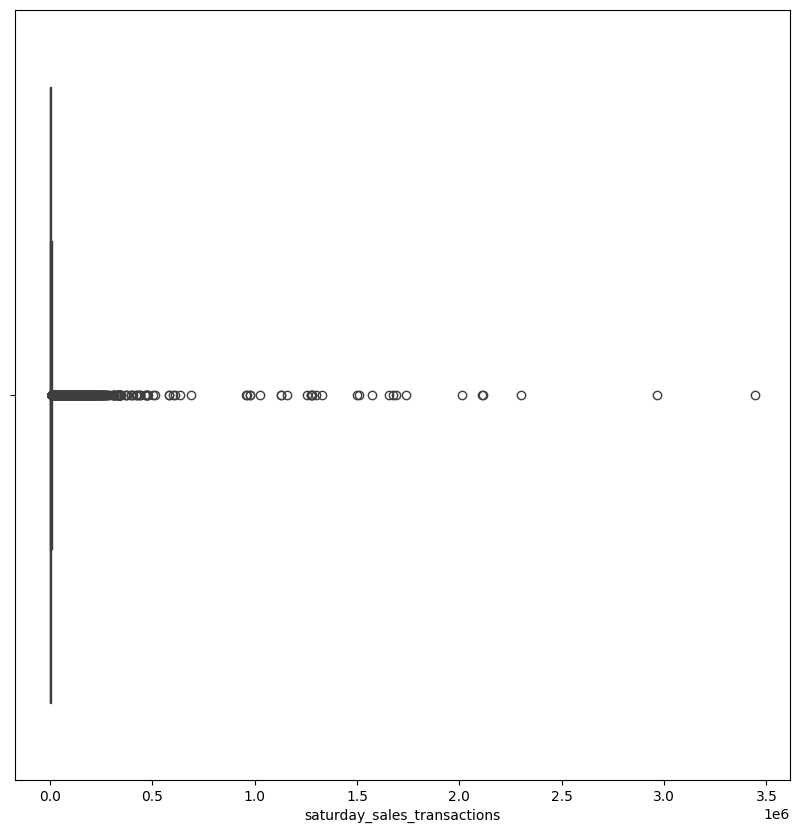

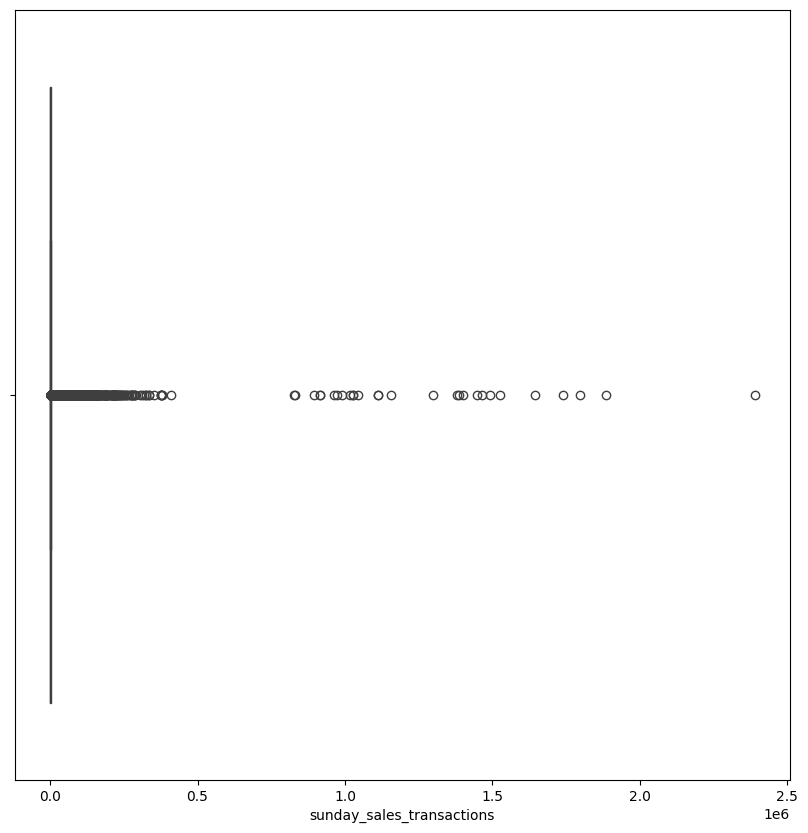

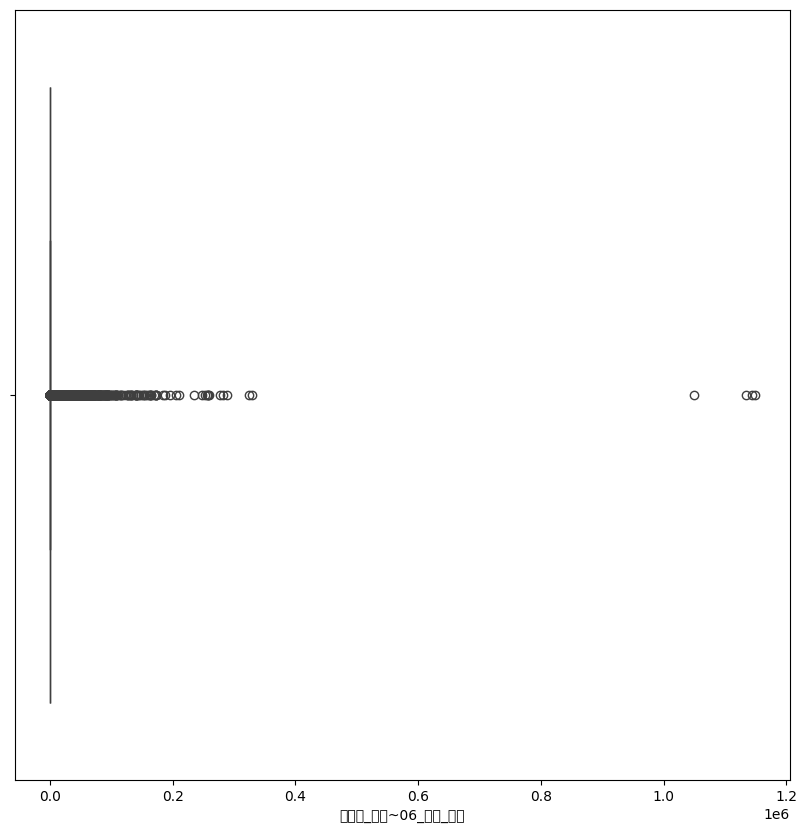

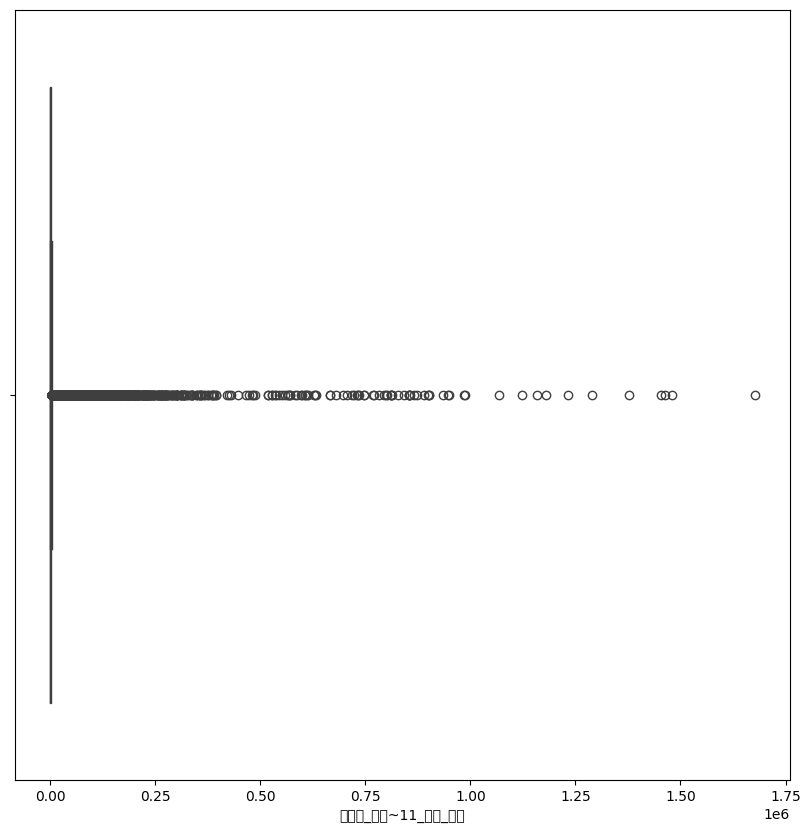

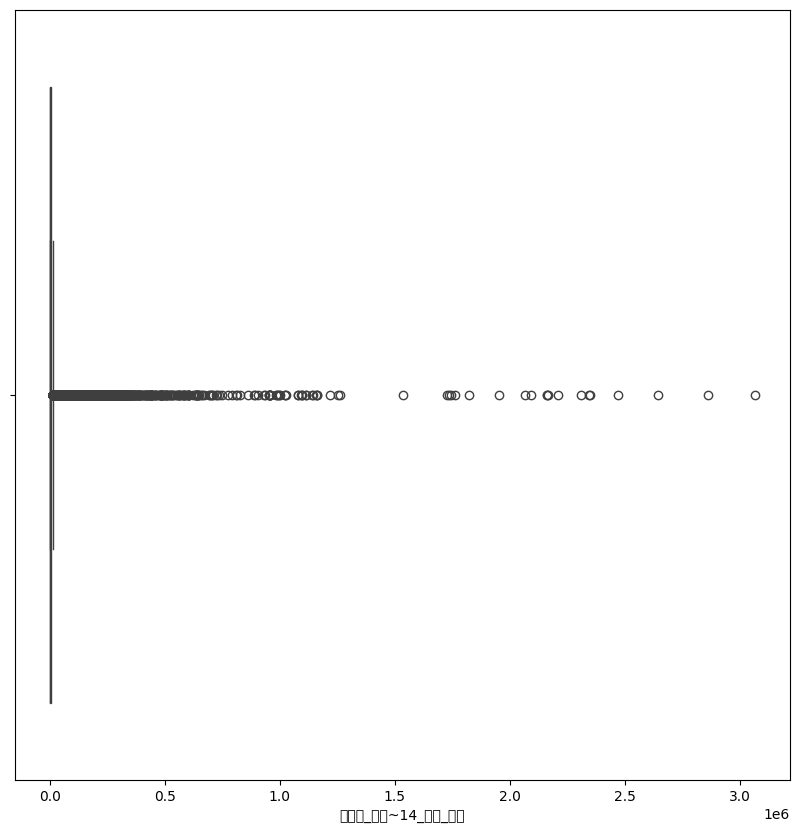

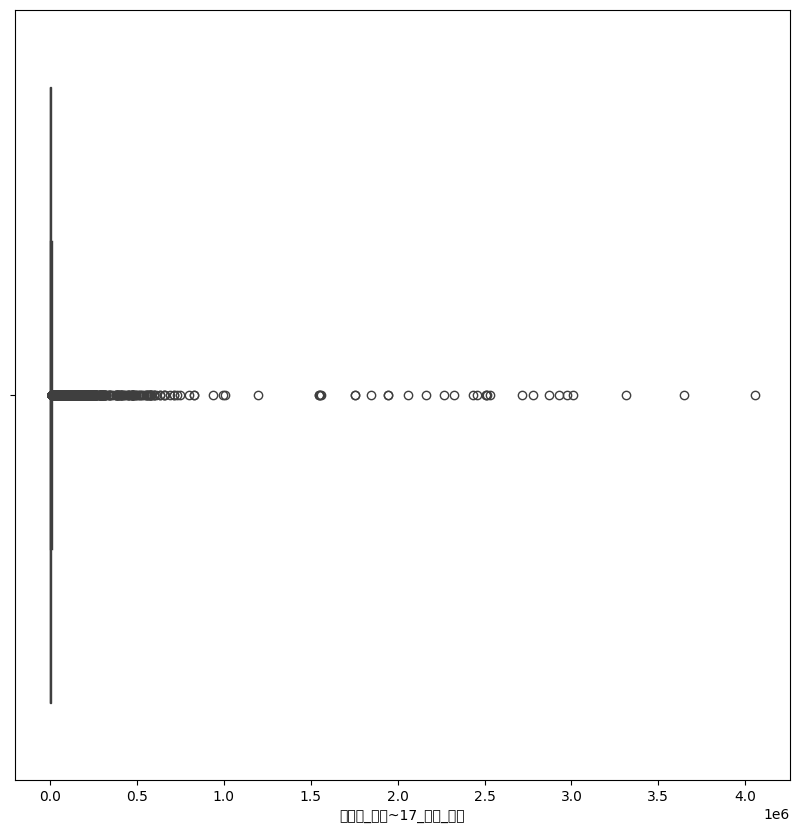

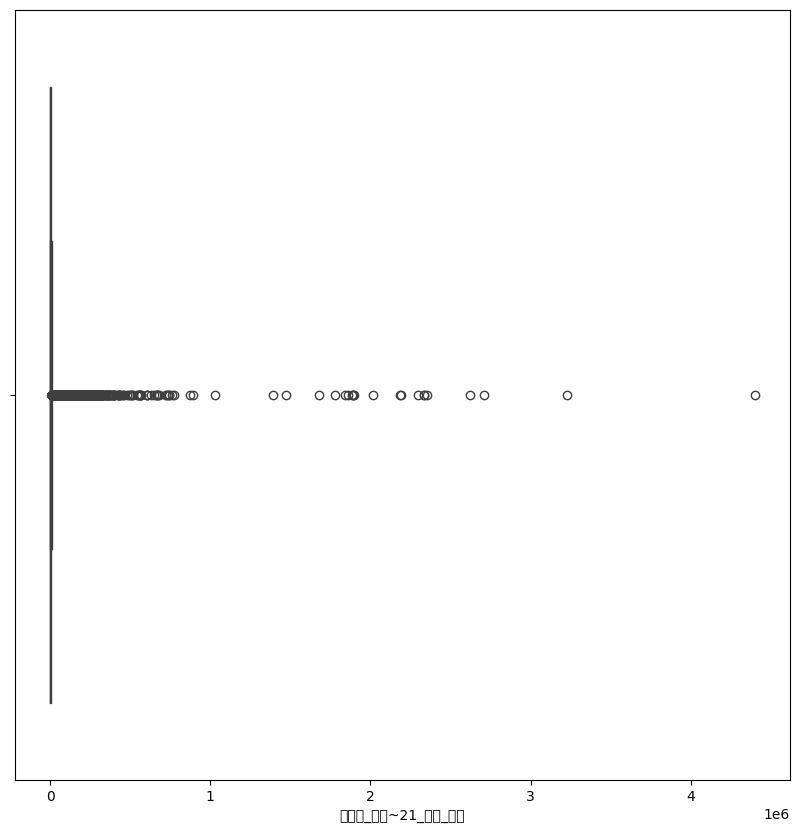

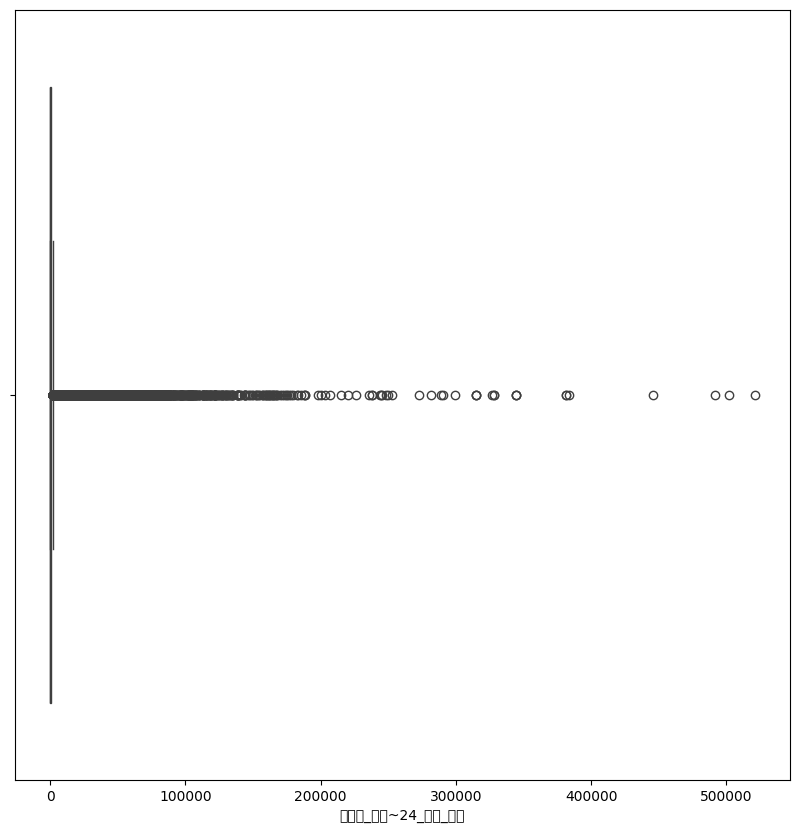

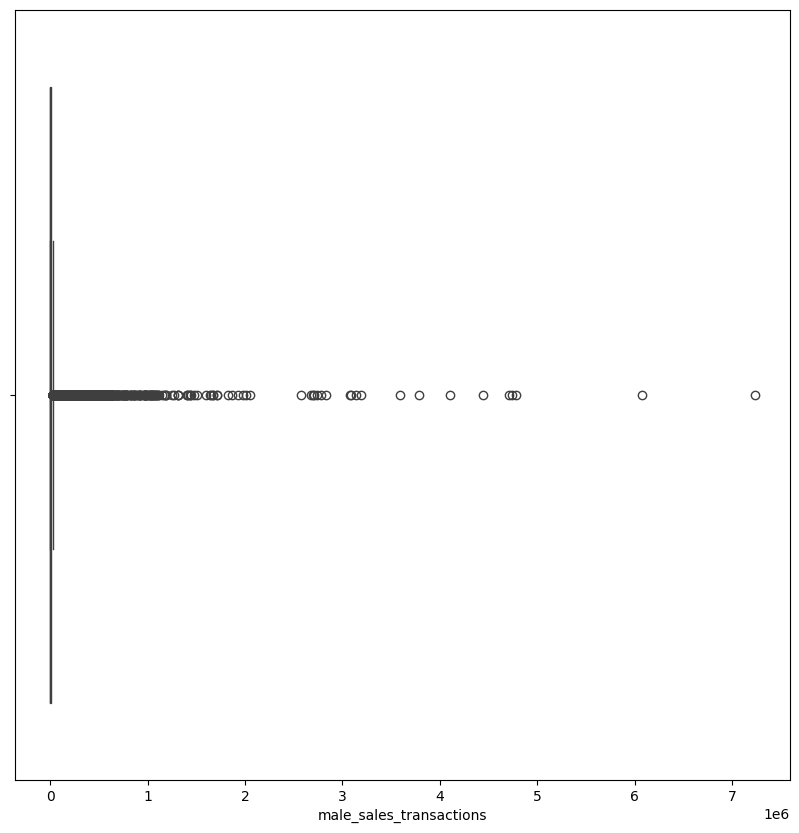

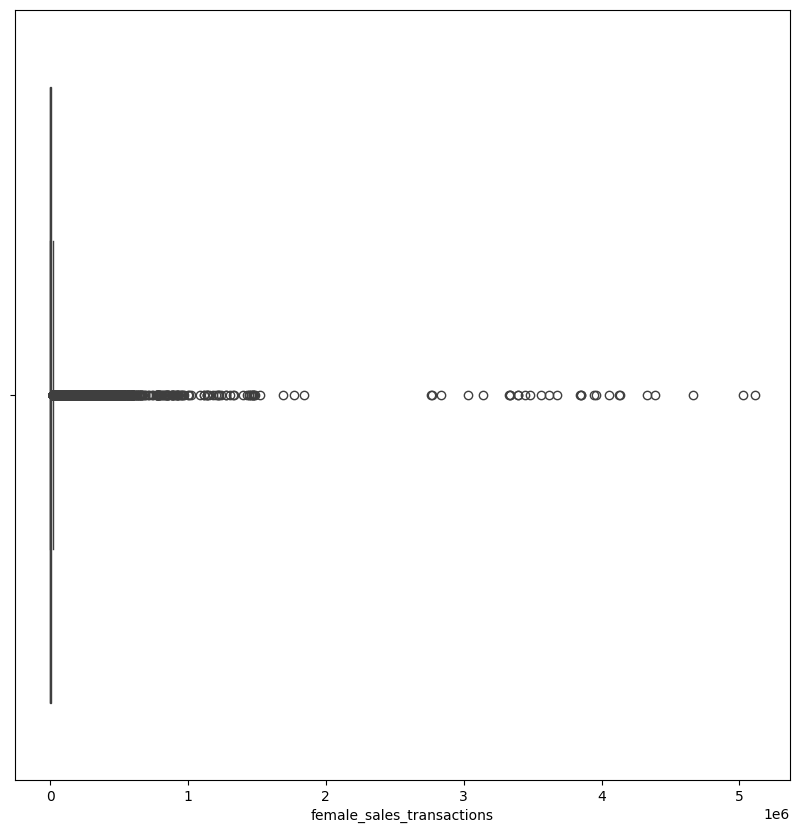

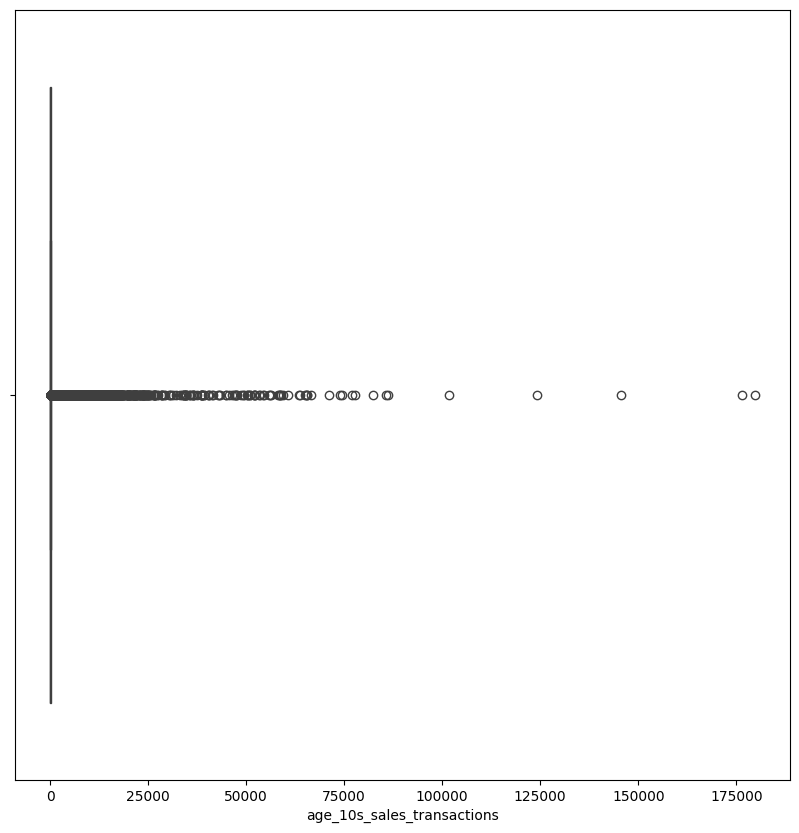

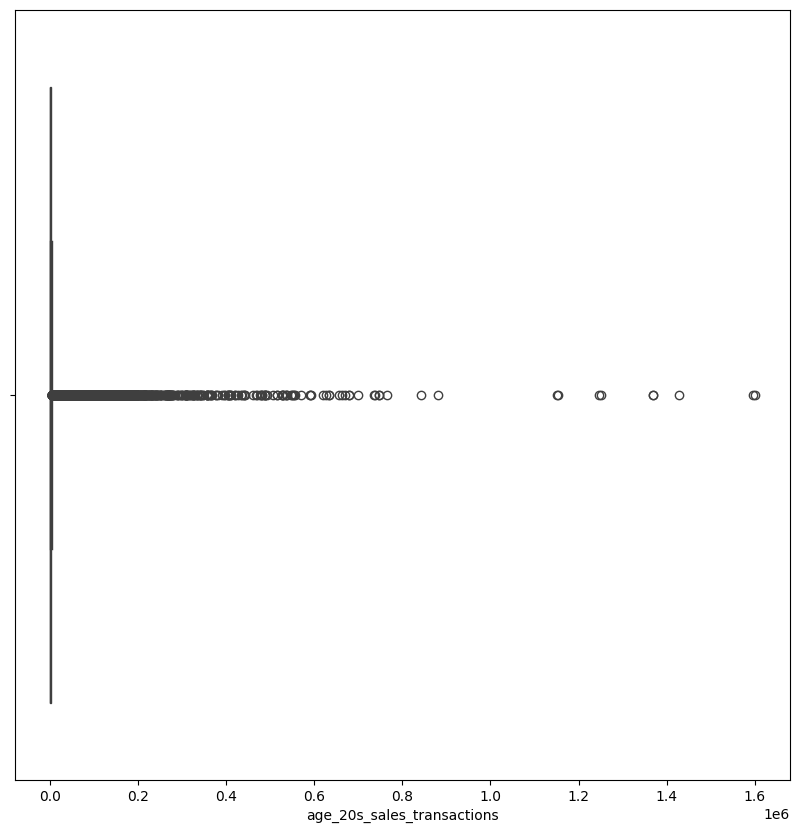

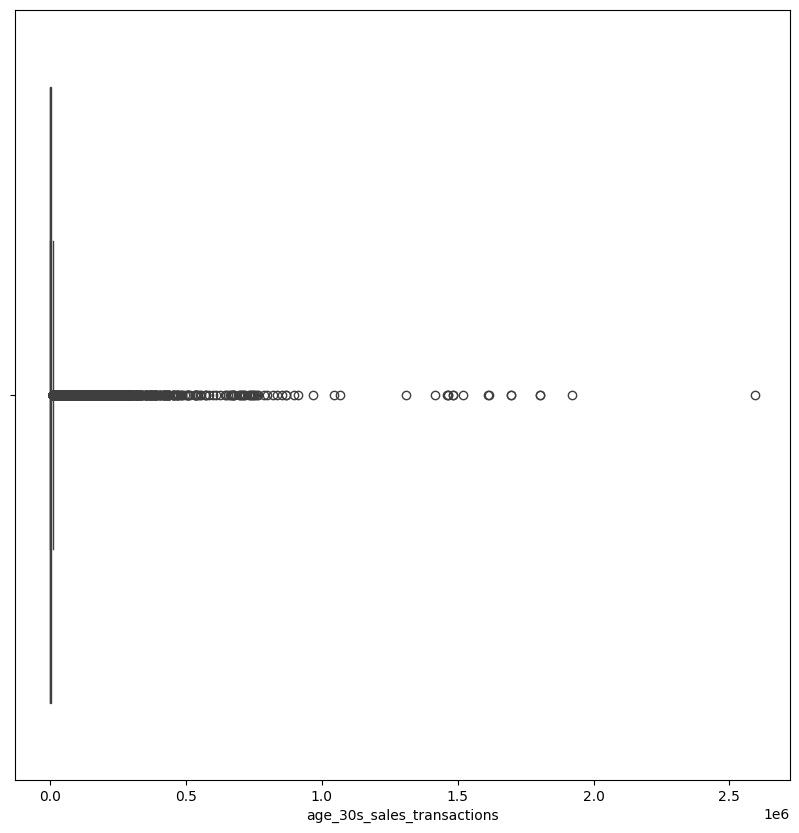

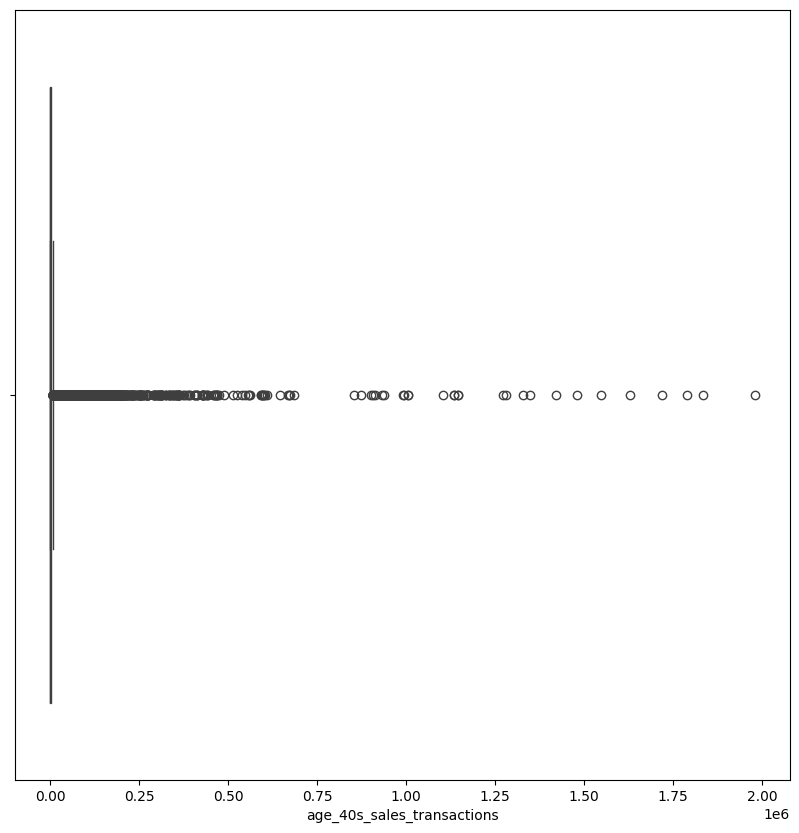

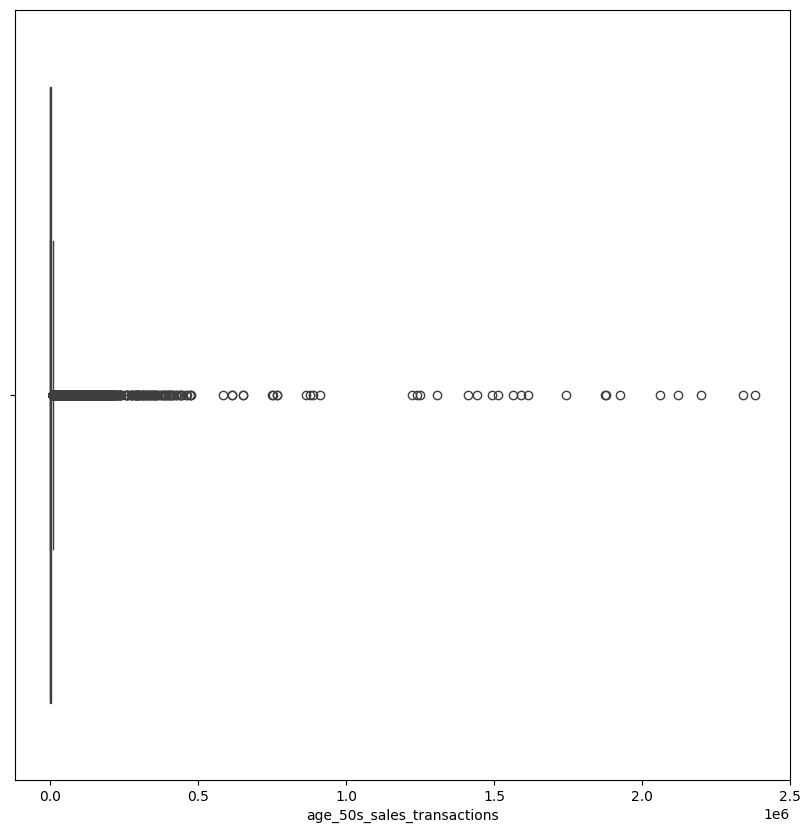

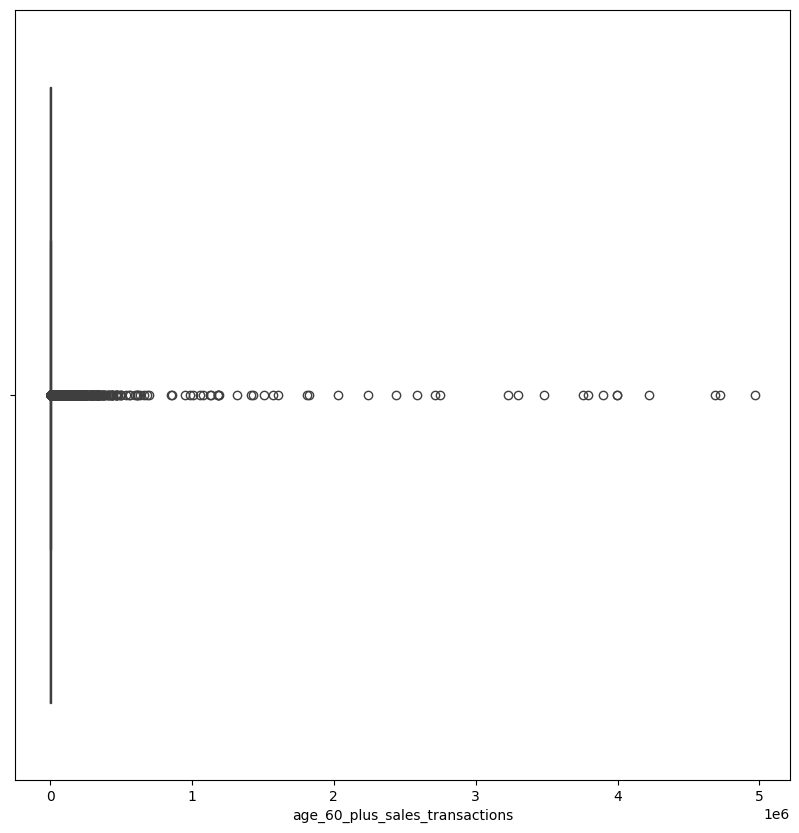

In [19]:
for i in z:
  if(z[i].dtype != "object") and ( i not in ["commercial_area_code", "service_industry_code"]):
    plt.figure(figsize = (10, 10))
    sns.boxplot(x = z[i], data = z)

**Bivaraite Analysis**

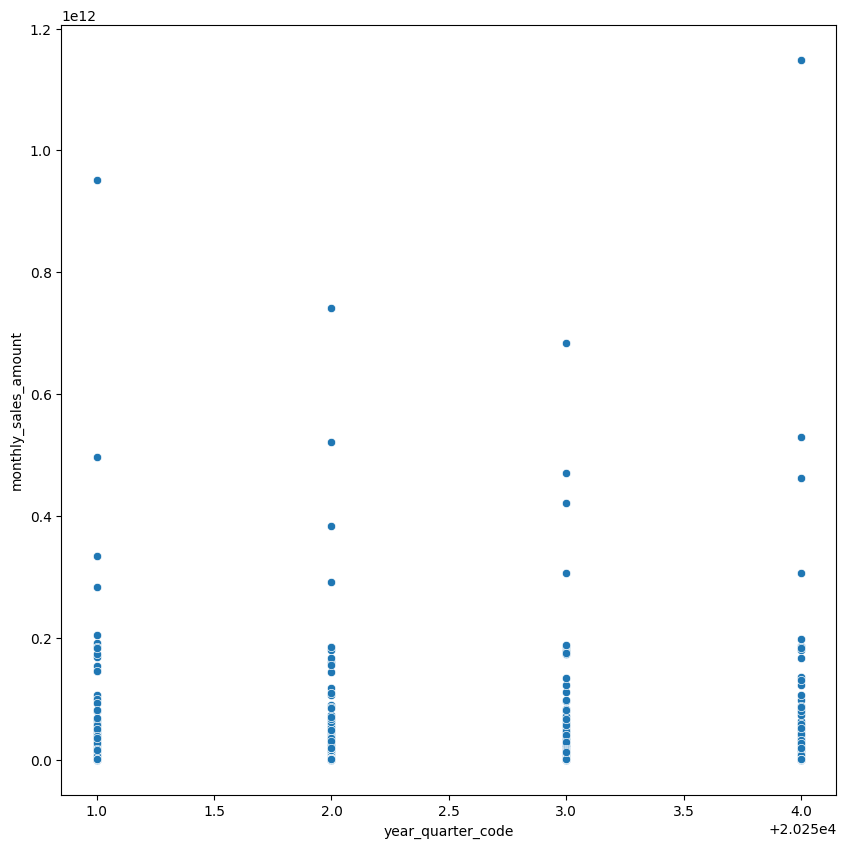

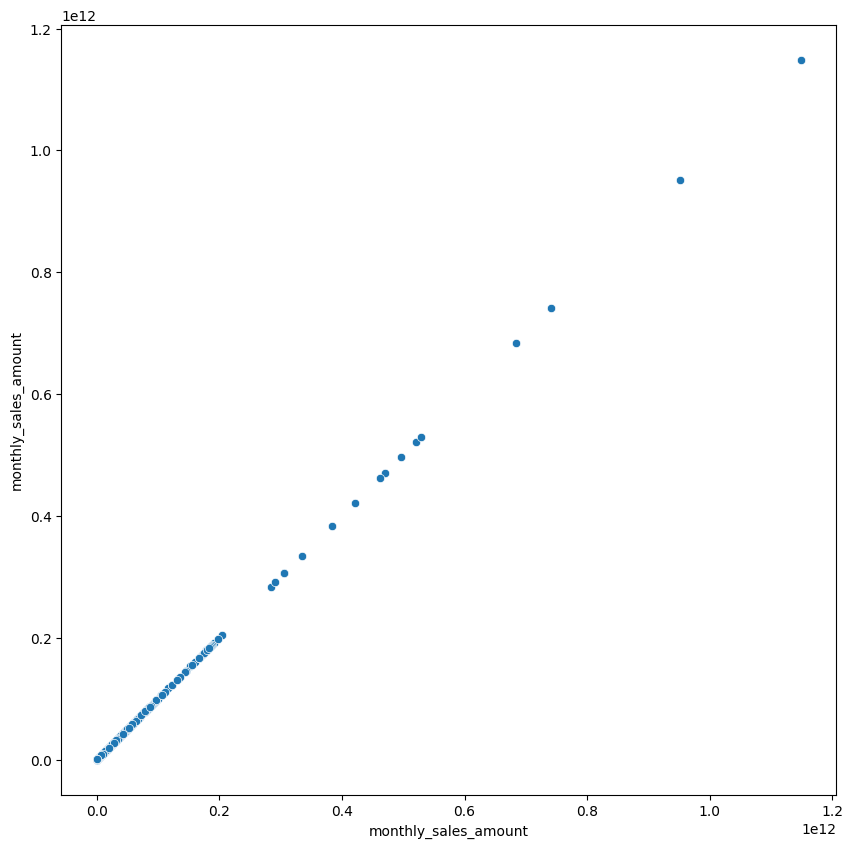

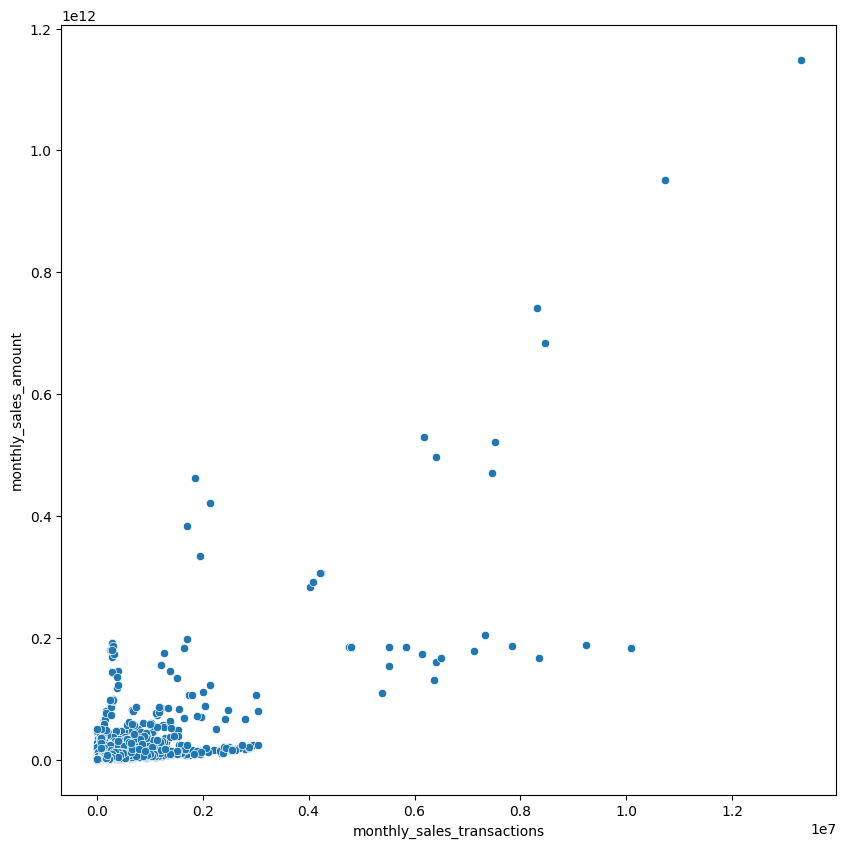

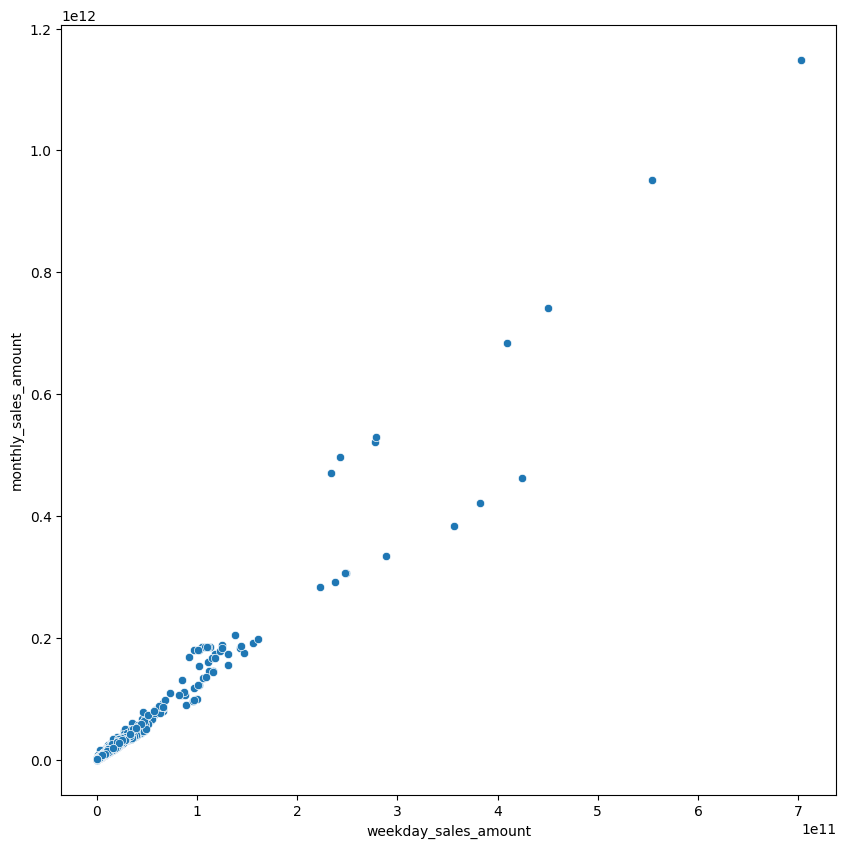

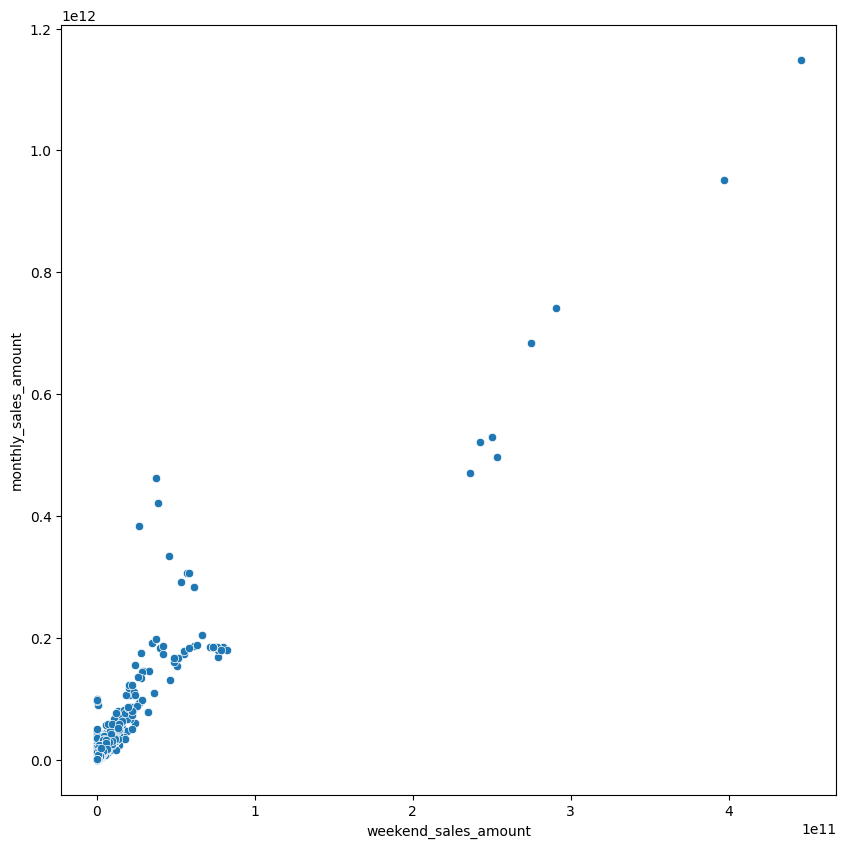

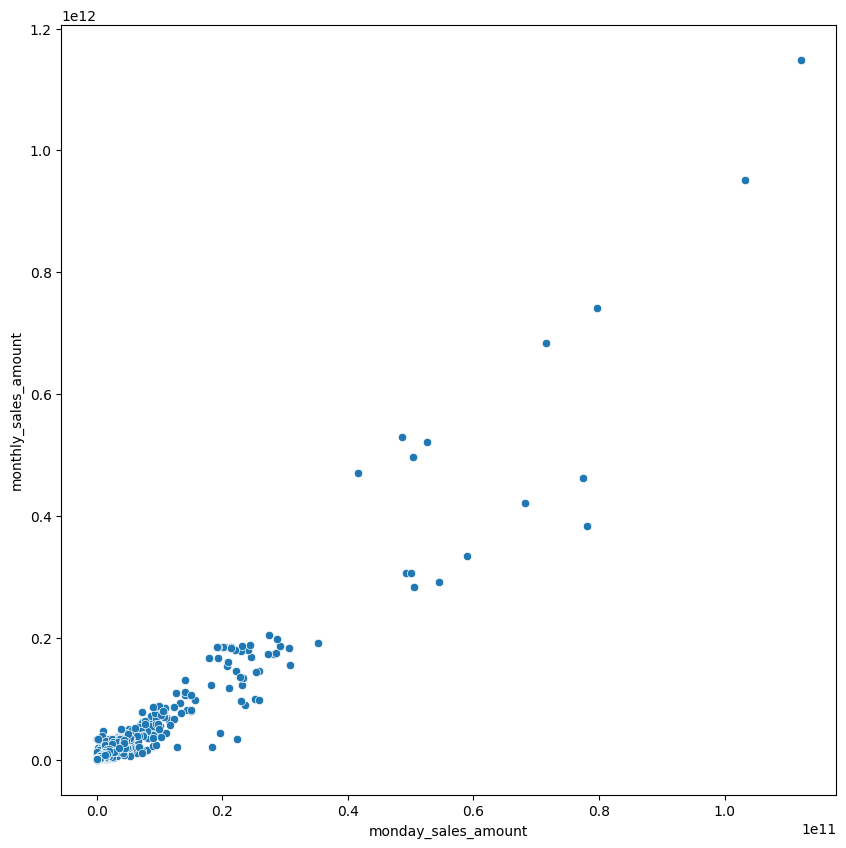

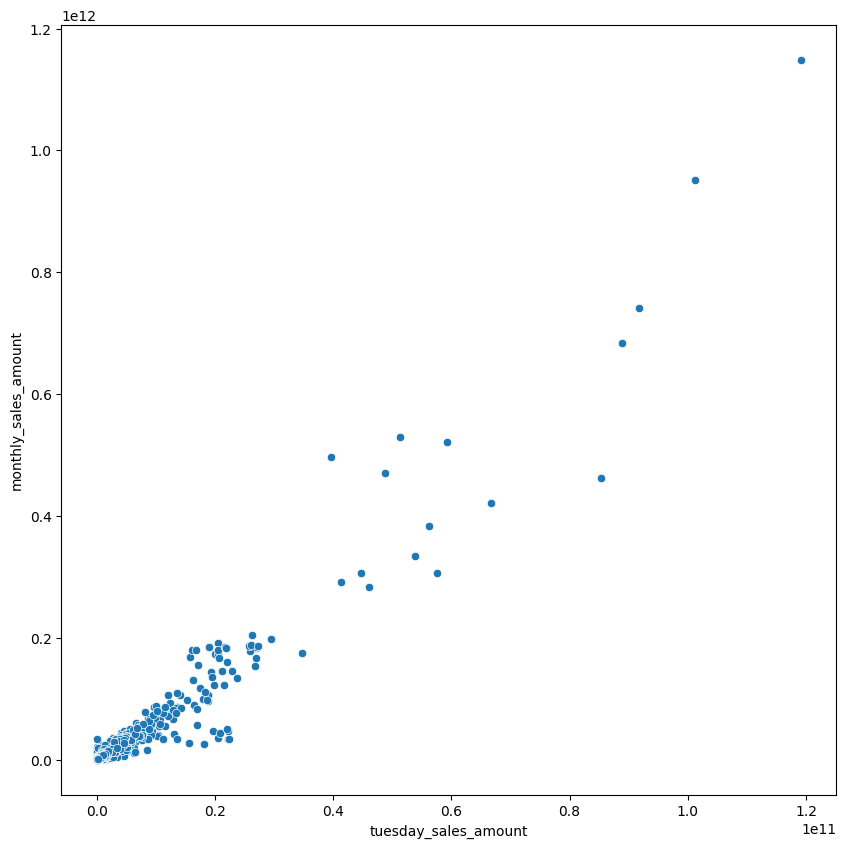

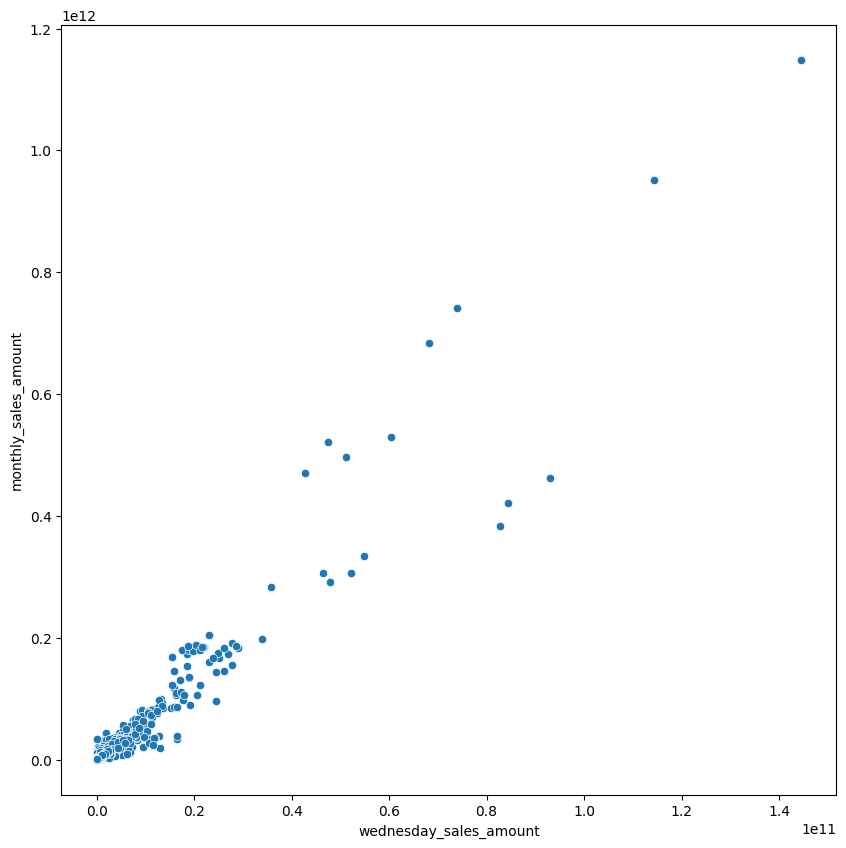

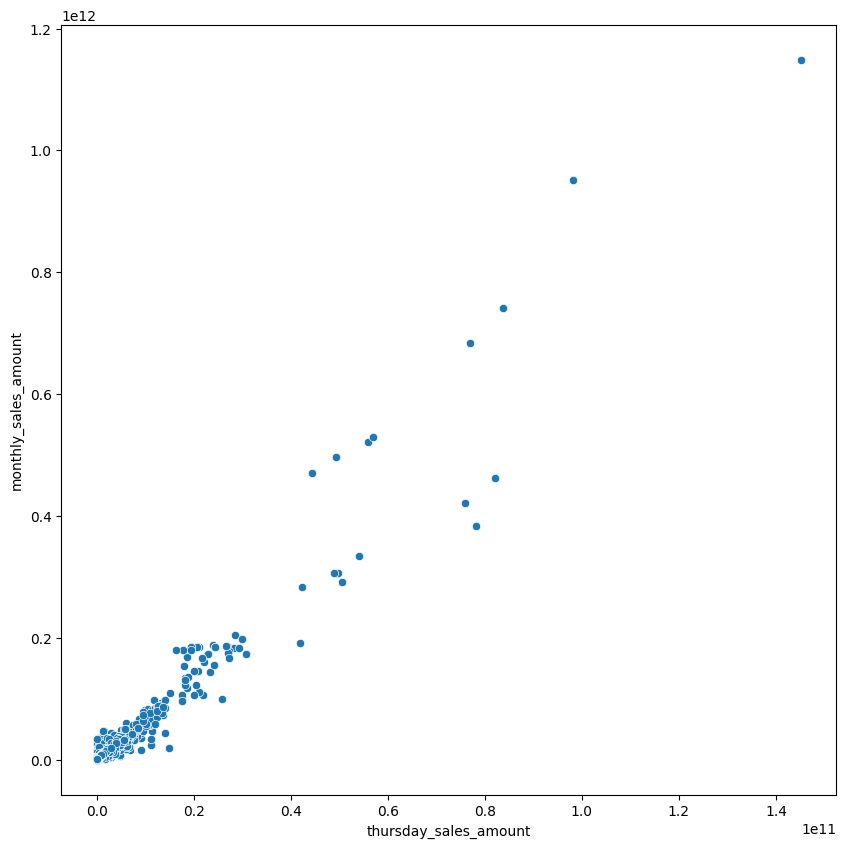

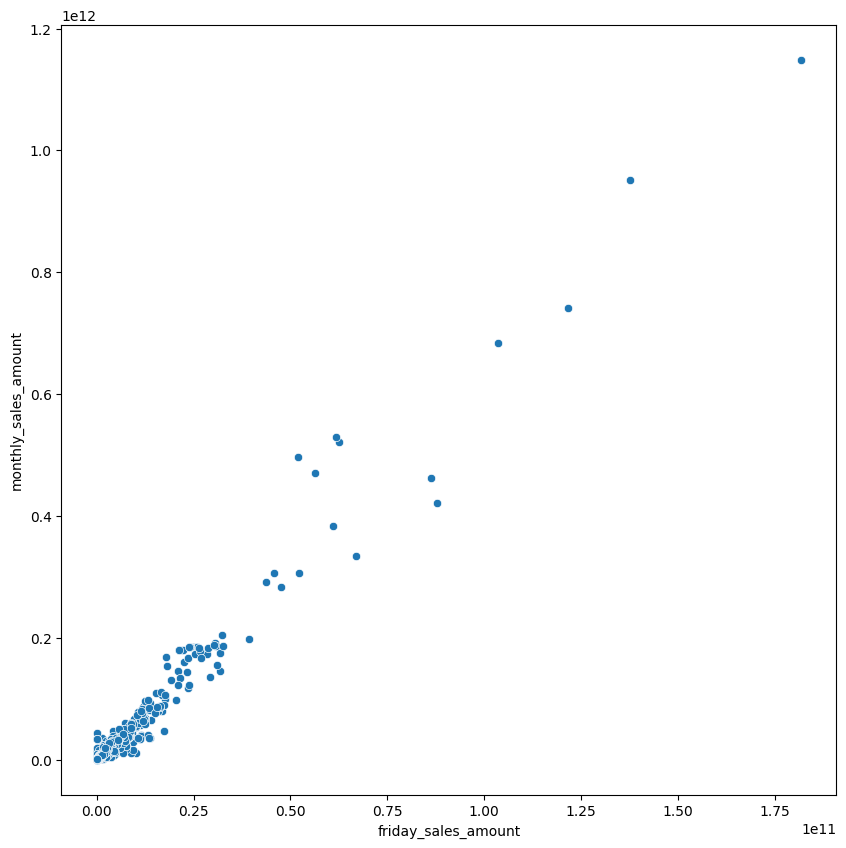

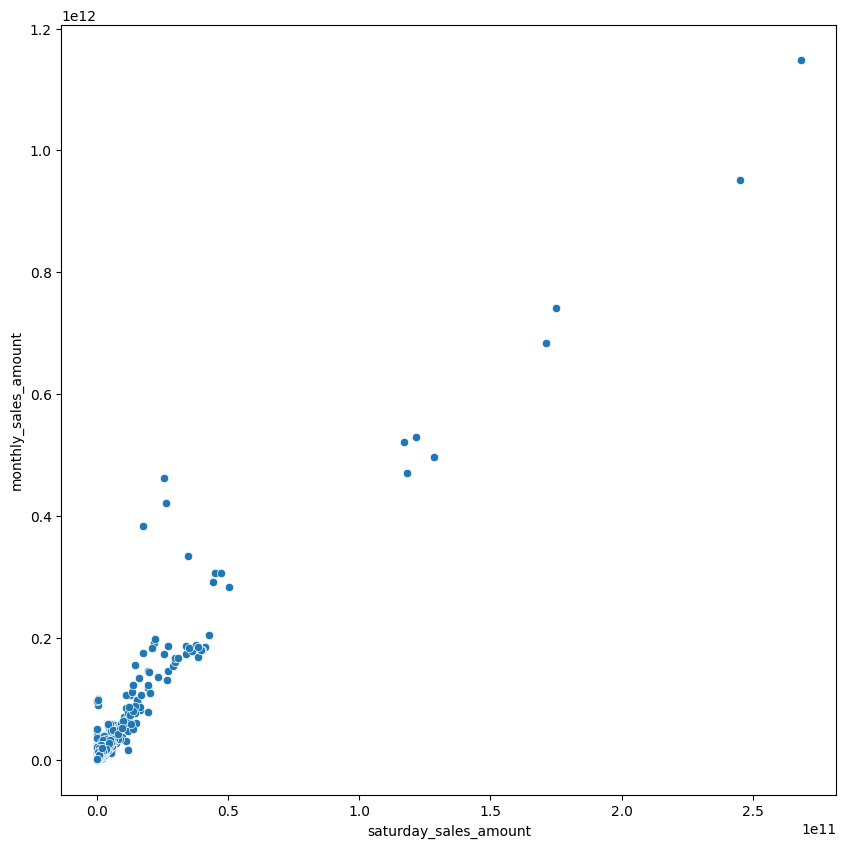

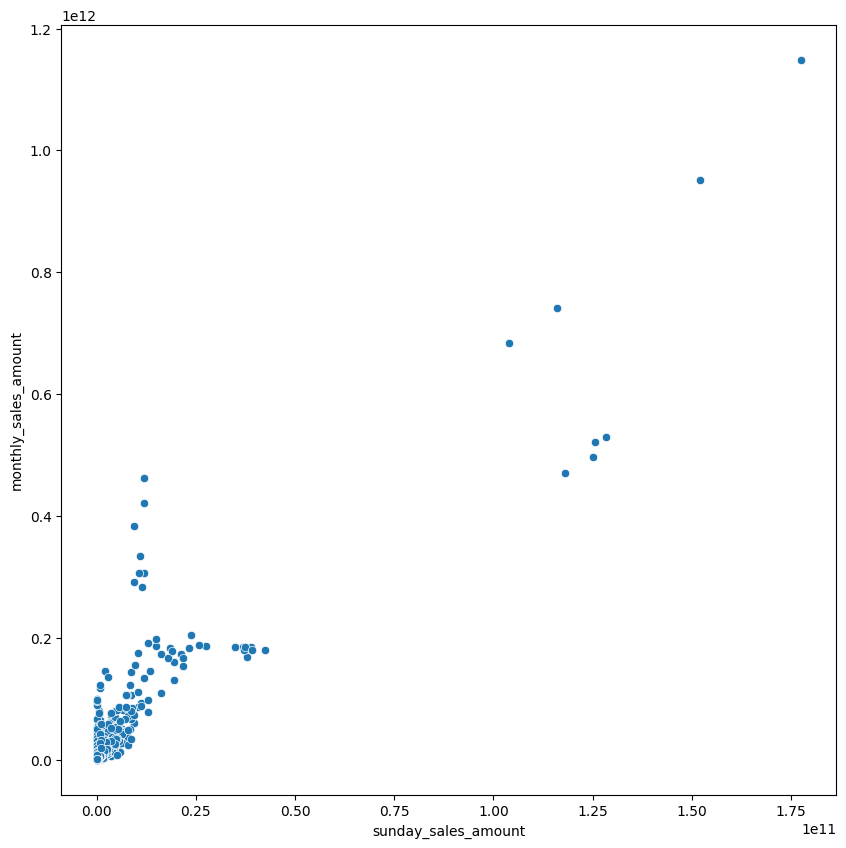

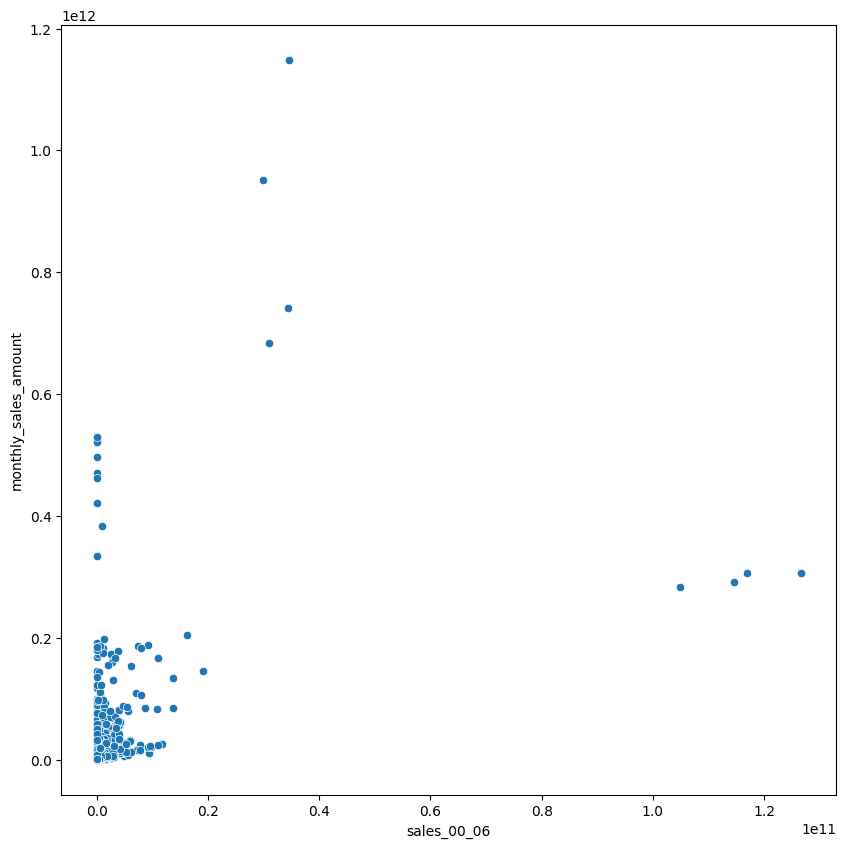

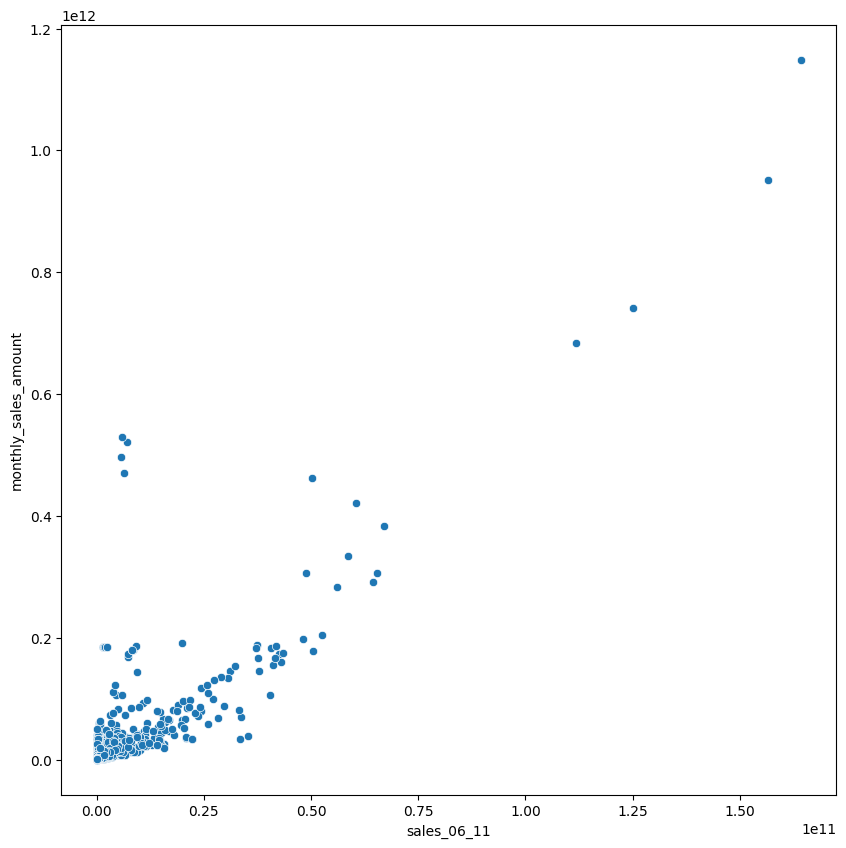

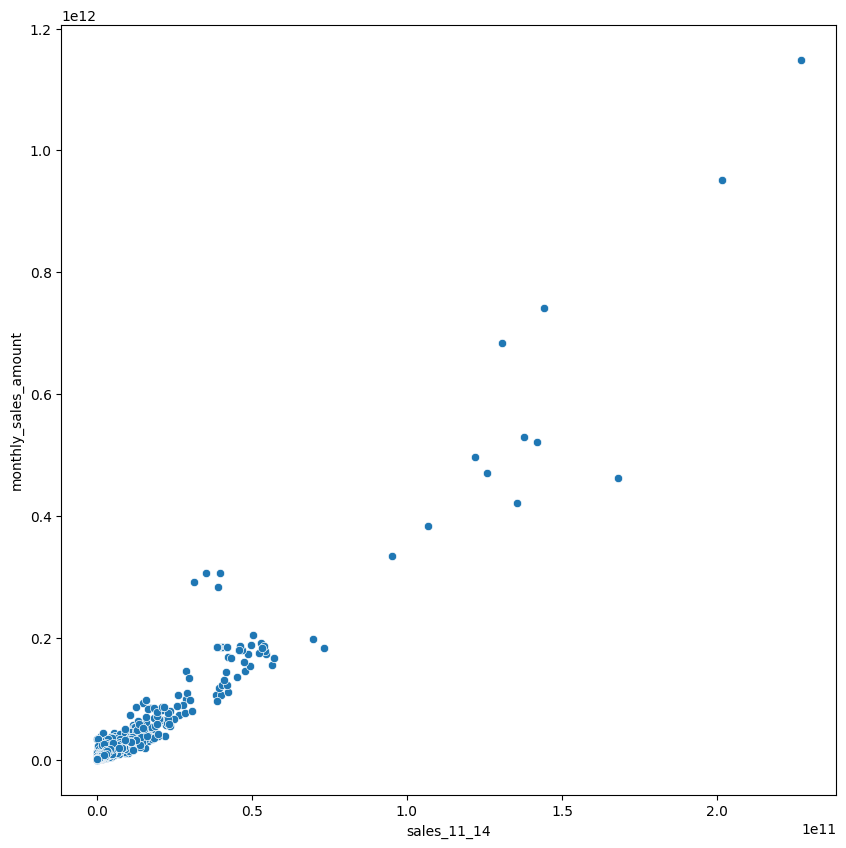

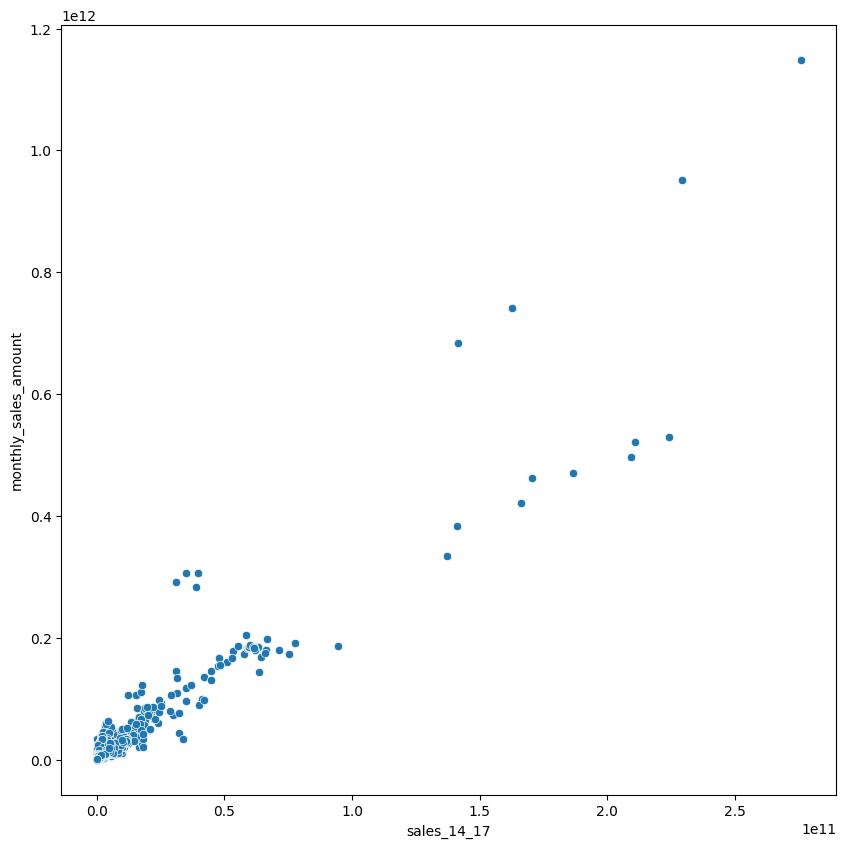

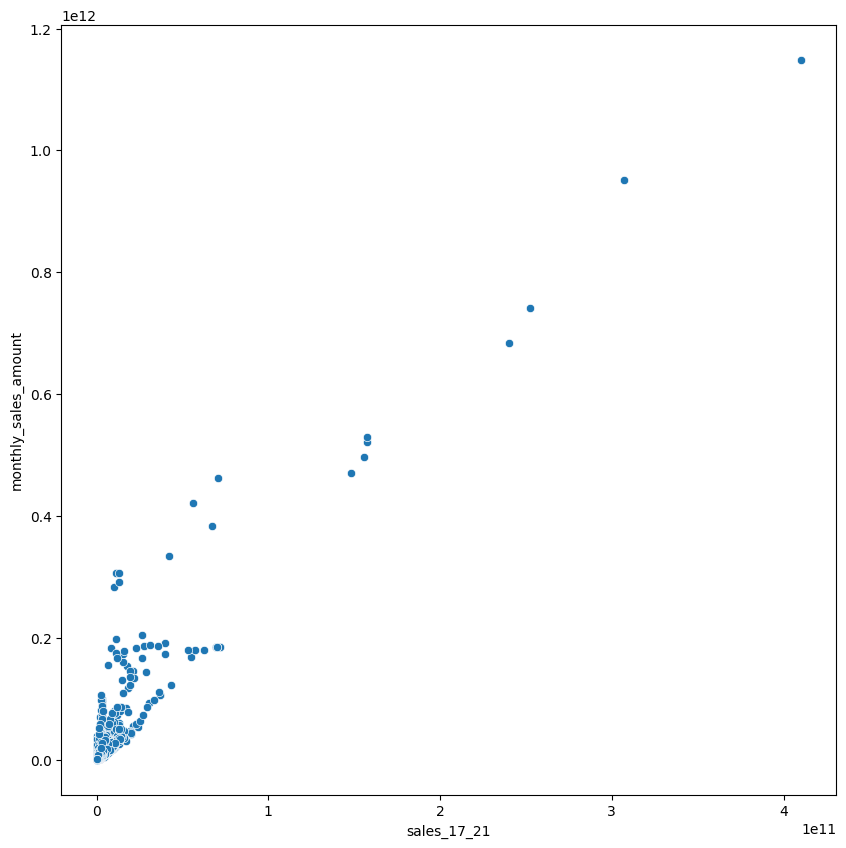

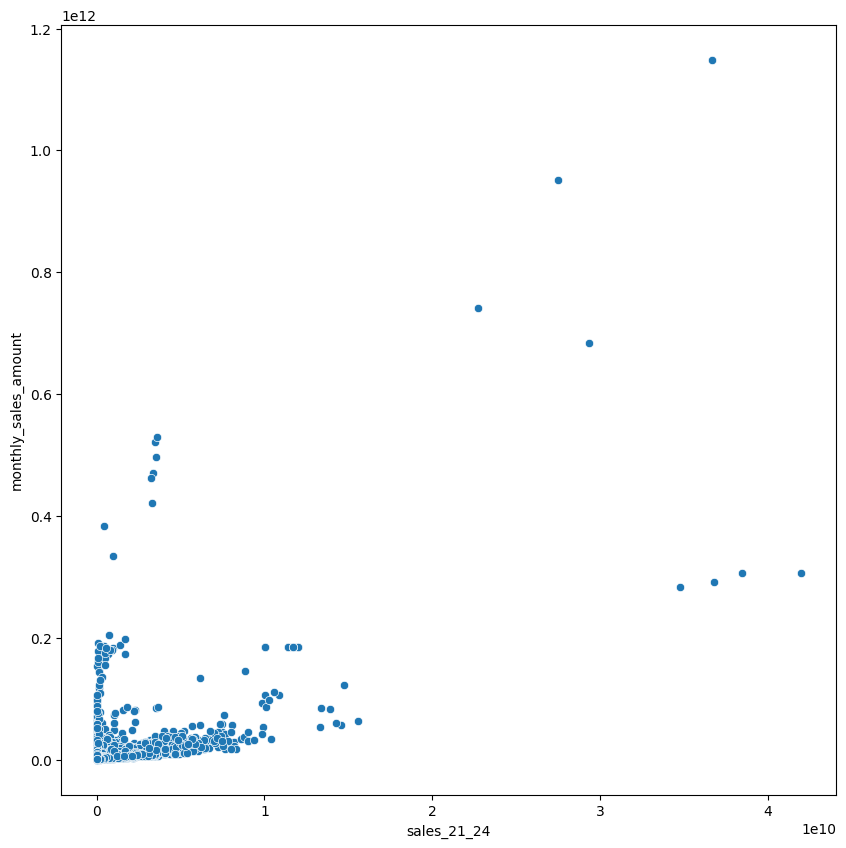

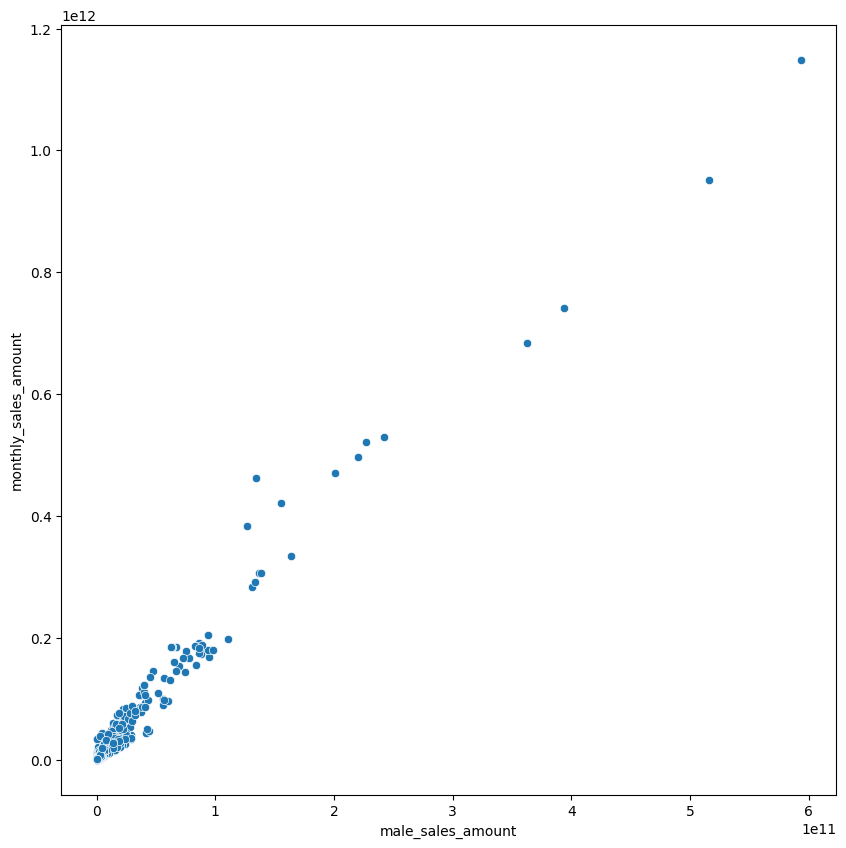

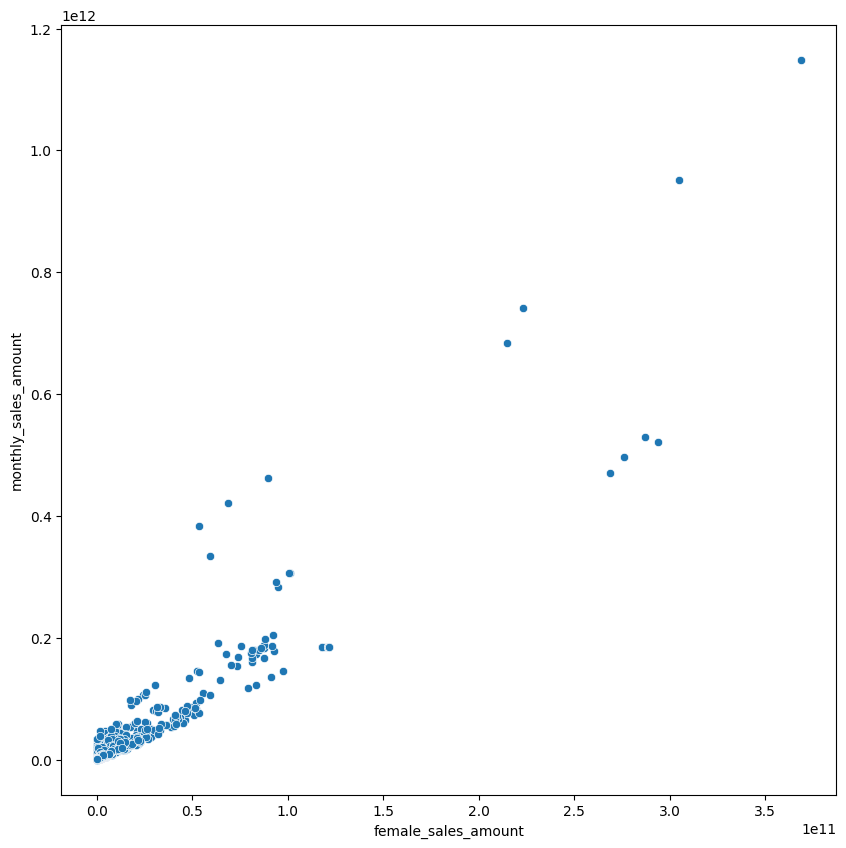

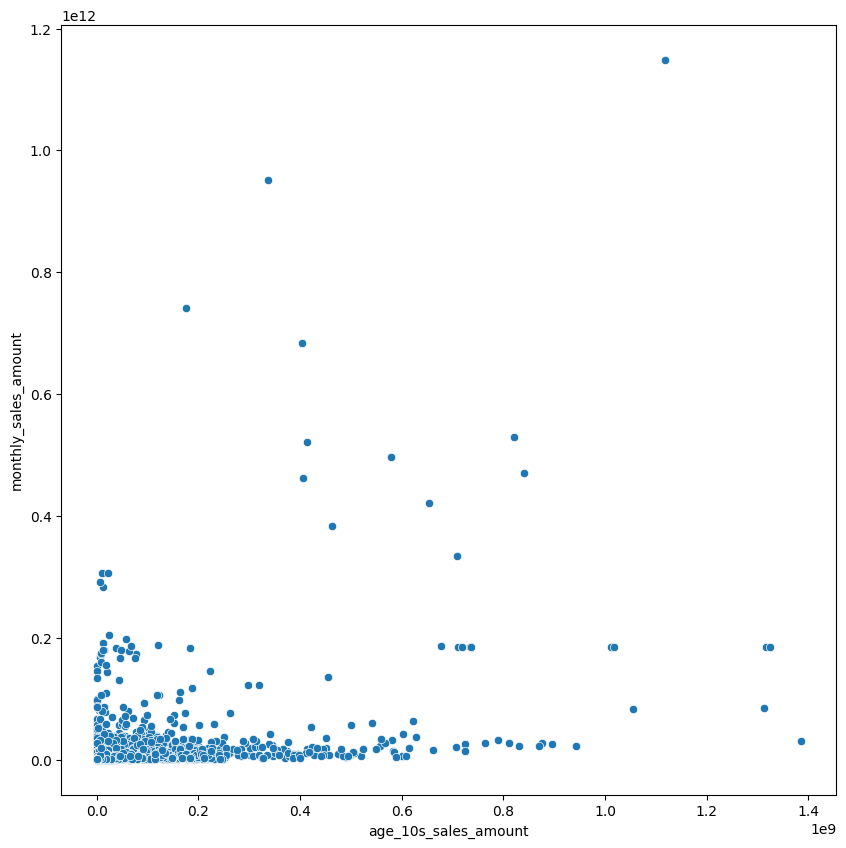

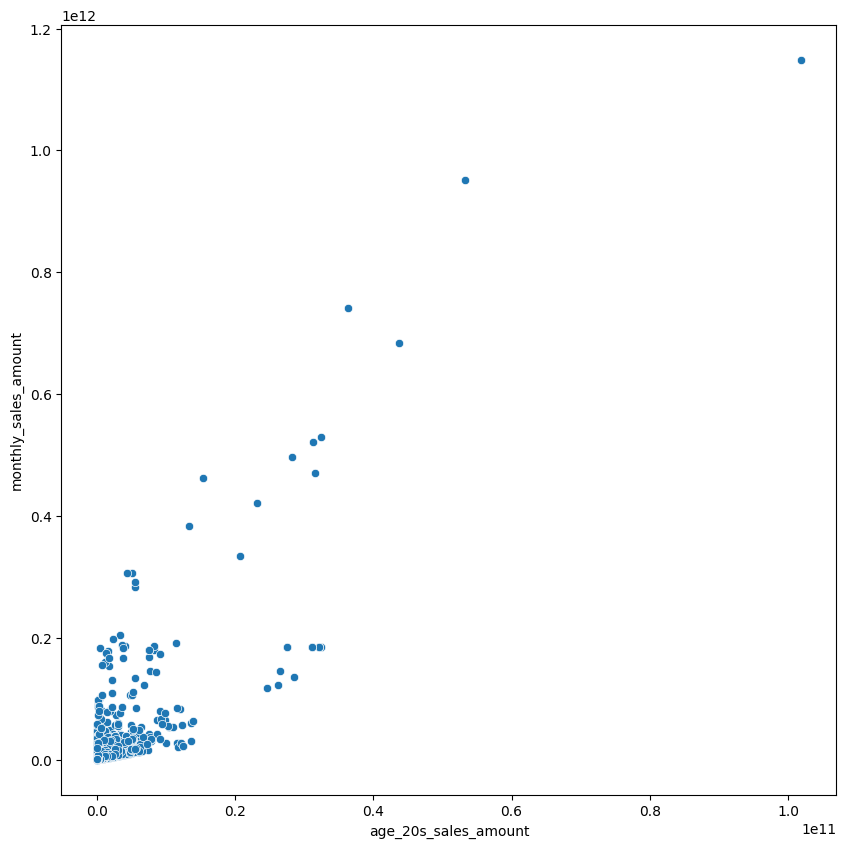

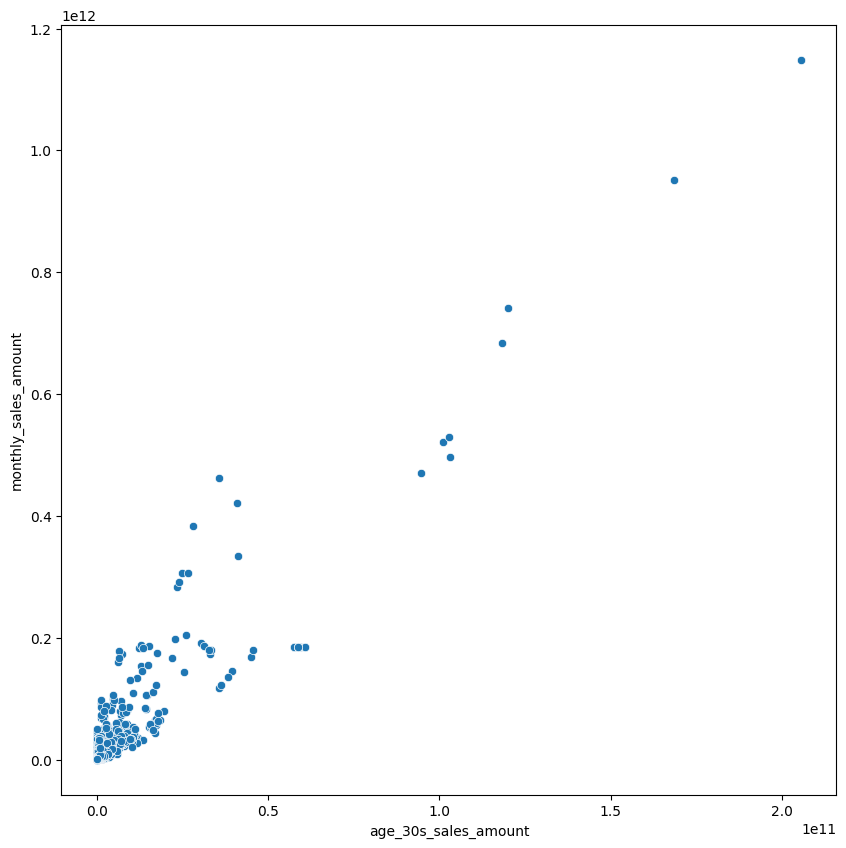

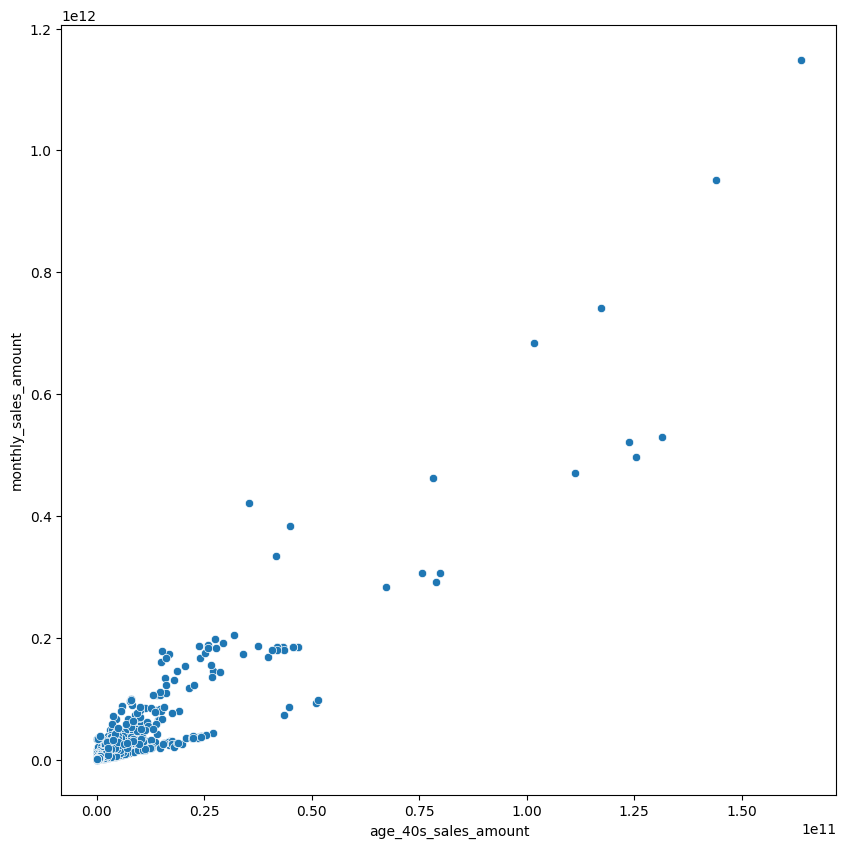

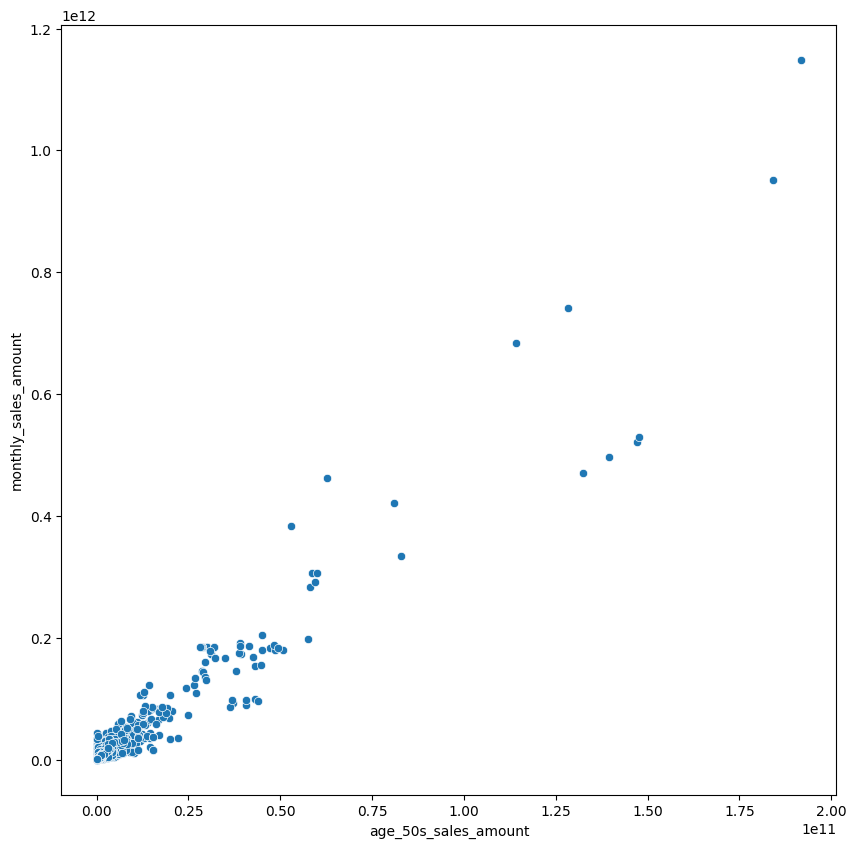

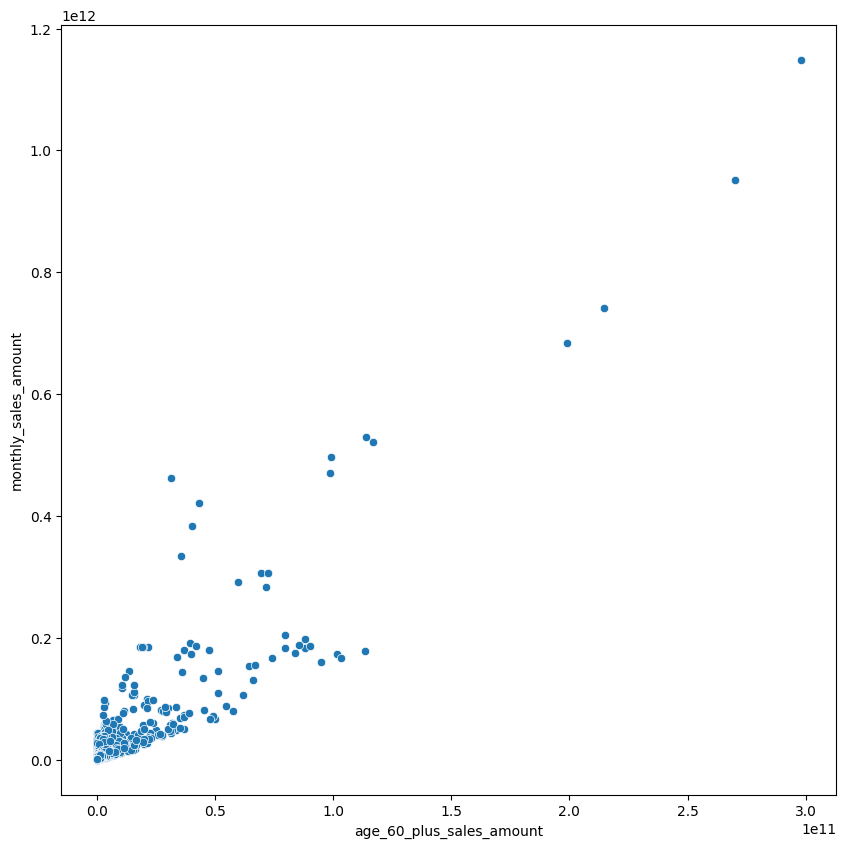

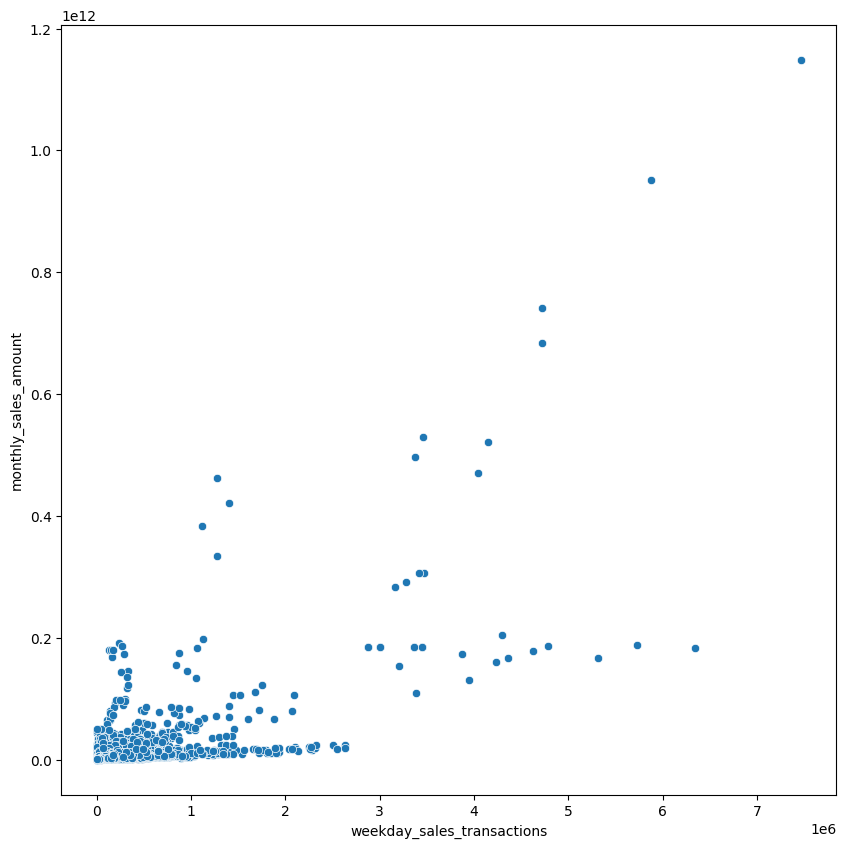

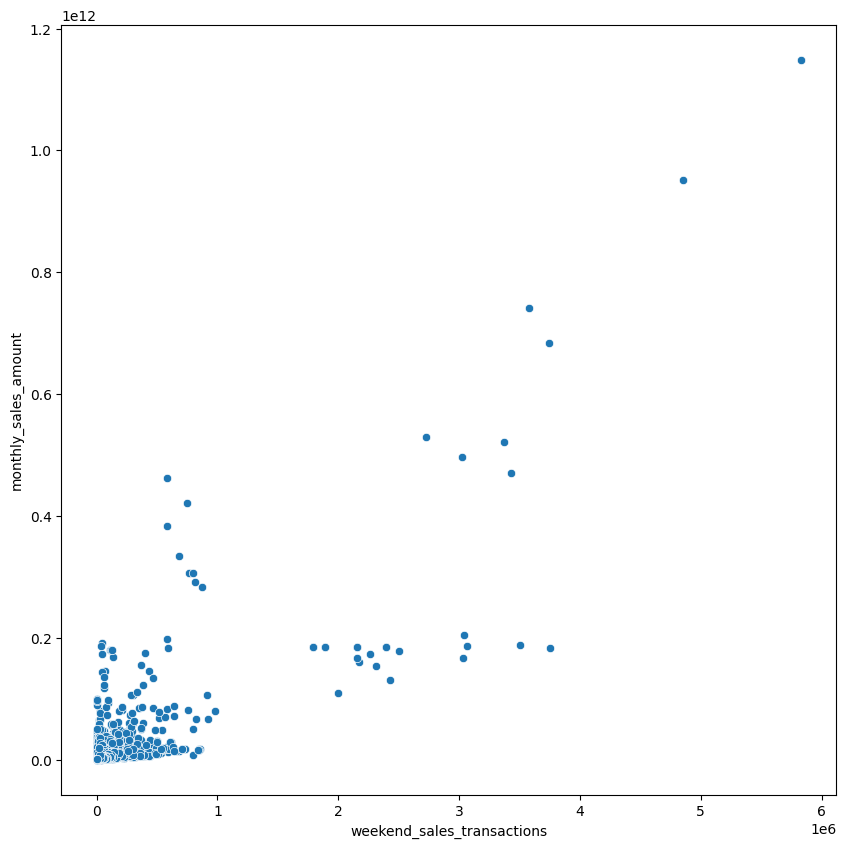

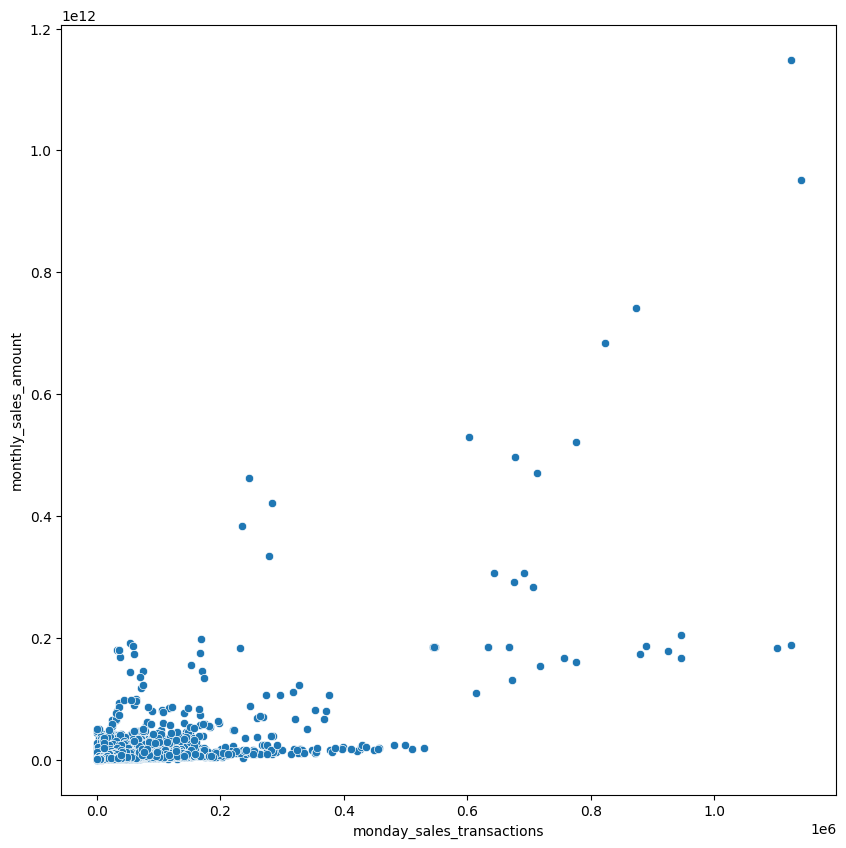

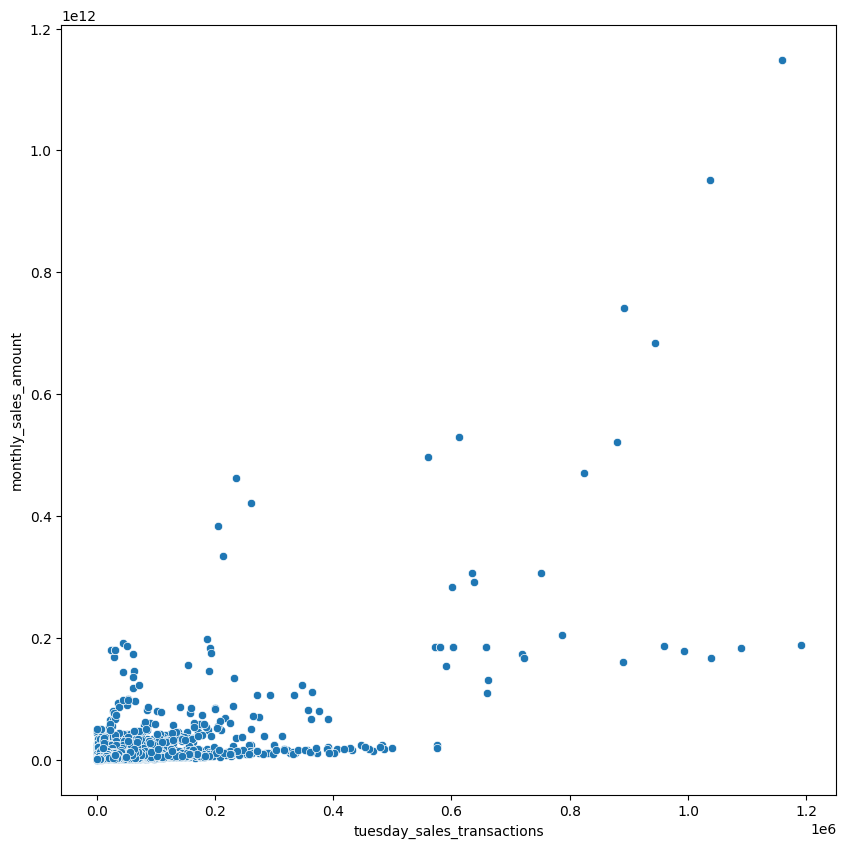

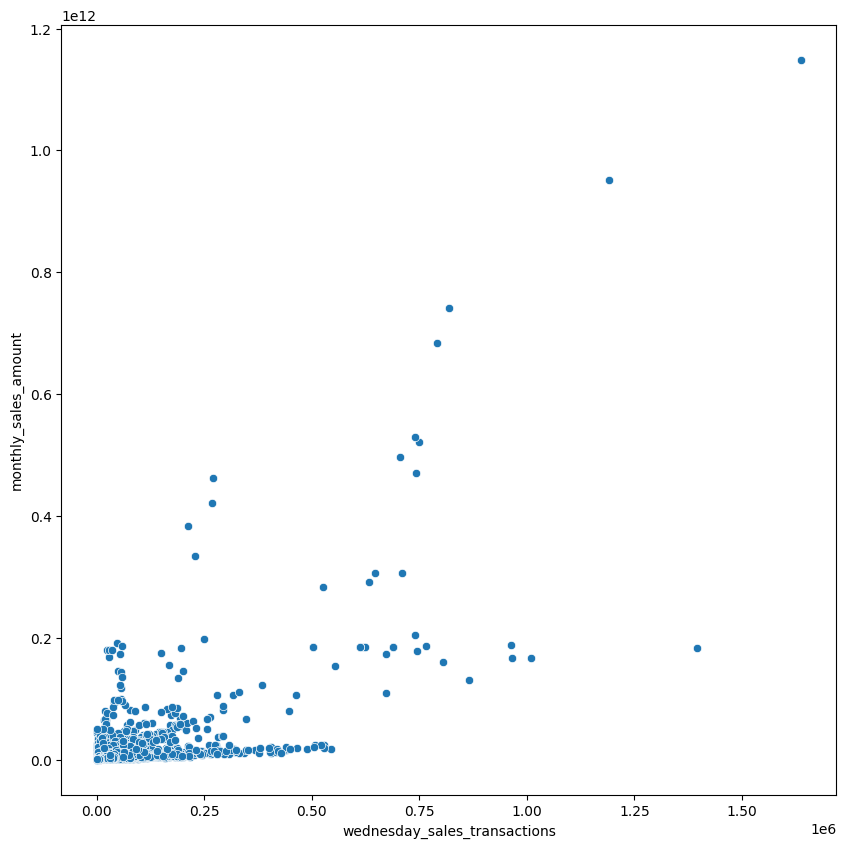

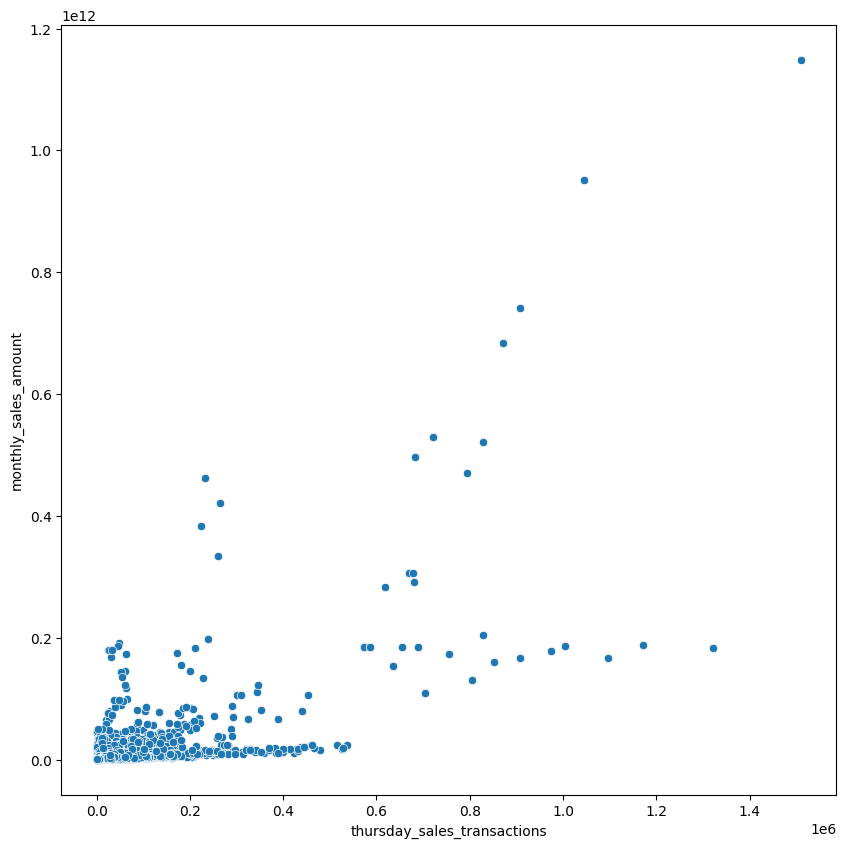

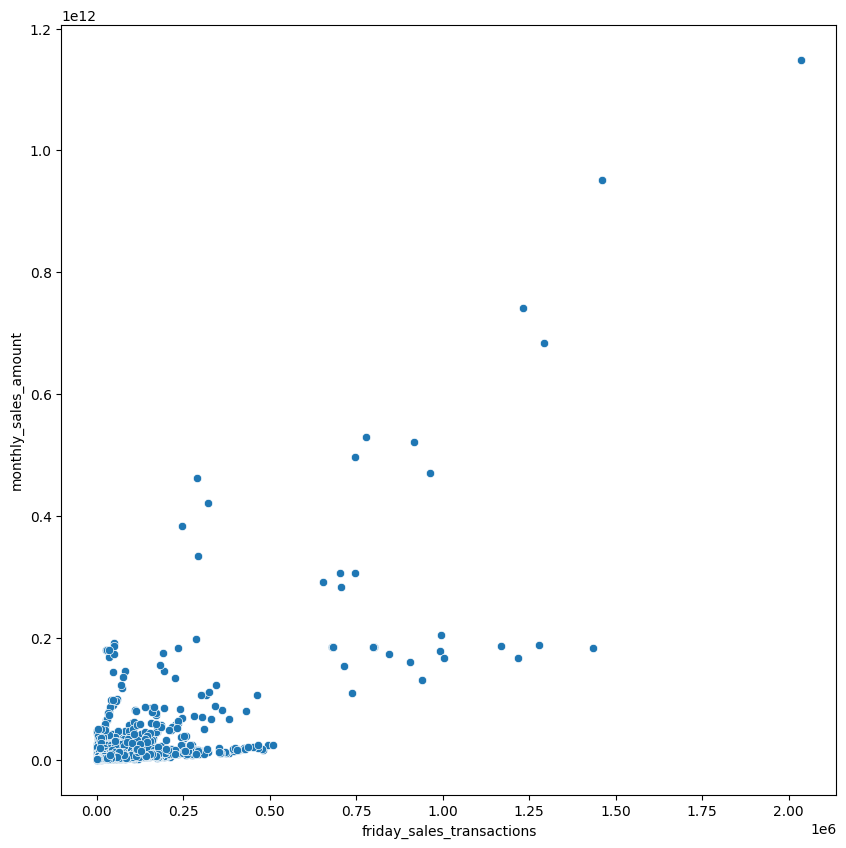

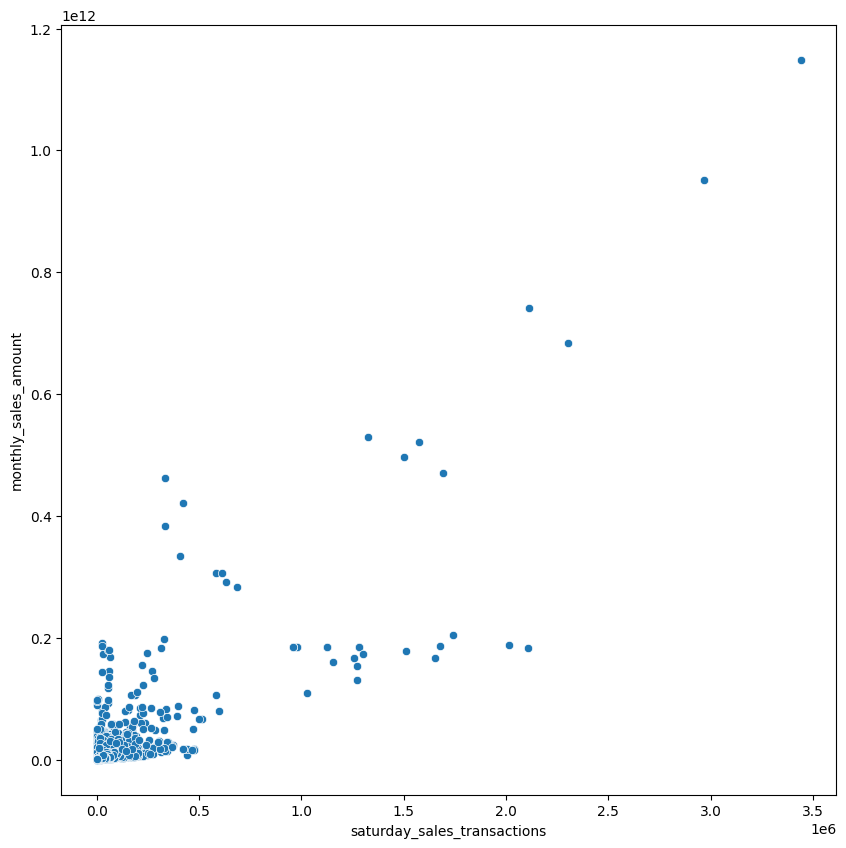

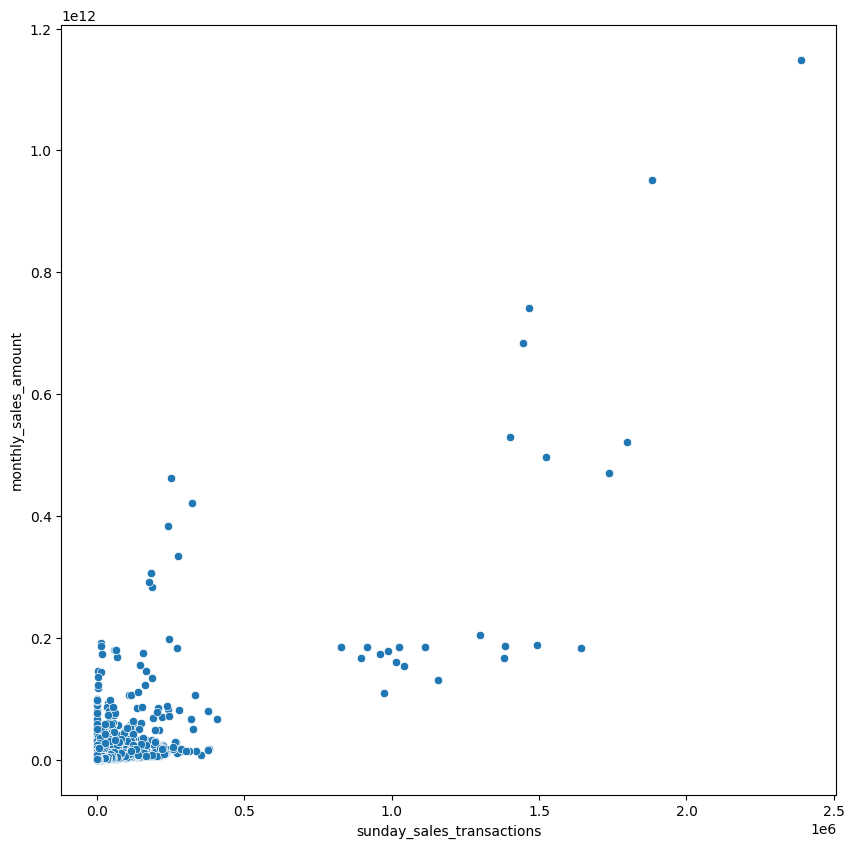

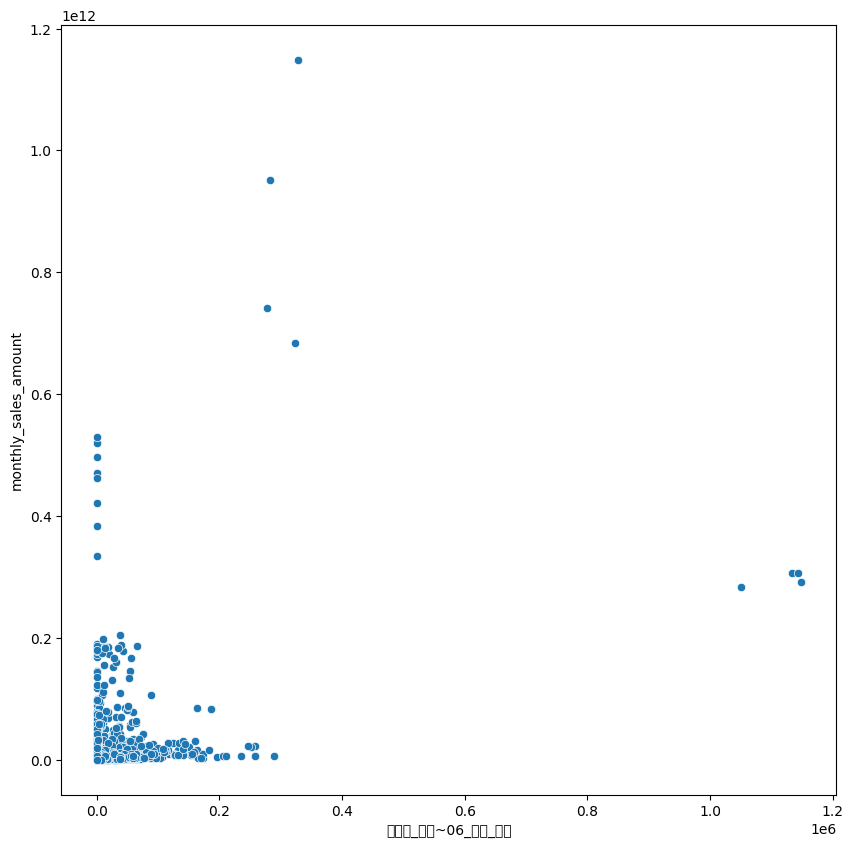

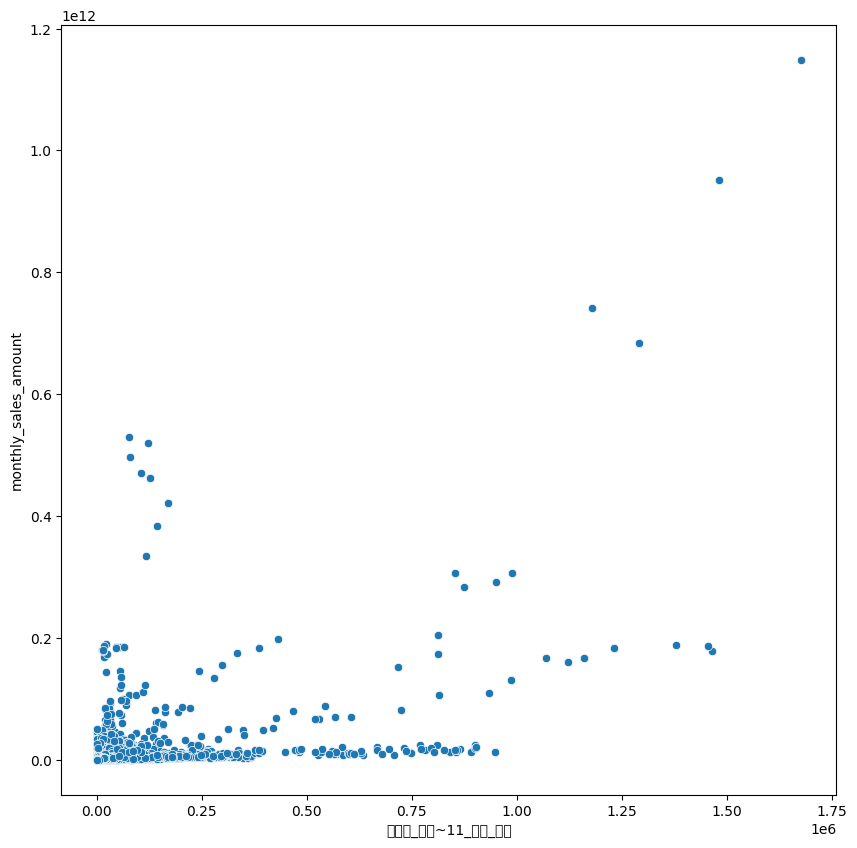

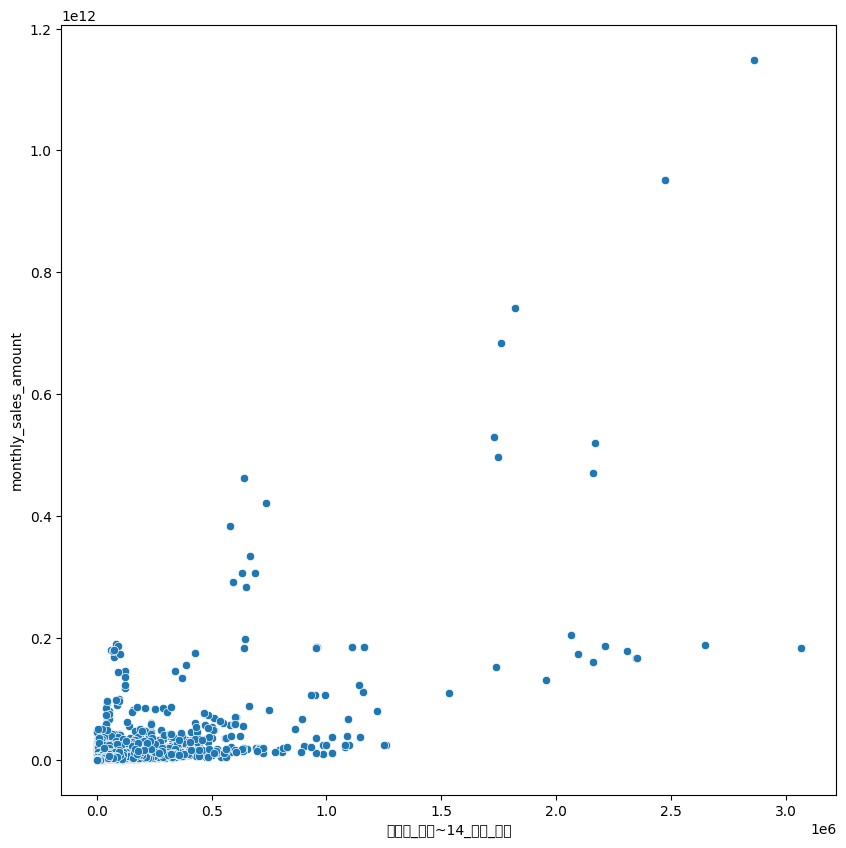

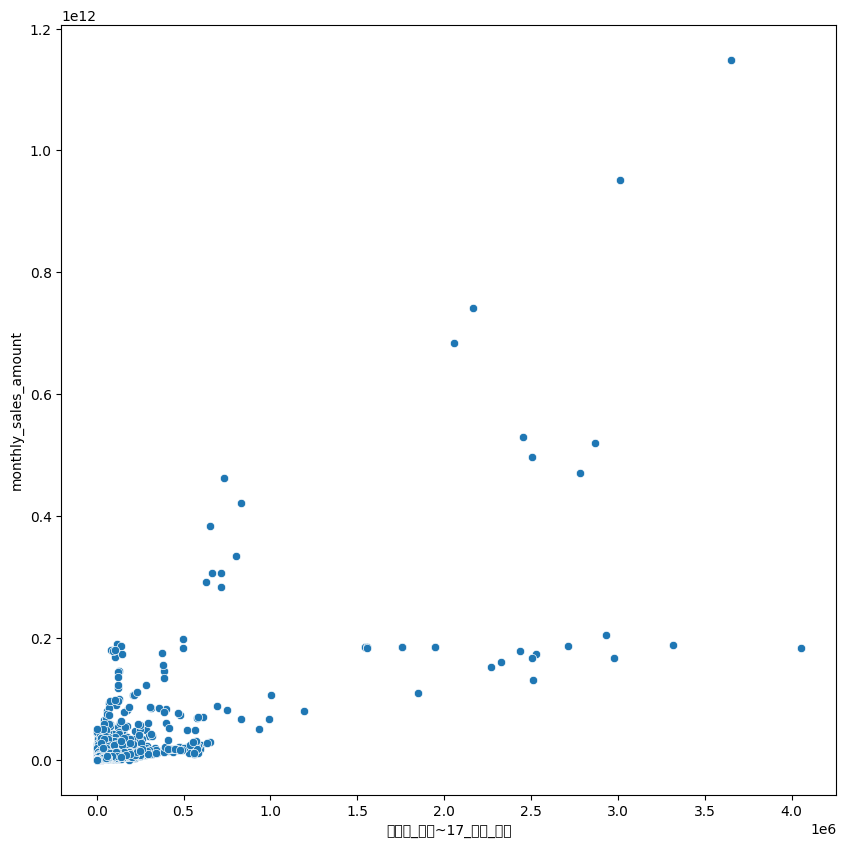

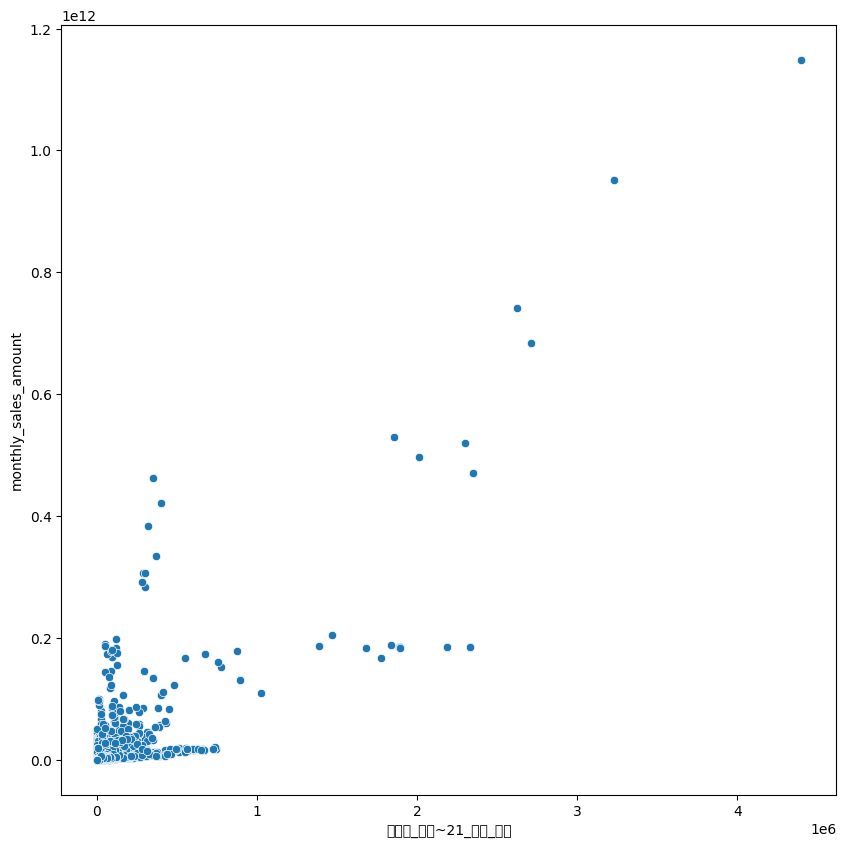

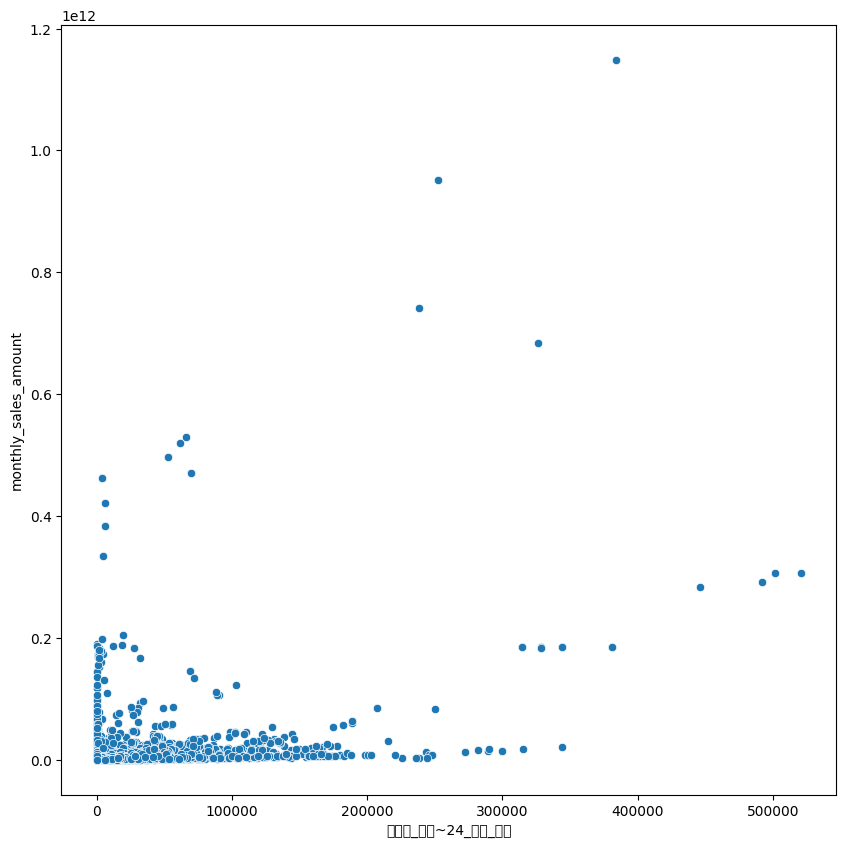

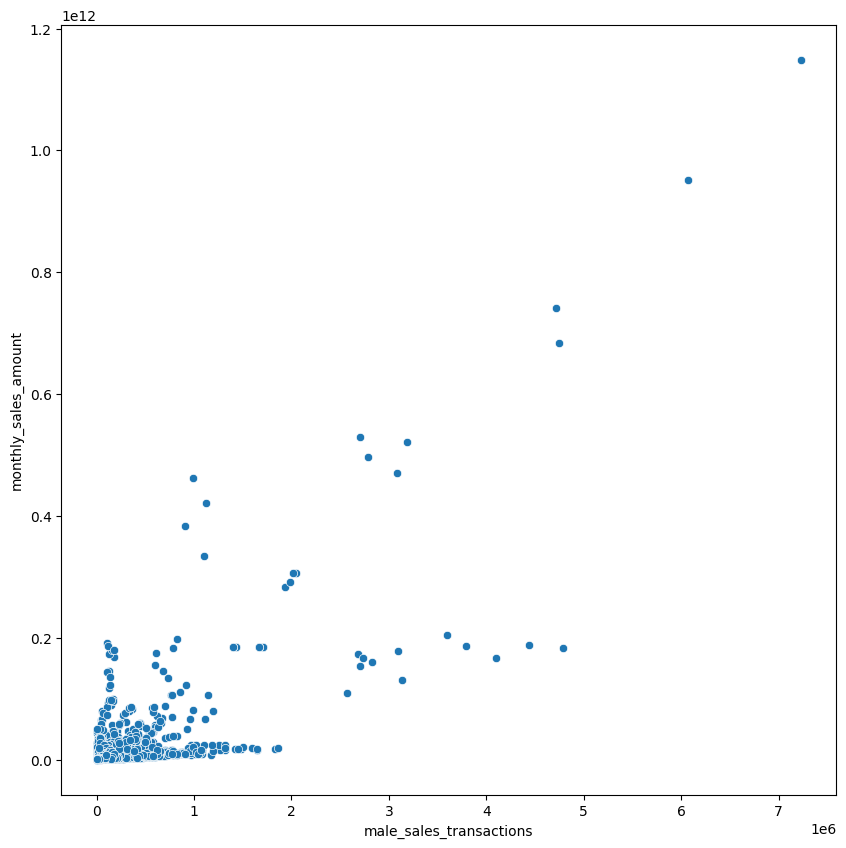

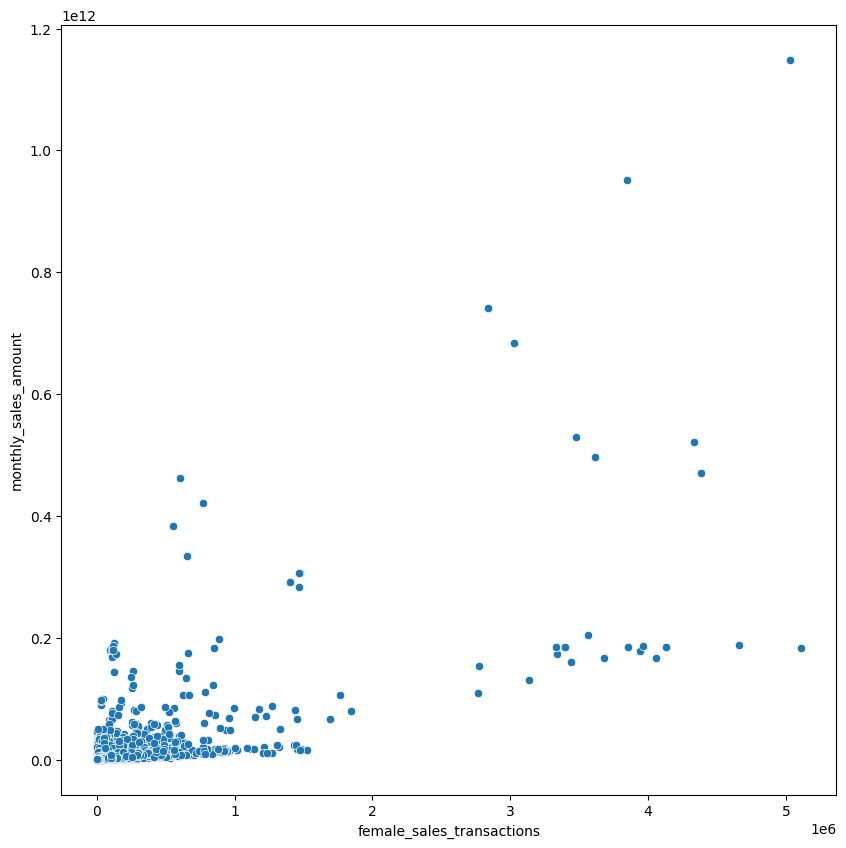

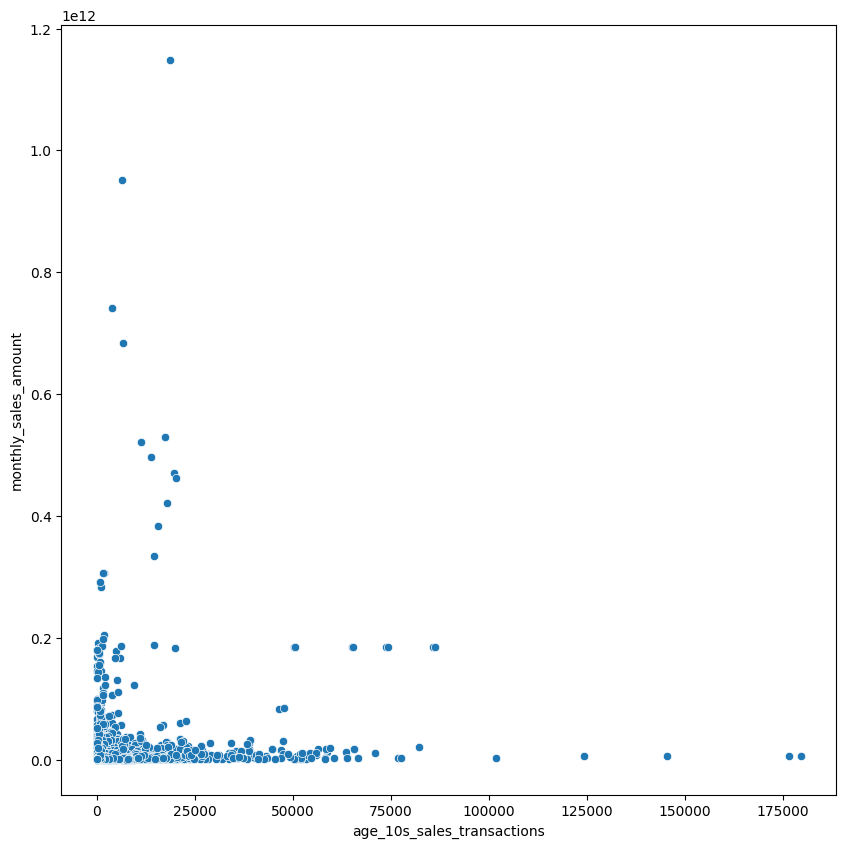

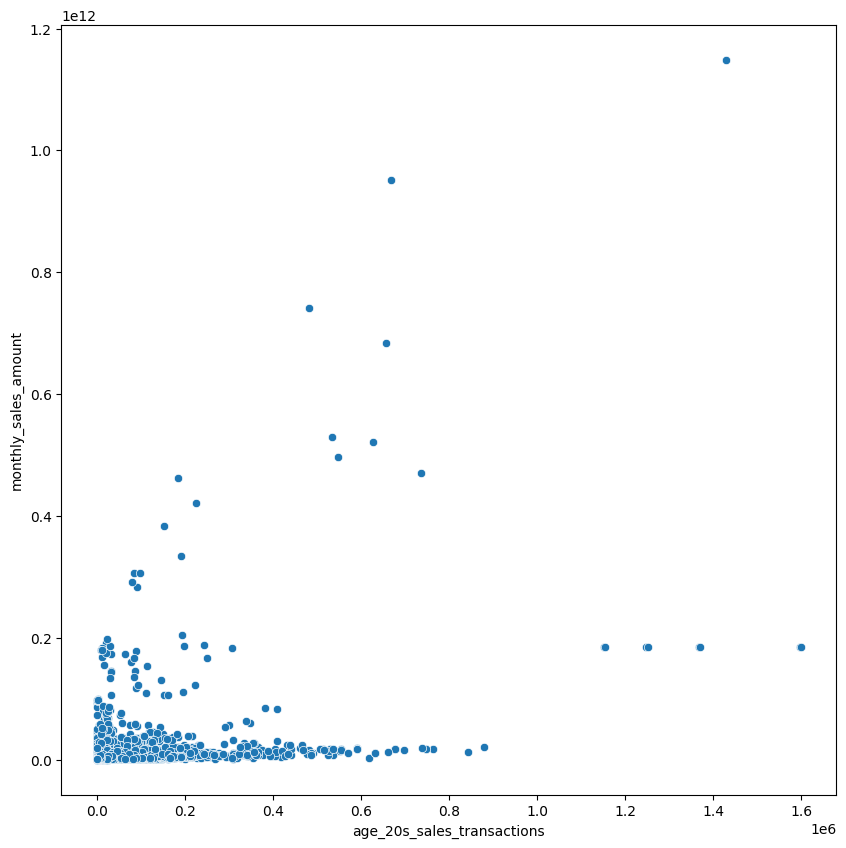

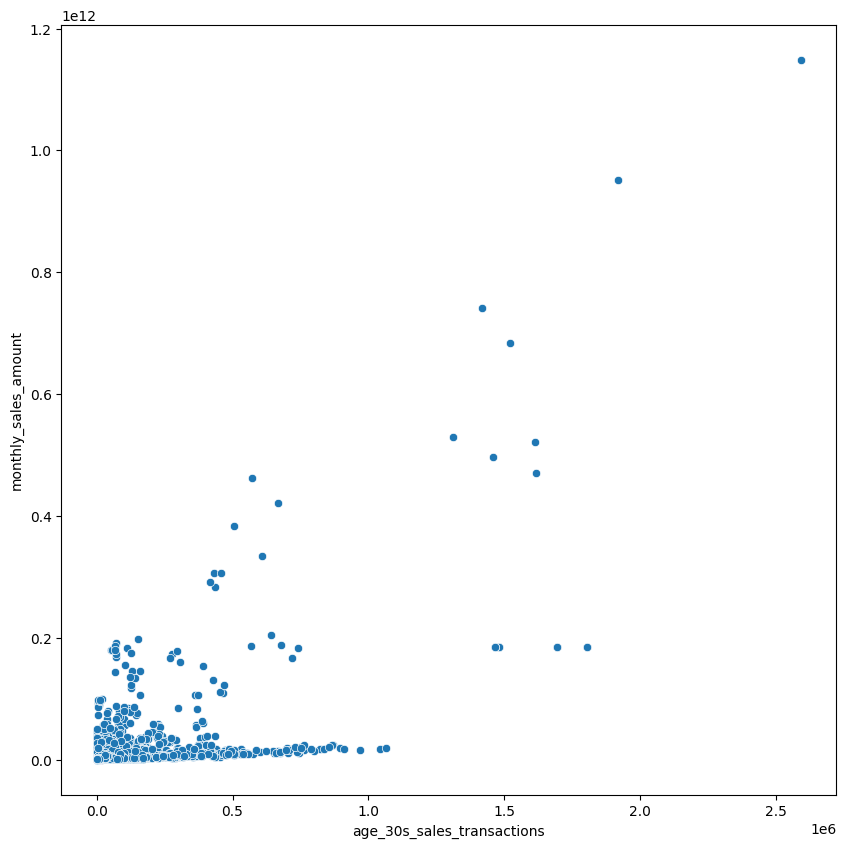

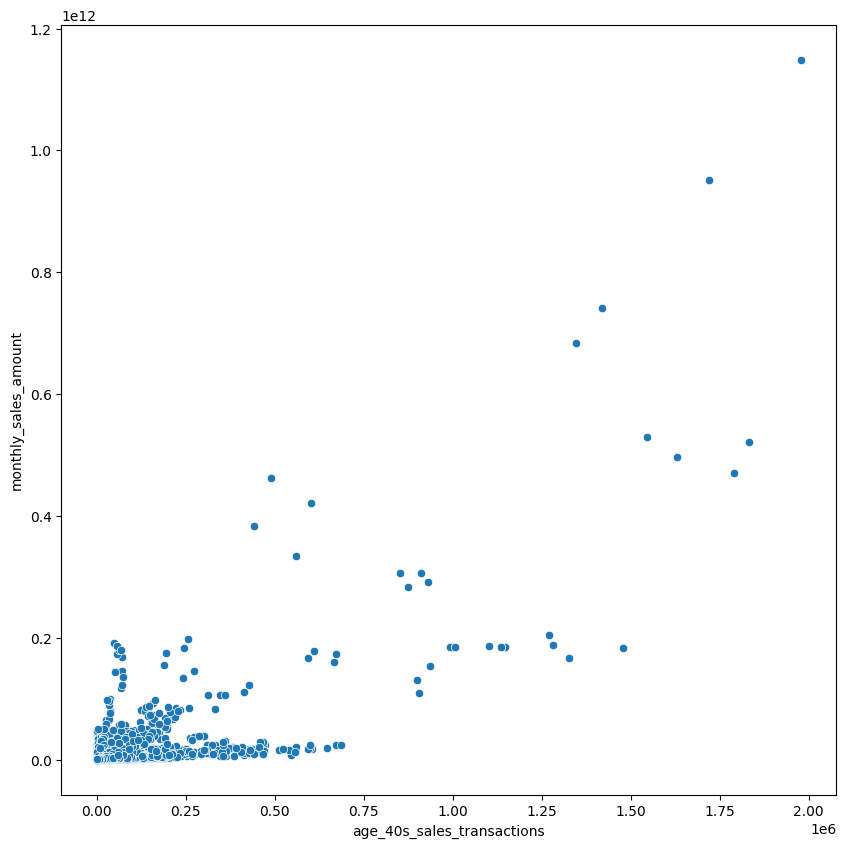

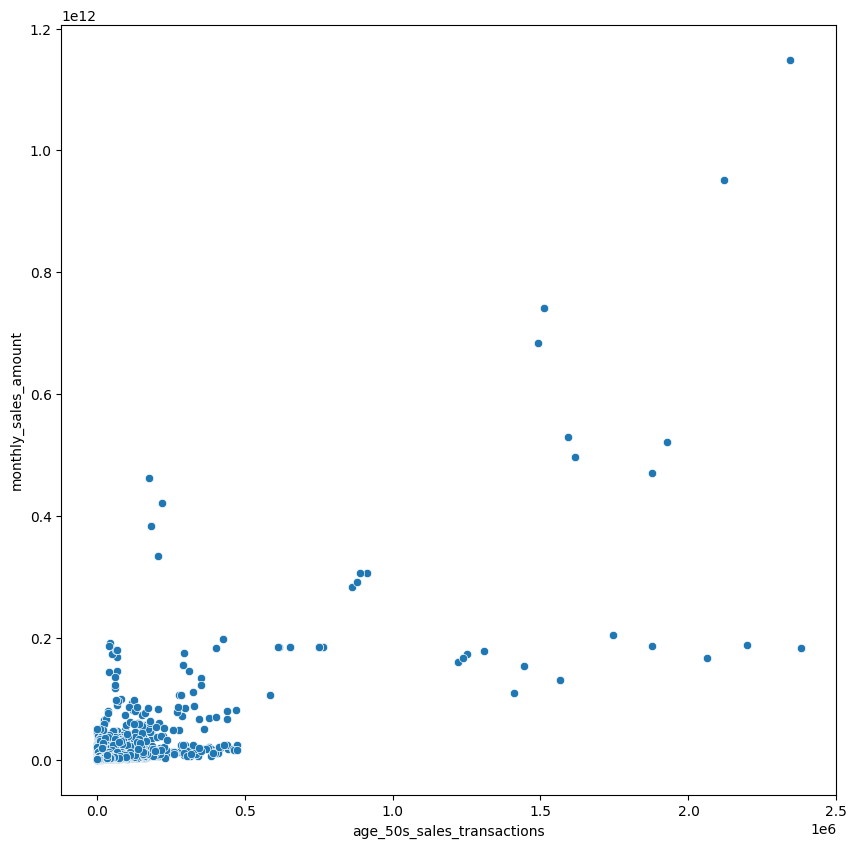

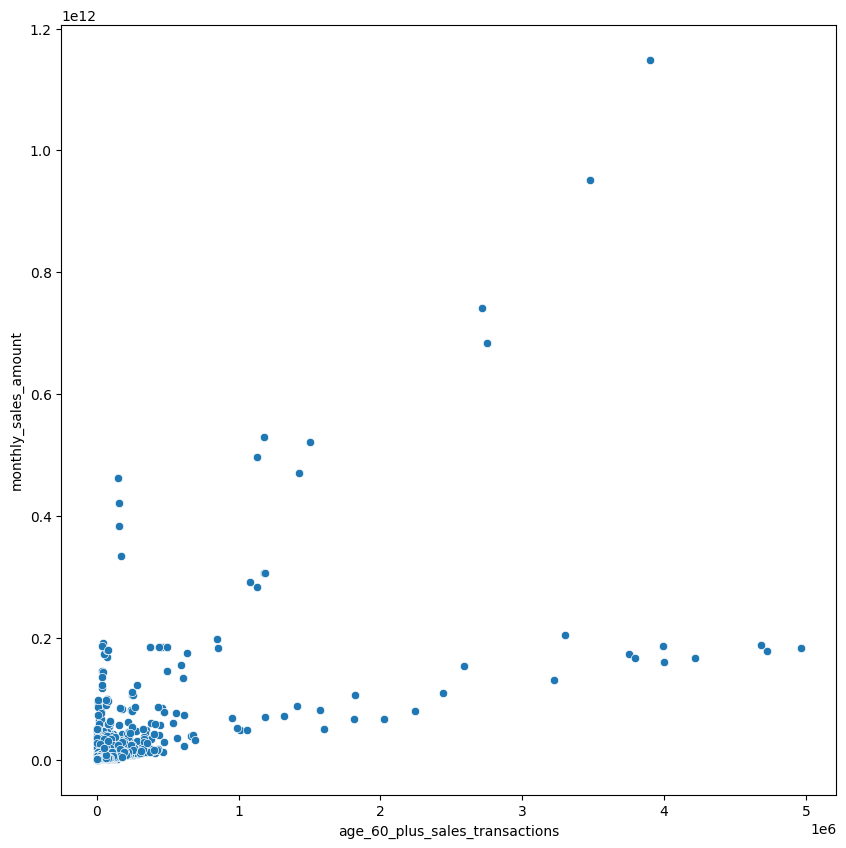

In [20]:
for i in z:
  if(z[i].dtype != "object") and ( i not in ["commercial_area_code", "service_industry_code"]):
    plt.figure(figsize = (10, 10))
    sns.scatterplot(x = z[i], y = z["monthly_sales_amount"], data = z)

In [21]:
z.corr(numeric_only = True)

,year_quarter_code,commercial_area_code,monthly_sales_amount,monthly_sales_transactions,weekday_sales_amount,weekend_sales_amount,monday_sales_amount,tuesday_sales_amount,wednesday_sales_amount,thursday_sales_amount,...,시간대_건수~21_매출_건수,시간대_건수~24_매출_건수,male_sales_transactions,female_sales_transactions,age_10s_sales_transactions,age_20s_sales_transactions,age_30s_sales_transactions,age_40s_sales_transactions,age_50s_sales_transactions,age_60_plus_sales_transactions
year_quarter_code,1.000000,-0.001278,0.003982,0.005733,0.005106,0.001497,0.002262,0.007973,0.010604,0.003182,...,0.003962,0.006493,0.004785,0.006296,0.020029,0.008496,0.002063,0.004588,0.004786,0.004699
commercial_area_code,-0.001278,1.000000,-0.022413,-0.041403,-0.022843,-0.019392,-0.018431,-0.022676,-0.024409,-0.024503,...,-0.047754,-0.065040,-0.035636,-0.043765,-0.037220,-0.078592,-0.073788,-0.052116,-0.017025,0.008803
monthly_sales_amount,0.003982,-0.022413,1.000000,0.737714,0.981633,0.934955,0.957684,0.963051,0.963932,0.971694,...,0.755007,0.369851,0.736275,0.682769,0.176362,0.433608,0.614117,0.726601,0.736792,0.627239
monthly_sales_transactions,0.005733,-0.041403,0.737714,1.000000,0.711767,0.712784,0.688052,0.707718,0.690071,0.713404,...,0.915408,0.601603,0.981415,0.971293,0.443083,0.747008,0.881228,0.961361,0.965839,0.811076
weekday_sales_amount,0.005106,-0.022843,0.981633,0.711767,1.000000,0.850100,0.984574,0.982847,0.987430,0.990414,...,0.697467,0.366572,0.711028,0.651059,0.171896,0.409428,0.587228,0.699537,0.702220,0.608061
weekend_sales_amount,0.001497,-0.019392,0.934955,0.712784,0.850100,1.000000,0.812676,0.830702,0.824613,0.840490,...,0.787111,0.339260,0.710185,0.674006,0.167173,0.435560,0.603198,0.704851,0.727991,0.600680
monday_sales_amount,0.002262,-0.018431,0.957684,0.688052,0.984574,0.812676,1.000000,0.960209,0.964279,0.975144,...,0.660533,0.354706,0.684878,0.631506,0.165484,0.389450,0.564193,0.681696,0.681212,0.588358
tuesday_sales_amount,0.007973,-0.022676,0.963051,0.707718,0.982847,0.830702,0.960209,1.000000,0.962786,0.961072,...,0.691021,0.367046,0.704500,0.650503,0.171672,0.405082,0.580981,0.697174,0.700553,0.606267
wednesday_sales_amount,0.010604,-0.024409,0.963932,0.690071,0.987430,0.824613,0.964279,0.962786,1.000000,0.975961,...,0.675606,0.355728,0.690112,0.628795,0.170135,0.399789,0.574495,0.680518,0.678733,0.582233
thursday_sales_amount,0.003182,-0.024503,0.971694,0.713404,0.990414,0.840490,0.975144,0.961072,0.975961,1.000000,...,0.694759,0.367727,0.710670,0.654090,0.173835,0.410678,0.586718,0.699648,0.703063,0.611102


In [22]:
z.corr(numeric_only = True)["monthly_sales_amount"].sort_values(ascending = False)

,monthly_sales_amount
monthly_sales_amount,1.000000
male_sales_amount,0.984488
friday_sales_amount,0.983688
weekday_sales_amount,0.981633
thursday_sales_amount,0.971694
wednesday_sales_amount,0.963932
tuesday_sales_amount,0.963051
sales_11_14,0.962543
age_50s_sales_amount,0.961546
monday_sales_amount,0.957684


**Train_Test_Split**

In [23]:
z.dtypes

,0
year_quarter_code,int64
commercial_area_type_code,object
commercial_area_type,object
commercial_area_code,int64
commercial_area,object
service_industry_code,object
service_industry,object
monthly_sales_amount,int64
monthly_sales_transactions,int64
weekday_sales_amount,int64


In [24]:
z["year_quarter_code"] = z["year_quarter_code"].astype(str)

In [25]:
b = z.copy()
for i in b:
  if(b[i].dtype == "object"):
    b.drop([i], axis = 1, inplace = True)

In [26]:
X = b.copy()
X.drop(columns = ["monthly_sales_amount"], inplace = True)
y = b["monthly_sales_amount"]

In [27]:
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, test_size = 0.3, random_state = 100)


In [28]:
x_train.shape

(60012, 48)

In [29]:
y_train = np.array(y_train).reshape(-1, 1)
y_test = np.array(y_test).reshape(-1, 1)

**Feature Scaling**

In [30]:
n_rs = RobustScaler()
x_train_scaled = n_rs.fit_transform(x_train)
x_test_scaled = n_rs.transform(x_test)

**PCA**

In [31]:
n_pca = PCA(n_components = 2)
x_train_pca = n_pca.fit_transform(x_train_scaled)
x_test_pca = n_pca.transform(x_test_scaled)

In [32]:
x_train_pca

array([[  3.22569331,  -1.81262041],
       [-17.15733166,  -2.65806177],
       [-17.85301867,  -3.60068977],
       ...,
       [-18.29210502,  -7.87950745],
       [-17.43372267,  -1.29493476],
       [-11.26171596,  50.56212852]])

In [33]:
n_pca.explained_variance_ratio_

array([0.89266721, 0.05598869])

**Model Building**

In [34]:
n_rf = RandomForestRegressor()
n_rf.fit(x_train_pca, y_train)


RandomForestRegressor()

**Evaluation of Training dataset using various metrics**

In [35]:
y_predict_train = n_rf.predict(x_train_pca)
r2_score(y_true = y_train, y_pred = y_predict_train)

0.9935677183557508

In [36]:
mean_squared_error(y_true = y_train, y_pred = y_predict_train)

5.900002801552376e+17

In [37]:
rmse = np.sqrt(mean_squared_error(y_true = y_train, y_pred = y_predict_train))
rmse

np.float64(768114757.1523657)

In [38]:
mean_absolute_error(y_true = y_train, y_pred = y_predict_train)

113438599.29510789

In [39]:
mean_absolute_percentage_error(y_true = y_train, y_pred = y_predict_train)

0.16785588610200666

**Evaluating Testing Dataset using various metrics**

In [40]:
y_predict_test = n_rf.predict(x_test_pca)
r2_score(y_true = y_test, y_pred = y_predict_test)

0.9720156593370455

In [41]:
mean_squared_error(y_true = y_test, y_pred = y_predict_test)

1.8917971914843034e+18

In [42]:
rmse = np.sqrt(mean_squared_error(y_true = y_test, y_pred = y_predict_test))
rmse

np.float64(1375426185.4001122)

In [43]:
mean_absolute_error(y_true = y_test, y_pred = y_predict_test)

301446079.91429937

In [44]:
mean_absolute_percentage_error(y_true = y_test, y_pred = y_predict_test)


0.40016231262199736